In [ ]:
#Install a few packages that aren’t automatically included in Colab
!pip install windrose cartopy cmocean

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 54.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 421.9/421.9 kB 21.2 MB/s eta 0:00:00


In [ ]:
import os
import pandas as pd
import warnings
from datetime import datetime, timedelta
from matplotlib import pyplot as plt
import numpy as np
from windrose import WindroseAxes
import math
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import xarray as xr
import cmocean
import calendar
import geopy.distance
from matplotlib.colors import ListedColormap
import seaborn as sns
import statsmodels.api as sm
import sklearn.metrics as skmet
import matplotlib.patches as mpatches
import re
import matplotlib.lines as mlines
import matplotlib.contour as mcontour
from sklearn.linear_model import LinearRegression
from google.colab import drive
import scipy

%matplotlib inline
warnings.filterwarnings("ignore")

drive.mount('/content/drive')

main_dir = '/content/drive/MyDrive/TOR_ETC_Analysis' # path to main location to store data and plots **NOTE: add shortcut from shared folder to your MyDrive
# main_dir = '/content/drive/MyDrive/Purdue/Students/Lauren_Kiefer/TOR_ETC_Analysis' # path to main location to store data and plots **NOTE: add shortcut from shared folder to your MyDrive
data_dir = os.path.join(main_dir, 'data')
plots_dir = os.path.join(main_dir, 'plotsnew')


Mounted at /content/drive


In [ ]:
print(pd.__version__)

2.2.2


In [ ]:
!ls "/content/drive/My Drive/TOR_ETC_Analysis" # make sure main_dir is present and accessible
#!ls '/content/drive/MyDrive/Purdue/Students/Lauren_Kiefer/TOR_ETC_Analysis' # make sure main_dir is present and accessible

 Analysis.ipynb		    plots
 data			    plotsnew
 Data_Processing.ipynb	    SupplementaryInformation.gdoc
 ETC_Tracking.ipynb	   'Visual Analysis of the Year 2000.gsheet'
 Plot_Hourly_Events.ipynb


# ETCTOR vs Non-ETC Tornadoes

14842
Total Tornadoes: 20530 
Tornadoes associated with an ETC: 14842 
Tornadoes not associated with an ETC: 5688


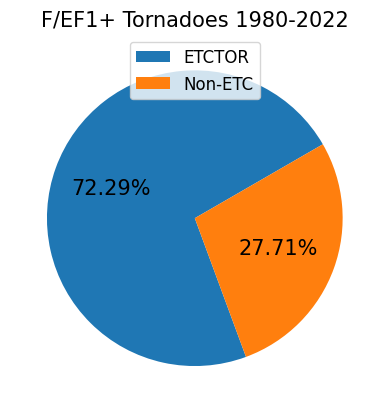

In [ ]:
# Pie chart of tornado types
tor_file = '%s/1980-2022_add_non_tc_tor_and_etcs.csv' % data_dir
if os.path.exists(tor_file):
    data = pd.read_csv(tor_file, header=[0])

    # Tornadoes without an ETC
    no_etc = data[data['closest_etclat'].isna()]
    # Tornadoes with an ETC
    w_etc = data.dropna(subset=['closest_etclat'])

    # Find ETCTOR (assoc) and non-ETC (nonassoc) tornadoes
    assoc = pd.DataFrame()
    nonassoc = pd.DataFrame()

    # Relative distances
    relative_lat = []
    relative_lon = []

    for index, row in w_etc.iterrows():
        tor_lat = w_etc['slat'][index] - w_etc['closest_etclat'][index]
        tor_lon = w_etc['slon'][index] - w_etc['closest_etclon'][index]
        relative_lat.append(tor_lat)
        relative_lon.append(tor_lon)

    w_etc['rlon'] = relative_lon
    w_etc['rlat'] = relative_lat

    for index, row in w_etc.iterrows():
        rx = w_etc['rlon'][index]
        ry = w_etc['rlat'][index]
        dist = w_etc['distance'][index]
        if dist > 2000:
            nonassoc = pd.concat([nonassoc, row.to_frame().T])
        elif rx < 0 and ry > 0 and dist > 500:
            nonassoc = pd.concat([nonassoc, row.to_frame().T])
        else:
            assoc = pd.concat([assoc, row.to_frame().T])

    # Calculate number of tornadoes
    total_tor = len(data)
    #num_no_etc = len(no_etc)
    num_assoc = len(assoc)
    print(num_assoc)
    num_non_assoc = len(nonassoc) + len(no_etc)

    print('Total Tornadoes: {} \nTornadoes associated with an ETC: {} \nTornadoes not associated with an ETC: {}'.format(total_tor, num_assoc, num_non_assoc))

    labels = ["ETCTOR", "Non-ETC"]
    y = np.array([num_assoc, num_non_assoc])
    # explode=[0, 0.1]
    plt.pie(y, labels=labels, autopct='%1.2f%%', labeldistance=None, textprops={"fontsize":15}, startangle=30)
    plt.title('F/EF1+ Tornadoes 1980-2022', fontsize=15)
    plt.legend(loc='upper center', fontsize=12)

    save_dir = '%s/1980-2022' % plots_dir
    if os.path.exists(save_dir):
        plt.savefig("%s/tor_pie.png" % (save_dir), bbox_inches='tight', dpi=300)
    else:
        os.mkdir(save_dir)
        plt.savefig("%s/tor_pie.png" % (save_dir), bbox_inches='tight', dpi=300)

    assoc.to_csv('%s/1980-2022_assoc_tor_and_etcs.csv' % data_dir, index=False)

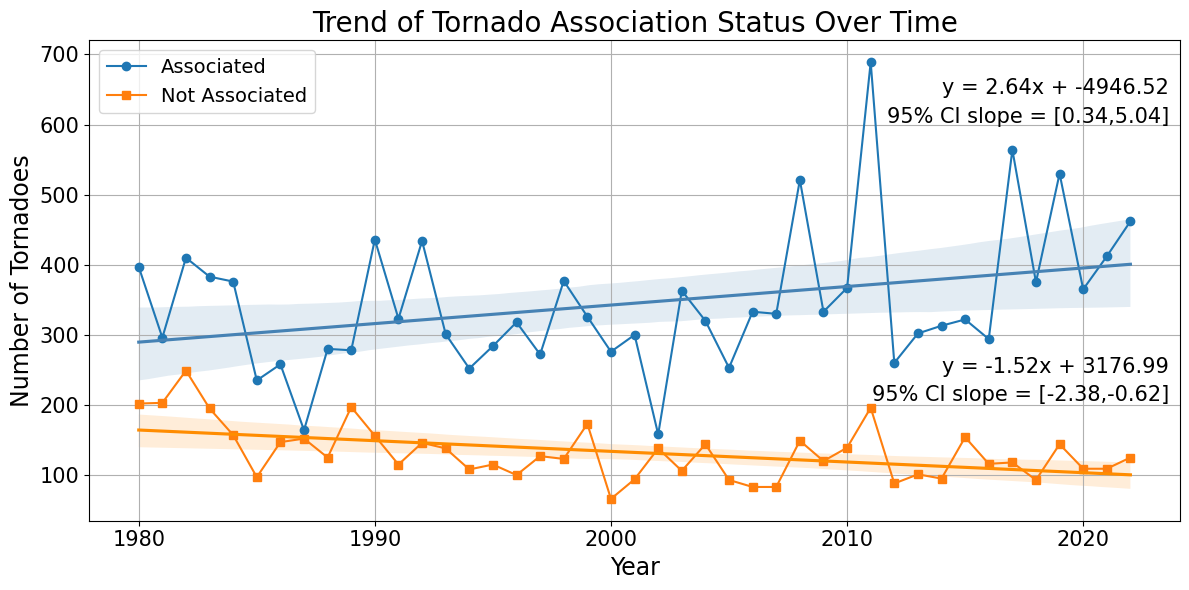

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

years = range(1980, 2023)
assoc_counts = []
non_assoc_counts = []

for year in years:
    data_year = data[data['utcyr'].isin([year])]
    if data_year.empty:
        assoc_counts.append(0)
        non_assoc_counts.append(0)
        continue

    # Repeat your existing association calculation pipeline here
    no_etc = data_year[data_year['closest_etclat'].isna()]
    w_etc = data_year.dropna(subset=['closest_etclat'])

    assoc = pd.DataFrame()
    nonassoc = pd.DataFrame()

    relative_lat = []
    relative_lon = []

    for index, row in w_etc.iterrows():
        tor_lat = row['slat'] - row['closest_etclat']
        tor_lon = row['slon'] - row['closest_etclon']
        relative_lat.append(tor_lat)
        relative_lon.append(tor_lon)

    w_etc['rlat'] = relative_lat
    w_etc['rlon'] = relative_lon

    for index, row in w_etc.iterrows():
        rx = row['rlon']
        ry = row['rlat']
        dist = row['distance']
        if dist > 2000:
            nonassoc = pd.concat([nonassoc, row.to_frame().T])
        elif rx < 0 and ry > 0 and dist > 500:
            nonassoc = pd.concat([nonassoc, row.to_frame().T])
        else:
            assoc = pd.concat([assoc, row.to_frame().T])

    # Store counts
    assoc_counts.append(len(assoc))
    non_assoc_counts.append(len(nonassoc) + len(no_etc))

# Convert to DataFrame for plotting
trend_df = pd.DataFrame({
    'Year': list(years),
    'Associated': assoc_counts,
    'Not Associated': non_assoc_counts
})

# Plotting the trend over time
fig, ax = plt.subplots(figsize=(12, 6))
plt.plot(trend_df['Year'], trend_df['Associated'], label='Associated', marker='o')
plt.plot(trend_df['Year'], trend_df['Not Associated'], label='Not Associated', marker='s')


# --- Associated ---
x = trend_df['Year']
y = trend_df['Associated']

X_lat = sm.add_constant(x)  # Add constant to predictor variable
model_lat = sm.OLS(y, X_lat).fit()
best_fit_values = model_lat.params
intercept = best_fit_values.const
slope = best_fit_values.Year

X = sm.add_constant(x)
model = sm.OLS(y, X).fit()
y_pred = model.predict(X)
best_fit_values = model.params
rmse = np.sqrt(skmet.mean_squared_error(y, y_pred))
rsquared = model_lat.rsquared

boot_ci_temp = []
R = 2000
for i in range(R):
    # Create a new dataset resampled with replacement directly from dataset
    idx = np.random.choice(np.arange(len(x)), size=len(x))
    Xboot = x[idx]-np.mean(x[idx])
    yboot = y[idx]-np.mean(y[idx])

    # Re-fit the linear regression model and map back to beta (dont care about intercept)
    boot_model = sm.OLS(yboot, Xboot).fit()
    boot_ci_temp.append(boot_model.params)

# extract CI on slopes no interecept
ci_slopelow, ci_slopehigh = np.percentile(boot_ci_temp, 2.5, axis=0), np.percentile(boot_ci_temp, 97.5, axis=0)

# Fit and plot the linear regression model with 95% confidence interval
model = sns.regplot(
  data=trend_df,
  x="Year",
  y="Associated",
  ci=95,
  ax=ax,
  scatter=False,
  line_kws={'label': "y={0:.1f}x+{1:.1f}".format(slope, intercept), 'color':'steelblue'}
)

# Set the plot title and labels
ax.text(0.99, 0.88, f'y = {slope:.2f}x + {intercept:.2f}', transform=ax.transAxes, fontsize=15, verticalalignment='bottom', horizontalalignment='right')
ax.text(0.99, 0.82, f'95% CI slope = [{ci_slopelow[0]:.2f},{ci_slopehigh[0]:.2f}]', transform=ax.transAxes, fontsize=15, verticalalignment='bottom', horizontalalignment='right')
# ax.text(0.1, 0.84, f'RMSE = {rmse:.2f}', transform=ax.transAxes, fontsize=14, verticalalignment='bottom', horizontalalignment='right')
# ax.text(0.1, 0.72, f'R2 = {rsquared:.3f}', transform=ax.transAxes, fontsize=14, verticalalignment='bottom', horizontalalignment='right')


# --- Non-Associated ---
x = trend_df['Year']
y = trend_df['Not Associated']

X_lat = sm.add_constant(x)  # Add constant to predictor variable
model_lat = sm.OLS(y, X_lat).fit()
best_fit_values = model_lat.params
intercept = best_fit_values.const
slope = best_fit_values.Year

X = sm.add_constant(x)
model = sm.OLS(y, X).fit()
y_pred = model.predict(X)
best_fit_values = model.params
rmse = np.sqrt(skmet.mean_squared_error(y, y_pred))
rsquared = model_lat.rsquared

boot_ci_temp = []
R = 2000
for i in range(R):
    # Create a new dataset resampled with replacement directly from dataset
    idx = np.random.choice(np.arange(len(x)), size=len(x))
    Xboot = x[idx]-np.mean(x[idx])
    yboot = y[idx]-np.mean(y[idx])

    # Re-fit the linear regression model and map back to beta (dont care about intercept)
    boot_model = sm.OLS(yboot, Xboot).fit()
    boot_ci_temp.append(boot_model.params)

# extract CI on slopes no interecept
ci_slopelow, ci_slopehigh = np.percentile(boot_ci_temp, 2.5, axis=0), np.percentile(boot_ci_temp, 97.5, axis=0)

# Fit and plot the linear regression model with 95% confidence interval
model = sns.regplot(
  data=trend_df,
  x="Year",
  y="Not Associated",
  ci=95,
  ax=ax,
  scatter=False,
  line_kws={'label': "y={0:.1f}x+{1:.1f}".format(slope, intercept), 'color':'darkorange'}
)

# Set the plot title and labels
ax.text(0.99, 0.30, f'y = {slope:.2f}x + {intercept:.2f}', transform=ax.transAxes, fontsize=15, verticalalignment='bottom', horizontalalignment='right')
ax.text(0.99, 0.24, f'95% CI slope = [{ci_slopelow[0]:.2f},{ci_slopehigh[0]:.2f}]', transform=ax.transAxes, fontsize=15, verticalalignment='bottom', horizontalalignment='right')
# ax.text(0.99, 0.08, f'RMSE = {rmse:.2f}', transform=ax.transAxes, fontsize=14, verticalalignment='bottom', horizontalalignment='right')
# ax.text(0.99, 0.04, f'R2 = {rsquared:.3f}', transform=ax.transAxes, fontsize=14, verticalalignment='bottom', horizontalalignment='right')


plt.title('Trend of Tornado Association Status Over Time', fontsize=20)
plt.xlabel('Year', fontsize=17)
plt.ylabel('Number of Tornadoes', fontsize=17)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.legend(fontsize=14)
plt.grid(True)
plt.tight_layout()

# Save or show the plot
save_dir = '%s/1980-2022' % plots_dir
os.makedirs(save_dir, exist_ok=True)
plt.savefig(f"{save_dir}/tor_association_trend.png", bbox_inches='tight', dpi=300)
plt.show()


In [ ]:
def plotGeo(df, title, save_file):
    # Initialize figure, set size and resolution
    fig = plt.figure(figsize=(10, 8), dpi=150)
    fig.set_facecolor('white')

    # create axis using cartopy projections, add in coastlines & grid
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, color='black', zorder=2)
    ax.add_feature(cfeature.STATES, edgecolor='black')
    ax.grid(visible=True)

    # create gridlines and format labels
    gl = ax.gridlines(draw_labels=True, zorder=3)
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabels_top = gl.ylabels_right = False
    gl.xlines = gl.ylines = True
    gl.xlabel_style = {'size': 14}
    gl.ylabel_style = {'size': 14}

    xlim = ([-135, -55])
    ylim = ([20, 70])
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    x_bin_edges = np.arange(-125, -65, 0.5)
    y_bin_edges = np.arange(25, 55, 0.5)
    counts, xedges, yedges, im = ax.hist2d(df['slon'], df['slat'], transform=ccrs.PlateCarree(),
                                           bins=(x_bin_edges, y_bin_edges), cmap=ListedColormap(plt.cm.Greys(np.linspace(0.1, 1, 256))), cmin=1)
    #plt.colorbar(im, ax=ax, fraction=0.023, label="%s tornadoes" % len(df))
    cbar = plt.colorbar(im, ax=ax, fraction=0.023, pad=0.1, label="Tornado Count")
    cbar.set_label("Tornado Count", fontsize=14)
    cbar.ax.tick_params(labelsize=12)
    plt.title(title, fontsize=15)

    # Median lat/lon
    median_lon = df['slon'].median()
    median_lat = df['slat'].median()

    # Percentiles
    perc_25_lon = df['slon'].quantile(0.25)
    perc_25_lat = df['slat'].quantile(0.25)
    perc_75_lon = df['slon'].quantile(0.75)
    perc_75_lat = df['slat'].quantile(0.75)

    ax.errorbar(median_lon, median_lat,
                xerr=[[median_lon - perc_25_lon], [perc_75_lon - median_lon]],
                yerr=[[median_lat - perc_25_lat], [perc_75_lat - median_lat]],
                fmt='x', ms='10', color='tomato', capsize=3)

    save_dir = '%s/1980-2022' % plots_dir
    if os.path.exists(save_dir):
        plt.savefig("%s/%s" % (save_dir, save_file), bbox_inches='tight', dpi=300)
    else:
        os.mkdir(save_dir)
        plt.savefig("%s/%s" % (save_dir, save_file), bbox_inches='tight', dpi=300)
    plt.show()

/content/drive/MyDrive/TOR_ETC_Analysis/data/1980-2022_add_non_tc_tor_and_etcs.csv


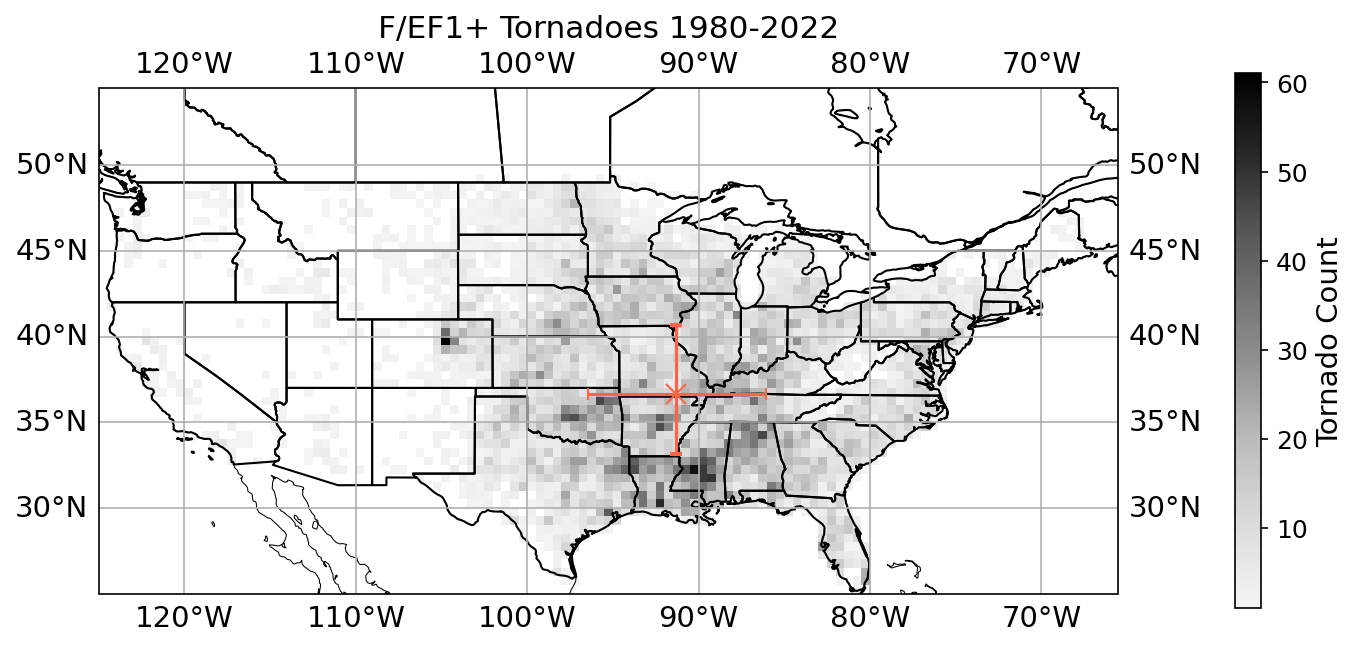

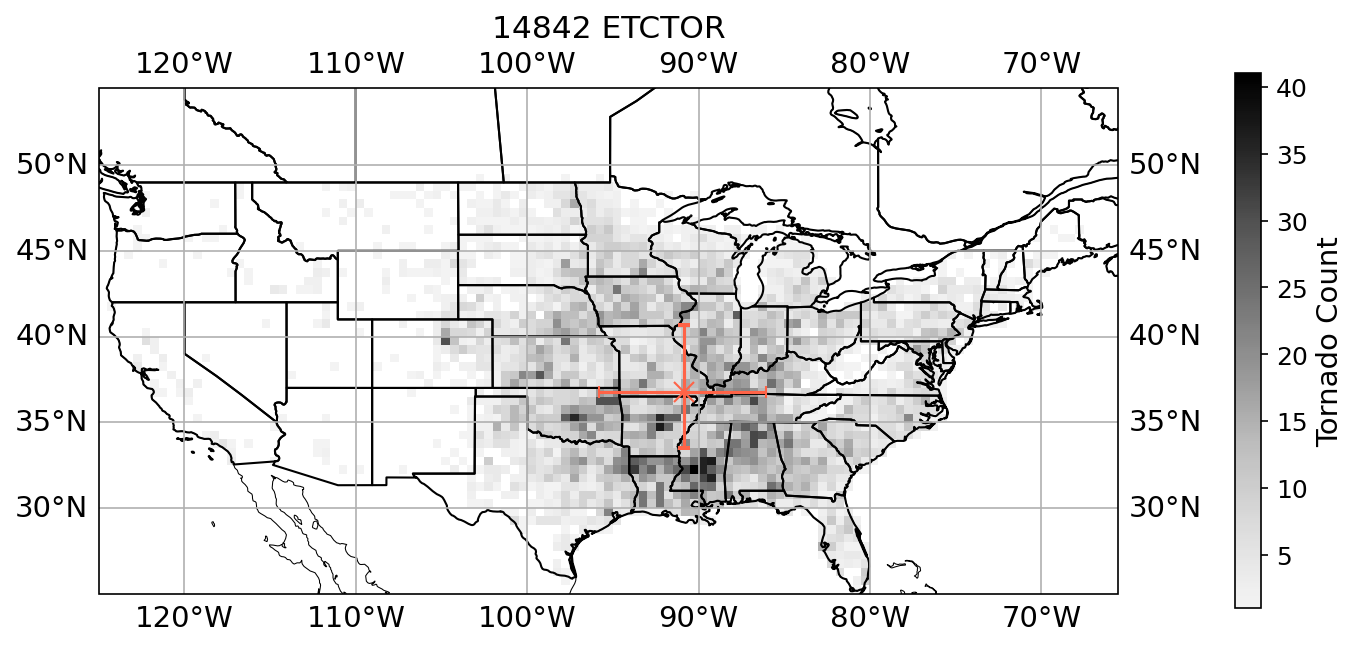

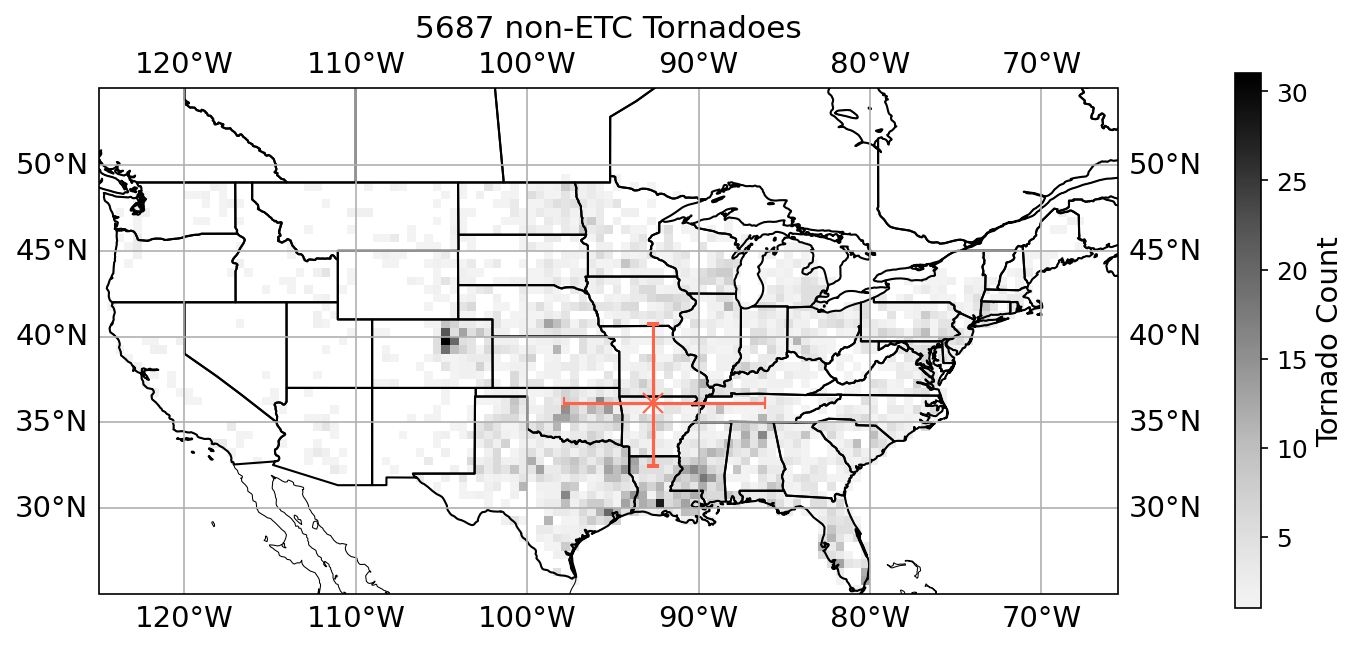

CPU times: user 1min 19s, sys: 317 ms, total: 1min 19s
Wall time: 1min 42s


In [ ]:
%%time

# Geographic distribution of tornadoes types
tor_file = '%s/1980-2022_add_non_tc_tor_and_etcs.csv' % data_dir
print(tor_file)
if os.path.exists(tor_file):
    df = pd.read_csv(tor_file, header=[0])
    df = df.drop_duplicates()
    title = "F/EF1+ Tornadoes 1980-2022"
    save_file = 'geo_dens_all_tor.png'
    plotGeo(df, title, save_file)

    # Find associated and non-associated tornadoes
    nonassoc = df[df['closest_etclat'].isna()]
    w_etc = df.dropna(subset=['closest_etclat'])
    assoc = pd.DataFrame()
    #nonassoc = pd.DataFrame()


    # Relative distances
    relative_lat = []
    relative_lon = []

    for index, row in w_etc.iterrows():
        tor_lat = w_etc['slat'][index] - w_etc['closest_etclat'][index]
        tor_lon = w_etc['slon'][index] - w_etc['closest_etclon'][index]
        relative_lat.append(tor_lat)
        relative_lon.append(tor_lon)

    w_etc['rlon'] = relative_lon
    w_etc['rlat'] = relative_lat

    for index, row in w_etc.iterrows():
        rx = w_etc['rlon'][index]
        ry = w_etc['rlat'][index]
        dist = w_etc['distance'][index]
        if dist > 2000:
            nonassoc = pd.concat([nonassoc, row.to_frame().T])
        elif rx < 0 and ry > 0 and dist > 500:
            nonassoc = pd.concat([nonassoc, row.to_frame().T])
        else:
            assoc = pd.concat([assoc, row.to_frame().T])

    numassoc = len(assoc)
    numnonassoc = len(nonassoc)

    title = f"{numassoc} ETCTOR"
    save_file = 'geo_dens_assoc_tor.png'
    plotGeo(assoc, title, save_file)

    title = f"{numnonassoc} non-ETC Tornadoes"
    save_file = 'geo_dens_non_assoc_tor.png'
    plotGeo(nonassoc, title, save_file)

    del df

In [ ]:
def haversine(lat1, lon1, lat2, lon2):
    # Convert degrees to radians
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    # Haversine formula
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

    # Earth's radius in kilometers (can also use miles: 3959)
    radius = 6371

    # Calculate the distance
    distance = radius * c
    return distance

def plotDistribution(req_df, title, save_file):
    # Create a figure with 6 plot areas
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.set_title(title, fontsize=20)

    # Axis labels
    ax.set_xlabel('Δ degrees longitude', fontsize=20)
    ax.set_ylabel('Δ degrees latitude', fontsize=20)
    ax.tick_params(labelsize=17)

    # (0,0) lines
    ax.axvline(0, ymin=-40, ymax=40, color='black', linewidth=.5)
    ax.axhline(0, xmin=0, xmax=1, color='black', linewidth=.5)

    # Centralized ETC marker
    ax.plot(0, 0, marker="o", markersize=8, c="cyan", mec='teal', label='ETC Center')

    # Set coordinates relative to centralized ETC
    new_coord = pd.DataFrame(columns=["slat", "slon", "distance"])

    # Define new lat and lon relative to ETC
    filtered_data = req_df.dropna(subset=['closest_etclon', 'closest_etclat'])
    if not filtered_data.empty:
        for index, row in filtered_data.iterrows():
          tor_lat = filtered_data['slat'][index] - filtered_data['closest_etclat'][index]
          tor_lon = filtered_data['slon'][index] - filtered_data['closest_etclon'][index]
          df = pd.DataFrame({"slat": [tor_lat], "slon": [tor_lon], "distance": [filtered_data['distance'][index]]})
          new_coord = pd.concat([new_coord, df], ignore_index=True)

        # 2d histogram
        # Uncomment for non-ETC (comment out ETCTOR)
        # x_bin_edges = np.arange(-100, 70, 1)
        # y_bin_edges = np.arange(-45, 30, 1)
        # Uncomment for ETCTOR (comment out non-ETC)
        x_bin_edges = np.arange(-40, 42, 1)
        y_bin_edges = np.arange(-20, 22, 1)

        counts, xedges, yedges, im = ax.hist2d(new_coord['slon'], new_coord['slat'],
                                               bins=(x_bin_edges, y_bin_edges), cmin=1,
                                               cmap=ListedColormap(plt.cm.Greys(np.linspace(0.1, 1, 256))))
        cbar = plt.colorbar(im, ax=ax, fraction=0.05)#, pad=0.05)
        cbar.set_label("Tornado Count", fontsize=20)
        cbar.ax.tick_params(labelsize=17)

        # Median lat/lon
        median_lon = new_coord['slon'].median()
        median_lat = new_coord['slat'].median()
        median_lon_etc = filtered_data['closest_etclon'].median()
        median_lat_etc = filtered_data['closest_etclat'].median()

        # Percentiles
        perc_25_lon = new_coord['slon'].quantile(0.25)
        perc_25_lat = new_coord['slat'].quantile(0.25)
        perc_75_lon = new_coord['slon'].quantile(0.75)
        perc_75_lat = new_coord['slat'].quantile(0.75)

        #dista = math.sqrt((111.325 * (median_lat))**2 + (111.325 * math.cos(35*math.pi/180) * median_lon)**2)
        dista = haversine(median_lat_etc, median_lon_etc, median_lat_etc + median_lat, median_lon_etc + median_lon)


        ax.errorbar(median_lon, median_lat,
                    xerr=[[median_lon - perc_25_lon], [perc_75_lon - median_lon]],
                    yerr=[[median_lat - perc_25_lat], [perc_75_lat - median_lat]],
                    fmt='x', ms='10', color='tomato', capsize=3)

        ax.text(0.02, 0.98, f'Median: ({median_lon:.2f}, {median_lat:.2f})',
                transform=ax.transAxes, fontsize=15, verticalalignment='top', horizontalalignment='left')
        ax.text(0.02, 0.94, f'Median distance from origin: {format(dista,".2f")}',
                transform=ax.transAxes, fontsize=15, verticalalignment='top', horizontalalignment='left')
        ax.text(0.02, 0.90, f'25th Percentile: ({perc_25_lon:.2f}, {perc_25_lat:.2f})',
                transform=ax.transAxes, fontsize=15, verticalalignment='top', horizontalalignment='left')
        ax.text(0.02, 0.86, f'75th Percentile: ({perc_75_lon:.2f}, {perc_75_lat:.2f})',
                transform=ax.transAxes, fontsize=15, verticalalignment='top', horizontalalignment='left')

    save_dir = '%s/1980-2022' % plots_dir
    if os.path.exists(save_dir):
        plt.savefig("%s/%s" % (save_dir, save_file), bbox_inches='tight', dpi=300)
    else:
        os.mkdir(save_dir)
        plt.savefig("%s/%s" % (save_dir, save_file), bbox_inches='tight', dpi=300)

CPU times: user 1min 23s, sys: 270 ms, total: 1min 23s
Wall time: 1min 40s


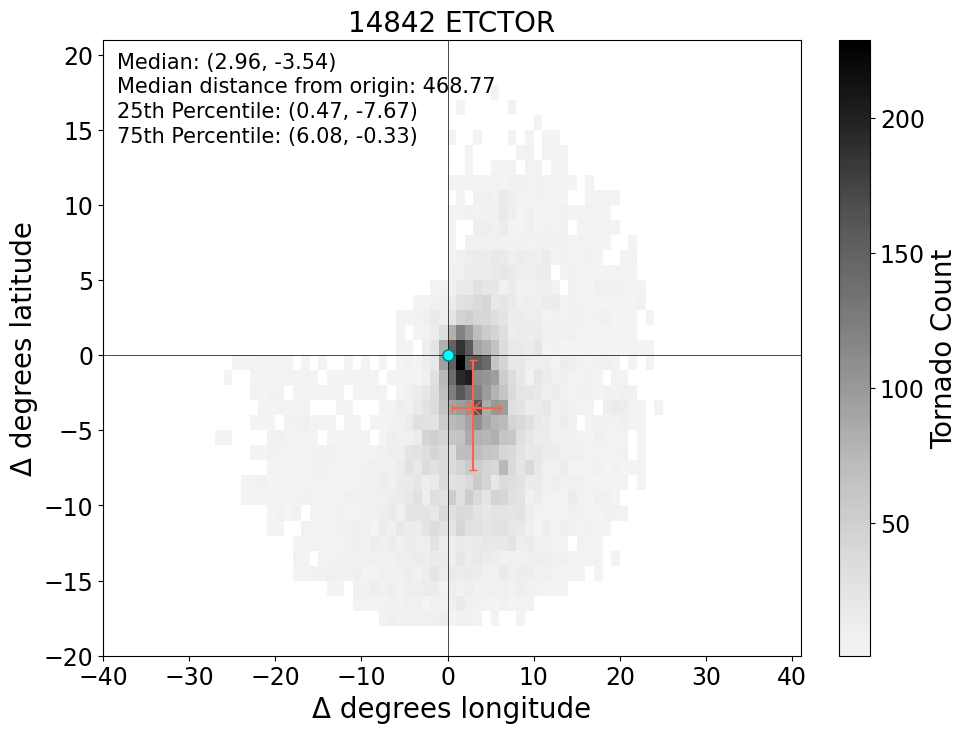

In [ ]:
%%time

# Geographic distribution of associated vs non-associated tornadoes
tor_file = '%s/1980-2022_add_non_tc_tor_and_etcs.csv' % data_dir
if os.path.exists(tor_file):
    df = pd.read_csv(tor_file, header=[0])
    df = df.drop_duplicates()
    title = "F/EF1+ Tornadoes 1980-2022"
    save_file = 'distr_dens_all_tor.png'
    #plotDistribution(df, title, save_file)

    # Find associated and non-associated tornadoes
    w_etc = df.dropna(subset=['closest_etclat'])
    assoc = pd.DataFrame()
    nonassoc = pd.DataFrame()

    # Relative distances
    relative_lat = []
    relative_lon = []

    for index, row in w_etc.iterrows():
        tor_lat = w_etc['slat'][index] - w_etc['closest_etclat'][index]
        tor_lon = w_etc['slon'][index] - w_etc['closest_etclon'][index]
        relative_lat.append(tor_lat)
        relative_lon.append(tor_lon)

    w_etc['rlon'] = relative_lon
    w_etc['rlat'] = relative_lat

    for index, row in w_etc.iterrows():
        rx = w_etc['rlon'][index]
        ry = w_etc['rlat'][index]
        dist = w_etc['distance'][index]
        if dist > 2000:
            nonassoc = pd.concat([nonassoc, row.to_frame().T])
        elif rx < 0 and ry > 0 and dist > 500:
            nonassoc = pd.concat([nonassoc, row.to_frame().T])
        else:
            assoc = pd.concat([assoc, row.to_frame().T])

    numassoc = len(assoc)
    numnonassoc = len(nonassoc)
    title = f"{numassoc} ETCTOR"
    save_file = 'distr_dens_assoc_tor.png'
    plotDistribution(assoc, title, save_file)

    title = f"{numnonassoc} Non-ETC Tornadoes (with ETC in domain)"
    save_file = 'distr_dens_non_assoc_tor.png'
    #plotDistribution(nonassoc, title, save_file)

    del df

In [ ]:
def plotWindrose(req_df, title, save_file):
    df = pd.DataFrame()

    # Center etc tracks
    for index, row in req_df.iterrows():
        dx = req_df['slon'][index] - req_df['closest_etclon'][index]
        dy = req_df['slat'][index] - req_df['closest_etclat'][index]
        degrees_temp = math.atan2(dx, dy)/math.pi*180
        if degrees_temp < 0:
            degrees_final = 360 + degrees_temp
        else:
            degrees_final = degrees_temp
        dg_df = pd.DataFrame({"dx": [dx], "dy": [dy], "dist": [req_df["distance"][index]], "degrees": [degrees_final]})
        df = pd.concat([df, dg_df], ignore_index=True)
        del dg_df

    if not df.empty:
        ax = WindroseAxes.from_ax()
        #ax.bar(df["degrees"], df["dist"], normed=True, opening=0.8, edgecolor='white', bins=np.arange(0, 4000, 500)) # non assoc
        ax.bar(df["degrees"], df["dist"], normed=True, opening=0.8, edgecolor='white', bins=np.arange(0, 2000, 300)) # assoc
        ax.set_yticks(np.arange(3, 24, step=3))
        ax.set_yticklabels(np.arange(3, 24, step=3))
        ax.tick_params(labelsize=17)
        ax.legend(fontsize=17, loc='upper left')
        plt.title(title, fontsize=22, y=1.10, pad=-14)

        save_dir = '%s/1980-2022' % plots_dir
        if os.path.exists(save_dir):
            plt.savefig("%s/%s" % (save_dir, save_file), bbox_inches='tight', dpi=300)
        else:
            os.mkdir(save_dir)
            plt.savefig("%s/%s" % (save_dir, save_file), bbox_inches='tight', dpi=300)
        plt.show()
        del ax
    del df

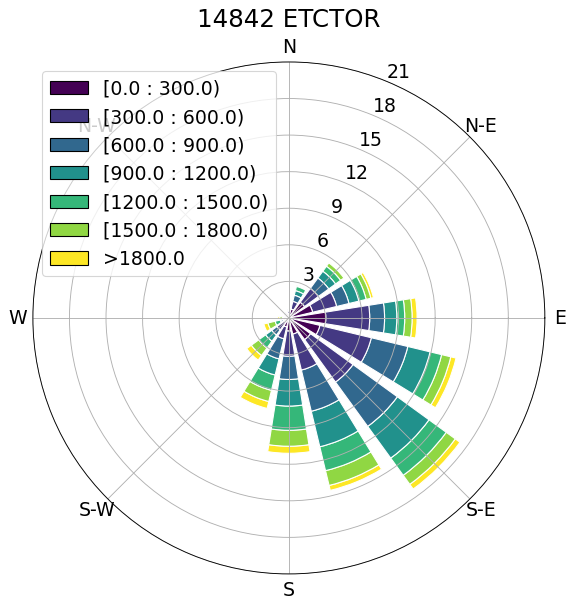

CPU times: user 1min 16s, sys: 275 ms, total: 1min 16s
Wall time: 1min 26s


In [ ]:
%%time

# Geographic distribution of associated vs non-associated tornadoes
tor_file = '%s/1980-2022_add_non_tc_tor_and_etcs.csv' % data_dir
if os.path.exists(tor_file):
    df = pd.read_csv(tor_file, header=[0])
    df = df.drop_duplicates()
    w_etc = df.dropna(subset=['closest_etclat'])
    title = "F/EF1+ Tornadoes 1980-2022"
    save_file = 'windrose_all_tor.png'
    #plotWindrose(w_etc, title, save_file)

    # Find ETCTOR (assoc) and non-ETC (nonassoc) tornadoes
    assoc = pd.DataFrame()
    nonassoc = pd.DataFrame()

    # Relative distances
    relative_lat = []
    relative_lon = []

    for index, row in w_etc.iterrows():
        tor_lat = w_etc['slat'][index] - w_etc['closest_etclat'][index]
        tor_lon = w_etc['slon'][index] - w_etc['closest_etclon'][index]
        relative_lat.append(tor_lat)
        relative_lon.append(tor_lon)

    w_etc['rlon'] = relative_lon
    w_etc['rlat'] = relative_lat

    for index, row in w_etc.iterrows():
        rx = w_etc['rlon'][index]
        ry = w_etc['rlat'][index]
        dist = w_etc['distance'][index]
        if dist > 2000:
            nonassoc = pd.concat([nonassoc, row.to_frame().T])
        elif rx < 0 and ry > 0 and dist > 500:
            nonassoc = pd.concat([nonassoc, row.to_frame().T])
        else:
            assoc = pd.concat([assoc, row.to_frame().T])

    numassoc = len(assoc)
    numnonassoc = len(nonassoc)
    title = f"{numassoc} ETCTOR"
    save_file = 'windrose_assoc_tor.png'
    plotWindrose(assoc, title, save_file)

    title = f"{numnonassoc} Non-ETC Tornadoes"
    save_file = 'windrose_non_assoc_tor.png'
    #plotWindrose(nonassoc, title, save_file)

    del df

# Outbreak Sizes

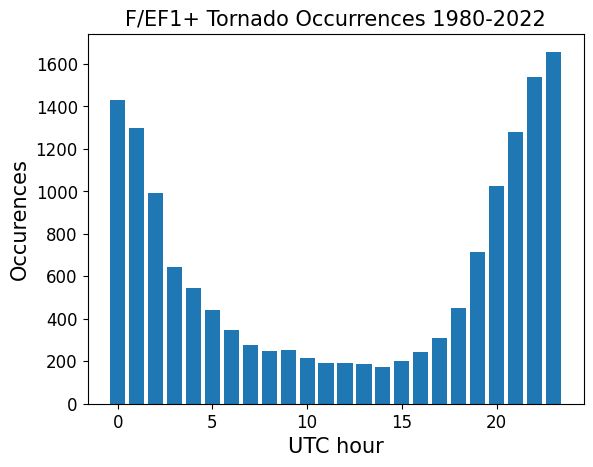

In [ ]:
# Plot the UTC times to find a lull in activity
f = '%s/1980-2022_assoc_tor_and_etcs.csv' % data_dir
if os.path.exists(f):
    hrs = []
    climo_data = pd.read_csv(f, header=[0])
    for hour in climo_data['utctime']:
        hour = hour[:2]
        hrs.append(hour)

    hrs.sort()

    # Histogram of tornado occurence hours
    plt.bar(np.arange(00, 24), np.bincount(hrs, minlength=24))
    plt.title('F/EF1+ Tornado Occurrences 1980-2022', fontsize=15)
    plt.xlabel('UTC hour', fontsize=15)
    plt.ylabel('Occurences', fontsize=15)

    # Adjust tick label sizes
    plt.tick_params(axis='x', labelsize=12)  # Increase x-tick label size
    plt.tick_params(axis='y', labelsize=12)  # Increase y-tick label size

    save_dir = '%s/1980-2022' % plots_dir
    if os.path.exists(save_dir):
        plt.savefig("%s/utc_hour_hist.png" % (save_dir), bbox_inches='tight', dpi=300)
    else:
        os.mkdir(save_dir)
        plt.savefig("%s/utc_hour_hist.png" % (save_dir), bbox_inches='tight', dpi=300)

In [ ]:
%%time
# Defining tornado day
# Lull in activity around 2pm UTC time: tornado day = 2pm-1pm UTC
new_col = []
f = '%s/1980-2022_assoc_tor_and_etcs.csv' % data_dir
if os.path.exists(f):
    data = pd.read_csv(f, header=[0])
    for index, row in data.iterrows():
        year = data['utcyr'][index]
        month = data['utcmo'][index]
        day = data['utcdy'][index]
        hour = data['utctime'][index][:2]

        # if tornado occurred after 2pm, tornado day is current day
        if int(hour) >= 14:
            local_date = datetime(int(year), int(month), int(day))
            new_col.append(local_date)
        # if tornado occurred before 2pm, tornado day is previous day
        else:
            local_date = datetime(int(year), int(month), int(day))
            local_date = local_date - timedelta(days=1)
            new_col.append(local_date)

    data.insert(1, "tornado_day", new_col)

# Creating outbreak size files
# isolated: 1, 1
# small: 2, 5
# large: 6+
sizes = [[1, 1], [2, 5], [6, 100000]]
for size in sizes:
    min_tor = size[0]
    max_tor = size[1]

    outbreaks = pd.DataFrame()

    for tor_day in data['tornado_day'].unique():
        num_in_day = len(data[data['tornado_day'].isin([tor_day])])
        if num_in_day >= min_tor and num_in_day <= max_tor:
            outbreaks = pd.concat([outbreaks, data[data['tornado_day'].isin([tor_day])]], ignore_index=True)

    if not outbreaks.empty:
        outbreaks.to_csv("%s/1980-2022_outbreak_%s_%s.csv" % (data_dir, str(min_tor), str(max_tor)), index=False)
        print("%s-%s outbreaks: %s" % (str(min_tor), str(max_tor), len(outbreaks)))

1-1 outbreaks: 1178
2-5 outbreaks: 3478
6-100000 outbreaks: 10186
CPU times: user 19.4 s, sys: 74.9 ms, total: 19.4 s
Wall time: 24.2 s


In [ ]:
# Methods needed for outbreak plots
def haversine(lat1, lon1, lat2, lon2):
    # Convert degrees to radians
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    # Haversine formula
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

    # Earth's radius in kilometers (can also use miles: 3959)
    radius = 6371

    # Calculate the distance
    distance = radius * c
    return distance

def torOutDistr(req_df, title, outbreak):
    # Create a figure with 6 plot areas
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.set_title(title, fontsize=20)

    # Axis labels
    ax.set_xlabel('Δ degrees longitude', fontsize=20)
    ax.set_ylabel('Δ degrees latitude', fontsize=20)
    ax.tick_params(labelsize=17)

    # (0,0) lines
    ax.axvline(0, ymin=-40, ymax=40, color='black', linewidth=.5)
    ax.axhline(0, xmin=0, xmax=1, color='black', linewidth=.5)

    # Centralized ETC marker
    ax.plot(0, 0, marker="o", markersize=8, c="cyan", mec='teal', label='Centralized ETC')

    # Set coordinates relative to centralized ETC
    new_coord = pd.DataFrame()

    # Define new lat and lon relative to ETC
    filtered_data = req_df.dropna(subset=['closest_etclon', 'closest_etclat'])
    # print(len(req_df))
    # print(len(filtered_data))
    if not filtered_data.empty:
        for index, row in filtered_data.iterrows():
            tor_lat = filtered_data['slat'][index] - filtered_data['closest_etclat'][index]
            tor_lon = filtered_data['slon'][index] - filtered_data['closest_etclon'][index]
            df = pd.DataFrame({"slat": [tor_lat], "slon": [tor_lon], "distance": [filtered_data['distance'][index]]})
            new_coord = pd.concat([new_coord, df], ignore_index=True)

        # 2d histogram
        x_bin_edges = np.arange(-40, 42, 1)
        y_bin_edges = np.arange(-20, 22, 1)
        counts, xedges, yedges, im = ax.hist2d(new_coord['slon'], new_coord['slat'],
                                               bins=(x_bin_edges, y_bin_edges), cmin=1,
                                               cmap=ListedColormap(plt.cm.Greys(np.linspace(0.1, 1, 256))))
        cbar = plt.colorbar(im, ax=ax, fraction=0.1, pad=0.05)
        cbar.set_label("Tornado Count", fontsize=20)
        cbar.ax.tick_params(labelsize=17)

        # Median lat/lon
        median_lon = new_coord['slon'].median()
        median_lat = new_coord['slat'].median()
        median_lon_etc = filtered_data['closest_etclon'].median()
        median_lat_etc = filtered_data['closest_etclat'].median()
        median_lon_tor = filtered_data['slon'].median()
        median_lat_tor = filtered_data['slat'].median()

        print('ETC-centered',filtered_data['slat'].median(),filtered_data['slon'].median())
        print('ETC-centered',filtered_data['closest_etclat'].median(),filtered_data['closest_etclon'].median())
        print('ETC-centered',len(new_coord),len(filtered_data))
        print('ETC-centered',median_lon_tor,median_lat_tor,median_lon_etc,median_lat_etc,median_lon,median_lat)


        # Percentiles
        perc_25_lon = new_coord['slon'].quantile(0.25)
        perc_25_lat = new_coord['slat'].quantile(0.25)
        perc_75_lon = new_coord['slon'].quantile(0.75)
        perc_75_lat = new_coord['slat'].quantile(0.75)

        # Rough distance between median lat/lon and origin
        # dista = math.sqrt((111.325 * (median_lat))**2 + (111.325 * math.cos(35*math.pi/180) * median_lon)**2)
        # Calculate the distance between the tornado and ETC median points
        distance_km = haversine(median_lat_etc, median_lon_etc, median_lat_etc + median_lat, median_lon_etc + median_lon)

        # Testing the result of median distance
        print(f"Distance between tornado and ETC median points: {distance_km:.2f} km")

        # Plot median and percentiles
        ax.errorbar(median_lon, median_lat,
                    xerr=[[median_lon - perc_25_lon], [perc_75_lon - median_lon]],
                    yerr=[[median_lat - perc_25_lat], [perc_75_lat - median_lat]],
                    fmt='x', ms='10', color='tomato', capsize=3)

        ax.text(0.02, 0.98, f'Median: ({median_lon:.2f}, {median_lat:.2f})',
                transform=ax.transAxes, fontsize=15, verticalalignment='top', horizontalalignment='left')
        ax.text(0.02, 0.94, f'Median distance from median ETC: {format(distance_km,".2f")}',
                transform=ax.transAxes, fontsize=15, verticalalignment='top', horizontalalignment='left')
        ax.text(0.02, 0.90, f'25th Percentile: ({perc_25_lon:.2f}, {perc_25_lat:.2f})',
                transform=ax.transAxes, fontsize=15, verticalalignment='top', horizontalalignment='left')
        ax.text(0.02, 0.86, f'75th Percentile: ({perc_75_lon:.2f}, {perc_75_lat:.2f})',
                transform=ax.transAxes, fontsize=15, verticalalignment='top', horizontalalignment='left')

    save_dir = '%s/1980-2022' % plots_dir
    if os.path.exists(save_dir):
        plt.savefig("%s/distr_dens_%s.png" % (save_dir, outbreak), bbox_inches='tight', dpi=300)
    else:
        os.mkdir(save_dir)
        plt.savefig("%s/distr_dens_%s.png" % (save_dir, outbreak), bbox_inches='tight', dpi=300)

def torOutWindrose(req_df, title, outbreak):
    df = pd.DataFrame()

    # Center etc tracks
    for index, row in req_df.iterrows():
        dx = req_df['slon'][index] - req_df['closest_etclon'][index]
        dy = req_df['slat'][index] - req_df['closest_etclat'][index]
        degrees_temp = math.atan2(dx, dy)/math.pi*180
        if degrees_temp < 0:
            degrees_final = 360 + degrees_temp
        else:
            degrees_final = degrees_temp
        dg_df = pd.DataFrame({"dx": [dx], "dy": [dy], "dist": [req_df["distance"][index]], "degrees": [degrees_final]})
        #df = df.append(dg_df, ignore_index=True)
        df = pd.concat([df, dg_df], ignore_index=True)
        del dg_df
    # Plot windrose
    if not df.empty:
        ax = WindroseAxes.from_ax()
        ax.bar(df["degrees"], df["dist"], normed=True, opening=0.8, edgecolor='white', bins=np.arange(0, 2000, 300))
        ax.set_yticks(np.arange(3, 24, step=3))
        ax.set_yticklabels(np.arange(3, 24, step=3))
        ax.tick_params(labelsize=17)
        ax.legend(fontsize=17, loc='upper left')
        plt.title(title, fontsize=22, y=1.10, pad=-14)

        save_dir = '%s/1980-2022' % plots_dir
        if os.path.exists(save_dir):
            plt.savefig("%s/windrose_%s.png" % (save_dir, outbreak), bbox_inches='tight', dpi=300)
        else:
            os.mkdir(save_dir)
            plt.savefig("%s/windrose_%s.png" % (save_dir, outbreak), bbox_inches='tight', dpi=300)
        plt.show()
        del ax
    del df

def torOutGeo(req_data, title, outbreak):
    if not req_data.empty:
        # Initialize figure, set size and resolution
        fig = plt.figure(figsize=(10, 8), dpi=150)
        fig.set_facecolor('white')

        # create axis using cartopy projections, add in coastlines & grid
        ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
        ax.add_feature(cfeature.COASTLINE, linewidth=0.5, color='black', zorder=2)
        ax.add_feature(cfeature.STATES, edgecolor='black')
        ax.grid(visible=True)

        # create gridlines and format labels
        gl = ax.gridlines(draw_labels=True, zorder=3)
        gl.xformatter = LONGITUDE_FORMATTER
        gl.yformatter = LATITUDE_FORMATTER
        gl.xlabels_top = gl.ylabels_right = False
        gl.xlines = gl.ylines = True
        gl.xlabel_style = {'size': 14}
        gl.ylabel_style = {'size': 14}

        # Density distribution of tornadoes (grey shading)
        x_bin_edges = np.arange(-125, -65, 0.5)
        y_bin_edges = np.arange(25, 55, 0.5)
        counts, xedges, yedges, im = ax.hist2d(req_data['slon'], req_data['slat'],
                                               transform=ccrs.PlateCarree(), bins=(x_bin_edges, y_bin_edges),
                                               cmap=ListedColormap(plt.cm.Greys(np.linspace(0.15, 1, 256))), cmin=1)
        cbar = plt.colorbar(im, ax=ax, fraction=0.023, pad=0.08)
        cbar.set_label("Tornado Count", fontsize=16)
        cbar.ax.tick_params(labelsize=15)

        # # Density distribution of ETCs (grey contours)
        # x = np.linspace(req_data['closest_etclon'].min(), req_data['closest_etclon'].max(), 100)
        # y = np.linspace(req_data['closest_etclat'].min(), req_data['closest_etclat'].max(), 100)
        # X, Y = np.meshgrid(x, y)
        # Z = scipy.stats.gaussian_kde([req_data['closest_etclon'], req_data['closest_etclat']])(np.vstack([X.flatten(), Y.flatten()]))

        # contour = plt.contour(X, Y, Z.reshape(X.shape), levels=10)
        # levels = contour.levels
        # levels_to_label = levels[::2]
        # plt.clabel(contour, inline=True)

        # Or, if you want to stick with seaborn, after plotting:
        ax = sns.kdeplot(data=req_data, x="closest_etclon", y="closest_etclat",cmap=plt.cm.Blues)#, cbar=False, cbar_kws={'shrink': .5})
        contour_set = ax.get_children()[-1]  # Could be contour set
        # Then loop through contour levels and add labels as:
        for collection in ax.collections:
            if isinstance(collection, mcontour.QuadContourSet):
                levels = collection.levels
                levels_to_label = levels[::1] # every level
                plt.clabel(collection, inline=1, fontsize=10, colors="blue", fmt='%1.4f', levels=levels_to_label)

        # if contour_set:
        #     plt.clabel(contour_set, inline=1, fontsize=8)
        #cbar = ax.figure.colorbar(ax.collections[-1], ax=ax, orientation='horizontal', pad=0.05)
        #cbar.set_label('ETC Density')
        #cbar.ax.xaxis.label.set_size(16)
        #cbar.ax.tick_params(labelsize=13, rotation=45)

        # Median lat/lon of tornado and ETC
        median_lon_tor = req_data['slon'].median()
        median_lat_tor = req_data['slat'].median()
        median_lon_etc = req_data['closest_etclon'].median()
        median_lat_etc = req_data['closest_etclat'].median()

        print('geo',len(req_data))
        print('geo',median_lon_tor,median_lat_tor,median_lon_etc,median_lat_etc)

        # Percentiles
        perc_25_lon = req_data['slon'].quantile(0.25)
        perc_25_lat = req_data['slat'].quantile(0.25)
        perc_75_lon = req_data['slon'].quantile(0.75)
        perc_75_lat = req_data['slat'].quantile(0.75)

        ax.errorbar(median_lon_tor, median_lat_tor,
                    xerr=[[median_lon_tor - perc_25_lon], [perc_75_lon - median_lon_tor]],
                    yerr=[[median_lat_tor - perc_25_lat], [perc_75_lat - median_lat_tor]],
                    fmt='x', ms='10', color='firebrick', capsize=3)

        # Calculate the distance between the tornado and ETC median points
        distance_km = haversine(median_lat_etc, median_lon_etc, median_lat_tor, median_lon_tor)

        # Testing the result of median distance
        print(f"Distance between median tornado and median ETC points: {distance_km:.2f} km")

        # Plot median points
        ax.scatter(median_lon_tor, median_lat_tor, transform=ccrs.PlateCarree(),
                   marker='v', s=75, c='tomato', edgecolors='firebrick', zorder=2)
        ax.scatter(median_lon_etc, median_lat_etc, transform=ccrs.PlateCarree(),
                   marker='o', s=75, c='cyan', edgecolors='teal', zorder=2)

        plt.title(title, fontsize=15)
        save_dir = '%s/1980-2022' % plots_dir
        if os.path.exists(save_dir):
            plt.savefig("%s/geo_dens_%s.png" % (save_dir, outbreak), bbox_inches='tight', dpi=300)
        else:
            os.mkdir(save_dir)
            plt.savefig("%s/geo_dens_%s.png" % (save_dir, outbreak), bbox_inches='tight', dpi=300)

In [ ]:
# ETC-centered -90.78 36.69355 -94.75 41.0 2.974350000000001 -3.530000000000001
# Distance between tornado and ETC median points: 468.64 km
# print('ETC-centered',median_lon_tor,median_lat_tor,median_lon_etc,median_lat_etc,median_lon,median_lat)
# geo 14918
# geo -90.78 36.69355 -94.75 41.0
# Distance between tornado and ETC median points: 589.34 km
median_lat_etc = 41.0
median_lon_etc = -94.75
median_lat_tor = 36.69355
median_lon_tor = -90.78
median_lat = -3.530000000000001  #this is (part of the problem) -- too small
median_lon = 2.974350000000001
median_lat_check = median_lat_tor - median_lat_etc
median_lon_check = median_lon_tor - median_lon_etc
print(median_lat_check,median_lon_check)
distance_geo = haversine(median_lat_etc, median_lon_etc, median_lat_tor, median_lon_tor)
print(geopy.distance.geodesic([median_lat_tor,median_lon_tor], [median_lat_etc,median_lon_etc]).km)
print(distance_geo)
distance_etccent = haversine(median_lat_etc, median_lon_etc, median_lat_etc + median_lat, median_lon_etc + median_lon)
print(geopy.distance.geodesic([median_lat_etc,median_lon_etc], [median_lat_etc + median_lat,median_lon_etc + median_lon]).km)
print(distance_etccent)

-4.306449999999998 3.969999999999999
589.1939554155812
589.3418759133343
468.471180548573
468.6429247149631


geo 14842
geo -90.8505 36.7624 -94.75 41.0
Distance between median tornado and median ETC points: 579.47 km
geo 1178
geo -90.815 38.7125 -93.0 43.0
Distance between median tornado and median ETC points: 510.89 km
geo 3478
geo -92.05 37.984399999999994 -95.5 41.5
Distance between median tornado and median ETC points: 489.63 km
geo 10186
geo -90.6472 36.37435 -94.75 40.75
Distance between median tornado and median ETC points: 603.14 km


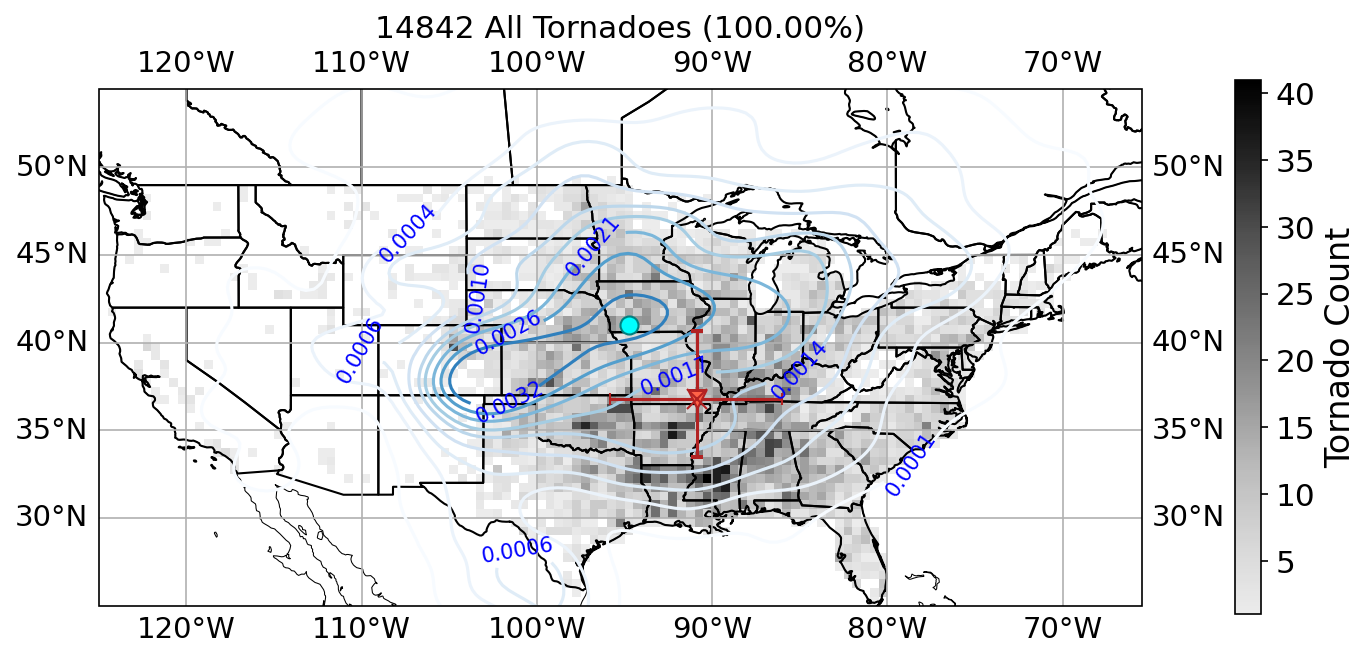

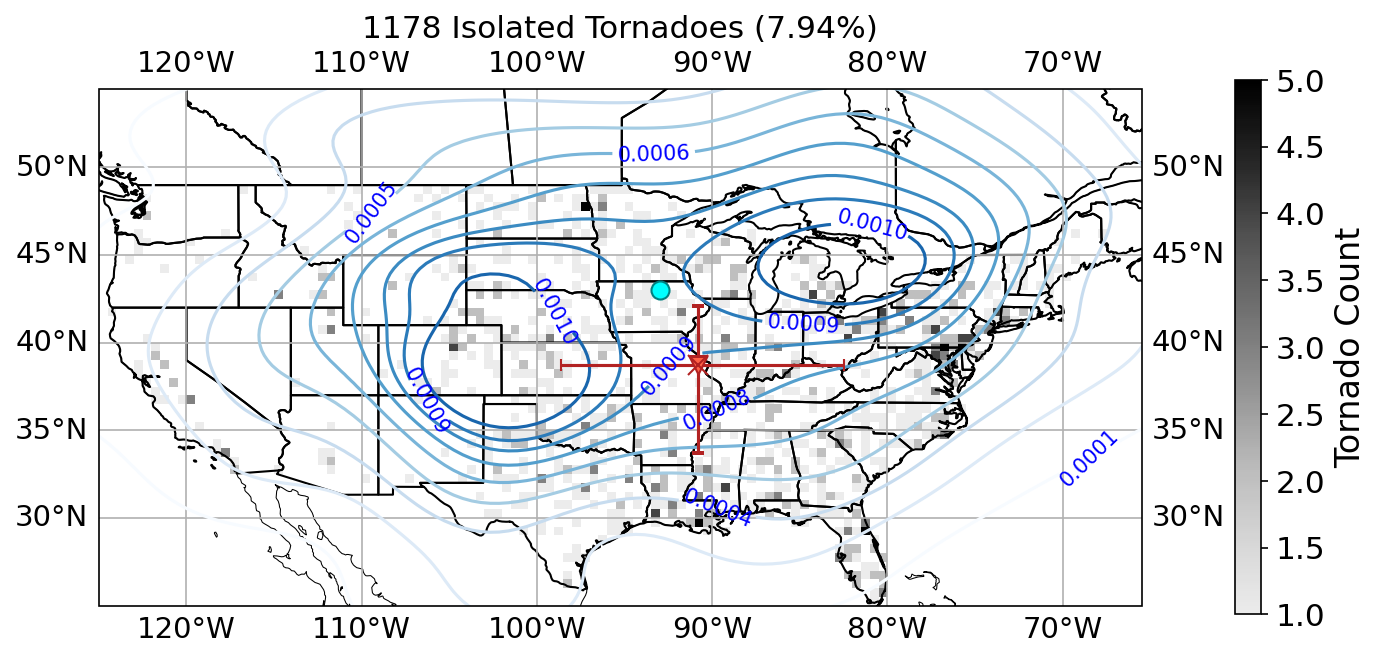

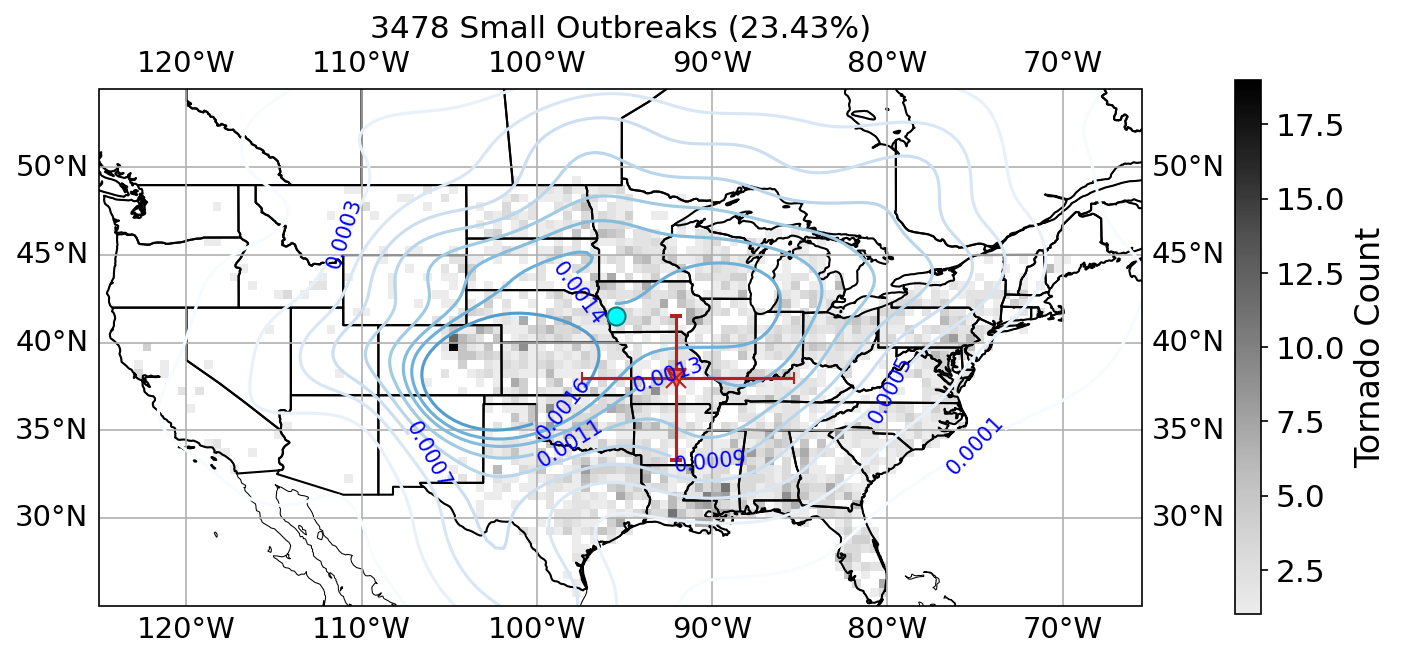

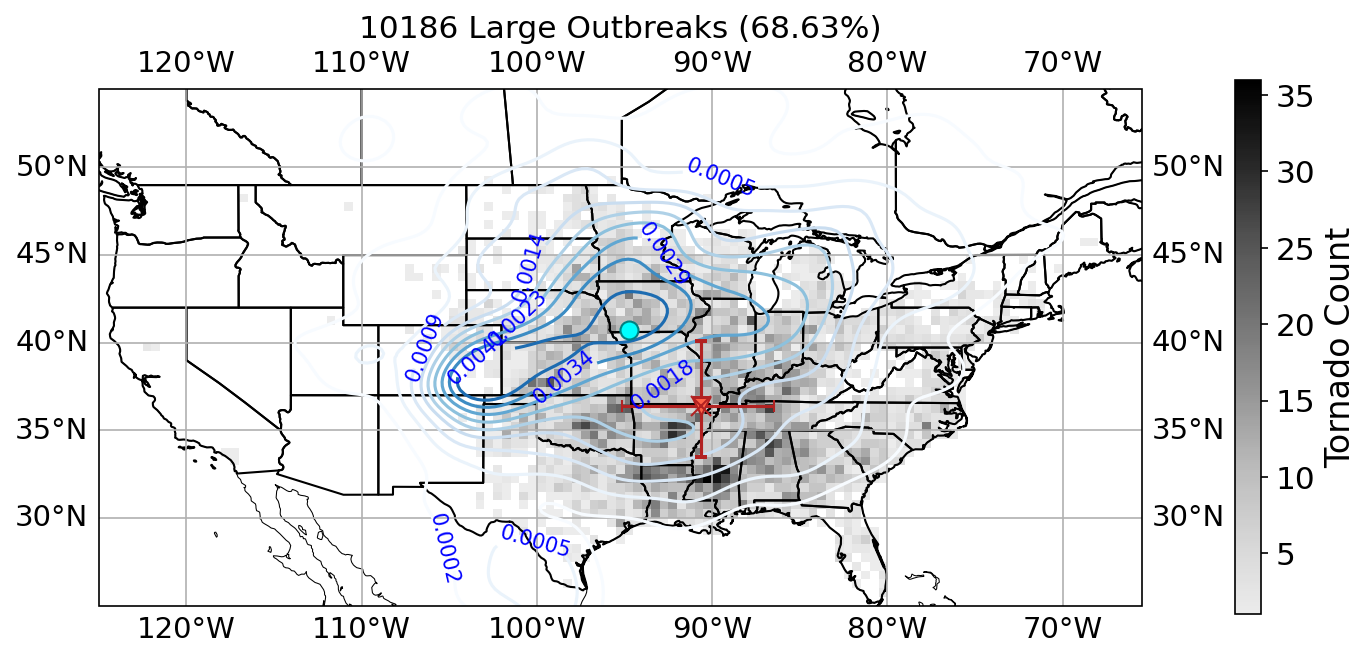

In [ ]:
# Run outbreak size plots
all_assoc_tor = '%s/1980-2022_assoc_tor_and_etcs.csv' % data_dir
# If outbreak sizes were changed, change file names here
one_off_tor = '%s/1980-2022_outbreak_1_1.csv' % data_dir
small_outbreaks = '%s/1980-2022_outbreak_2_5.csv' % data_dir
large_outbreaks = '%s/1980-2022_outbreak_6_100000.csv' % data_dir
full_len = 0

# All warm sector tornadoes
if os.path.exists(all_assoc_tor):
    tor_df = pd.read_csv(all_assoc_tor, header=[0])
    full_len = len(tor_df)
    len_diff = len(tor_df) / full_len * 100
    title = '{} All Tornadoes ({:0.2f}%)'.format(full_len, len_diff)
    #torOutDistr(tor_df, title, "all")
    title = '{} All Tornadoes ({:0.2f}%)'.format(full_len, len_diff)
    torOutGeo(tor_df, title, "all")
    title = '{} All Tornadoes ({:0.2f}%)'.format(full_len, len_diff)
   # torOutWindrose(tor_df, title, "all")

# Isolated tornadoes
if os.path.exists(one_off_tor):
    one_df = pd.read_csv(one_off_tor, header=[0])
    len_diff = len(one_df) / full_len * 100
    title = '{} Isolated Tornadoes ({:0.2f}%)'.format(len(one_df), len_diff)
   # torOutDistr(one_df, title, "isolated_outbreak")
    title = '{} Isolated Tornadoes ({:0.2f}%)'.format(len(one_df), len_diff)
    torOutGeo(one_df, title, "isolated_outbreak")
    title = '{} Isolated Tornadoes ({:0.2f}%)'.format(len(one_df), len_diff)
  #  torOutWindrose(one_df, title, "isolated_outbreak")

# Small outbreaks (2-5 tornadoes)
if os.path.exists(small_outbreaks):
    small_df = pd.read_csv(small_outbreaks, header=[0])
    len_diff = len(small_df) / full_len * 100
    title = '{} Small Outbreaks ({:0.2f}%)'.format(len(small_df), len_diff)
  #  torOutDistr(small_df, title, "small_outbreak")
    title = '{} Small Outbreaks ({:0.2f}%)'.format(len(small_df), len_diff)
    torOutGeo(small_df, title, "small_outbreak")
    title = '{} Small Outbreaks ({:0.2f}%)'.format(len(small_df), len_diff)
 #   torOutWindrose(small_df, title, "small_outbreak")

# Large outbreaks (6+ tornadoes)
if os.path.exists(large_outbreaks):
    large_df = pd.read_csv(large_outbreaks, header=[0])
    len_diff = len(large_df) / full_len * 100
    title = '{} Large Outbreaks ({:0.2f}%)'.format(len(large_df), len_diff)
  #  torOutDistr(large_df, title, "large_outbreak")
    title = '{} Large Outbreaks ({:0.2f}%)'.format(len(large_df), len_diff)
    torOutGeo(large_df, title, "large_outbreak")
    title = '{} Large Outbreaks ({:0.2f}%)'.format(len(large_df), len_diff)
  #  torOutWindrose(large_df, title, "large_outbreak")

# F/EF Levels

In [ ]:
# Color maps used for each intensity level
ef_cmap_colors = [ListedColormap(plt.cm.Purples(np.linspace(0.3, 1, 256))),
                  ListedColormap(plt.cm.Blues(np.linspace(0.3, 1, 256))),
                  ListedColormap(plt.cm.Greens(np.linspace(0.3, 1, 256)))]
                  # Uncomment if splitting up F/EF-2 and F/EF-3
                  # ListedColormap(plt.cm.Wistia(np.linspace(0, 0.7, 256)))]
                  # Uncomment if splitting up F/EF-4 and -5
                  # ListedColormap(plt.cm.Reds(np.linspace(0.2, 0.9, 256)))]
# Combining strong tornadoes into one and violent tornadoes into one
#levels = [[1], [2], [3], [4, 5]]
levels = [[1], [2, 3], [4, 5]]


# Methods used for F/EF level plots
def torEFGeo(ef_df, title, c, ef):
    # Initialize figure, set size and resolution
    fig = plt.figure(figsize=(10, 8), dpi=150)
    fig.set_facecolor('white')

    # create axis using cartopy projections, add in coastlines & grid
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, color='black', zorder=2)
    ax.add_feature(cfeature.STATES, edgecolor='black')
    ax.grid(visible=True)

    # create gridlines and format labels
    gl = ax.gridlines(draw_labels=True, zorder=3)
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabels_top = gl.ylabels_right = False
    gl.xlines = gl.ylines = True
    gl.xlabel_style = {'size': 14}
    gl.ylabel_style = {'size': 14}

    # 2d histogram
    x_bin_edges = np.arange(-125, -65, 0.5)
    y_bin_edges = np.arange(25, 55, 0.5)
    counts, xedges, yedges, im = ax.hist2d(ef_df['slon'], ef_df['slat'],
                                           transform=ccrs.PlateCarree(),
                                           bins=(x_bin_edges, y_bin_edges),
                                           cmap=ef_cmap_colors[c], cmin=1)

    cbar = plt.colorbar(im, ax=ax, fraction=0.023, pad=0.08)
    cbar.set_label("Tornado Count", fontsize=16)
    cbar.ax.tick_params(labelsize=15)

    ax = sns.kdeplot(data=ef_df, x="closest_etclon", y="closest_etclat",cmap=plt.cm.YlOrRd)#, cbar=False, cbar_kws={'shrink': .5})
    contour_set = ax.get_children()[-1]
    # Then loop through contour levels and add labels as:
    for collection in ax.collections:
        if isinstance(collection, mcontour.QuadContourSet):
            levels = collection.levels
            levels_to_label = levels[::1] # every level
            plt.clabel(collection, inline=1, fontsize=10, colors="red", fmt='%1.4f', levels=levels_to_label)

    # ax = sns.kdeplot(data=ef_df, x="closest_etclon", y="closest_etclat", cmap=plt.cm.Greys)#, cbar=False, cbar_kws={'shrink': .5})
    # cbar = ax.figure.colorbar(ax.collections[-1], ax=ax, orientation='horizontal', pad=0.05)
    # cbar.set_label('ETC Density')
    # cbar.ax.xaxis.label.set_size(16)
    # cbar.ax.tick_params(labelsize=13, rotation=45)

    median_lon_tor = ef_df['slon'].median()
    median_lat_tor = ef_df['slat'].median()
    median_lon_ext = ef_df['closest_etclon'].median()
    median_lat_ext = ef_df['closest_etclat'].median()
    ax.scatter(median_lon_tor, median_lat_tor, transform=ccrs.PlateCarree(),
               marker='v', s=75, c='tomato', edgecolors='firebrick', zorder=5)
    ax.scatter(median_lon_ext, median_lat_ext, transform=ccrs.PlateCarree(),
               marker='o', s=75, c='cyan', edgecolors='teal', zorder=5)

    # Percentiles
    perc_25_lon = ef_df['slon'].quantile(0.25)
    perc_25_lat = ef_df['slat'].quantile(0.25)
    perc_75_lon = ef_df['slon'].quantile(0.75)
    perc_75_lat = ef_df['slat'].quantile(0.75)

    ax.errorbar(median_lon_tor, median_lat_tor,
                xerr=[[median_lon_tor - perc_25_lon], [perc_75_lon - median_lon_tor]],
                yerr=[[median_lat_tor - perc_25_lat], [perc_75_lat - median_lat_tor]],
                fmt='x', ms='10', color='firebrick', capsize=3)

    # # Standard deviation of tornado and ETC
    # std_lon_tor = ef_df['slon'].std()
    # std_lat_tor = ef_df['slat'].std()
    # std_lon_etc = ef_df['closest_etclon'].std()
    # std_lat_etc = ef_df['closest_etclat'].std()

    # # Add circles indicating ±1 standard deviation around the medians
    # tor_circle = plt.Circle((median_lon_tor, median_lat_tor), std_lon_tor, color='red', fill=False, transform=ccrs.PlateCarree(), zorder=1)
    # etc_circle = plt.Circle((median_lon_etc, median_lat_etc), std_lon_etc, color='blue', fill=False, transform=ccrs.PlateCarree(), zorder=1)
    # ax.add_patch(tor_circle)
    # ax.add_patch(etc_circle)

    plt.title(title, fontsize=16)

    save_dir = '%s/1980-2022' % plots_dir
    if os.path.exists(save_dir):
        plt.savefig("%s/geo_dens_ef%s.png" % (save_dir, ef), bbox_inches='tight', dpi=300)
    else:
        os.mkdir(save_dir)
        plt.savefig("%s/geo_dens_ef%s.png" % (save_dir, ef), bbox_inches='tight', dpi=300)

def haversine(lat1, lon1, lat2, lon2):
    # Convert degrees to radians
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    # Haversine formula
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

    # Earth's radius in kilometers (can also use miles: 3959)
    radius = 6371

    # Calculate the distance
    distance = radius * c
    return distance

def torEFDistr(ef_df, title, c, ef):
    # Create a figure with 6 plot areas
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.set_title(title, fontsize=20)

    # Axis labels
    ax.set_xlabel('Δ degrees longitude', fontsize=20)
    ax.set_ylabel('Δ degrees latitude', fontsize=20)
    ax.tick_params(labelsize=18)

    # (0,0) lines
    ax.axvline(0, ymin=-40, ymax=40, color='black', linewidth=.5)
    ax.axhline(0, xmin=0, xmax=1, color='black', linewidth=.5)

    # Centralized ETC marker
    ax.plot(0, 0, marker="o", markersize=8, c="cyan", mec='teal', label='ETC Center')

    # Set coordinates relative to centralized ETC
    new_coord = pd.DataFrame()

    # Define new lat and lon relative to ETC
    if not ef_df.empty:
        for index, row in ef_df.iterrows():
            tor_lat = ef_df['slat'][index] - ef_df['closest_etclat'][index]
            tor_lon = ef_df['slon'][index] - ef_df['closest_etclon'][index]
            df = pd.DataFrame({"slat": [tor_lat], "slon": [tor_lon]})
            # new_coord = new_coord.append(df, ignore_index=True)
            new_coord = pd.concat([new_coord, df], ignore_index=True)

        # 2d histogram
        x_bin_edges = np.arange(-40, 42, 1)
        y_bin_edges = np.arange(-20, 22, 1)
        counts, xedges, yedges, im = ax.hist2d(new_coord['slon'], new_coord['slat'],
                                               bins=(x_bin_edges, y_bin_edges),
                                               cmin=1, cmap=ef_cmap_colors[c])
        cbar = plt.colorbar(im, ax=ax, fraction=0.05, pad=0.05)
        cbar.set_label("Tornado Count", fontsize=20)
        cbar.ax.tick_params(labelsize=18)

        # Median lat/lon
        median_lon = new_coord['slon'].median()
        median_lat = new_coord['slat'].median()
        median_lon_etc = ef_df['closest_etclon'].median()
        median_lat_etc = ef_df['closest_etclat'].median()

        #dista = math.sqrt((111.325 * (median_lat))**2 + (111.325 * math.cos(35*math.pi/180) * median_lon)**2)
        dista = haversine(median_lat_etc, median_lon_etc, median_lat_etc + median_lat, median_lon_etc + median_lon)

        # Percentiles
        perc_25_lon = new_coord['slon'].quantile(0.25)
        perc_25_lat = new_coord['slat'].quantile(0.25)
        perc_75_lon = new_coord['slon'].quantile(0.75)
        perc_75_lat = new_coord['slat'].quantile(0.75)

        ax.errorbar(median_lon, median_lat,
                    xerr=[[median_lon - perc_25_lon], [perc_75_lon - median_lon]],
                    yerr=[[median_lat - perc_25_lat], [perc_75_lat - median_lat]],
                    fmt='x', ms='10', color='tomato', capsize=3)

        ax.text(0.02, 0.98, f'Median: ({median_lon:.2f}, {median_lat:.2f})',
                transform=ax.transAxes, fontsize=15, verticalalignment='top', horizontalalignment='left')
        ax.text(0.02, 0.94, f'Median distance from origin: {format(dista,".2f")}',
                transform=ax.transAxes, fontsize=15, verticalalignment='top', horizontalalignment='left')
        ax.text(0.02, 0.90, f'25th Percentile: ({perc_25_lon:.2f}, {perc_25_lat:.2f})',
                transform=ax.transAxes, fontsize=15, verticalalignment='top', horizontalalignment='left')
        ax.text(0.02, 0.86, f'75th Percentile: ({perc_75_lon:.2f}, {perc_75_lat:.2f})',
                transform=ax.transAxes, fontsize=15, verticalalignment='top', horizontalalignment='left')

    save_dir = '%s/1980-2022' % plots_dir
    if os.path.exists(save_dir):
        plt.savefig("%s/distr_dens_ef%s.png" % (save_dir, ef), bbox_inches='tight', dpi=300)
    else:
        os.mkdir(save_dir)
        plt.savefig("%s/distr_dens_ef%s.png" % (save_dir, ef), bbox_inches='tight', dpi=300)


def torEFWindrose(ef_df, title, ef):
    df = pd.DataFrame()

    # Center etc tracks
    for index, row in ef_df.iterrows():
        dx = ef_df['slon'][index] - ef_df['closest_etclon'][index]
        dy = ef_df['slat'][index] - ef_df['closest_etclat'][index]
        degrees_temp = math.atan2(dx, dy)/math.pi*180
        if degrees_temp < 0:
            degrees_final = 360 + degrees_temp
        else:
            degrees_final = degrees_temp
        dg_df = pd.DataFrame({"dx": [dx], "dy": [dy], "dist": [ef_df["distance"][index]], "degrees": [degrees_final]})
        # df = df.append(dg_df, ignore_index=True)
        df = pd.concat([df, dg_df], ignore_index=True)
        del dg_df
    if not df.empty:
        ax = WindroseAxes.from_ax()
        ax.bar(df["degrees"], df["dist"], normed=True, opening=0.8, edgecolor='white', bins=np.arange(0, 2000, 300))
        ax.set_yticks(np.arange(3, 24, step=3))
        ax.set_yticklabels(np.arange(3, 24, step=3))
        ax.tick_params(labelsize=17)
        ax.legend(fontsize=17, loc='upper left')
        plt.title(title, fontsize=22, y=1.10, pad=-14)

        save_dir = '%s/1980-2022' % plots_dir
        if os.path.exists(save_dir):
            plt.savefig("%s/windrose_ef%s.png" % (save_dir, ef), bbox_inches='tight', dpi=300)
        else:
            os.mkdir(save_dir)
            plt.savefig("%s/windrose_ef%s.png" % (save_dir, ef), bbox_inches='tight', dpi=300)
        plt.show()
        del ax
    del df

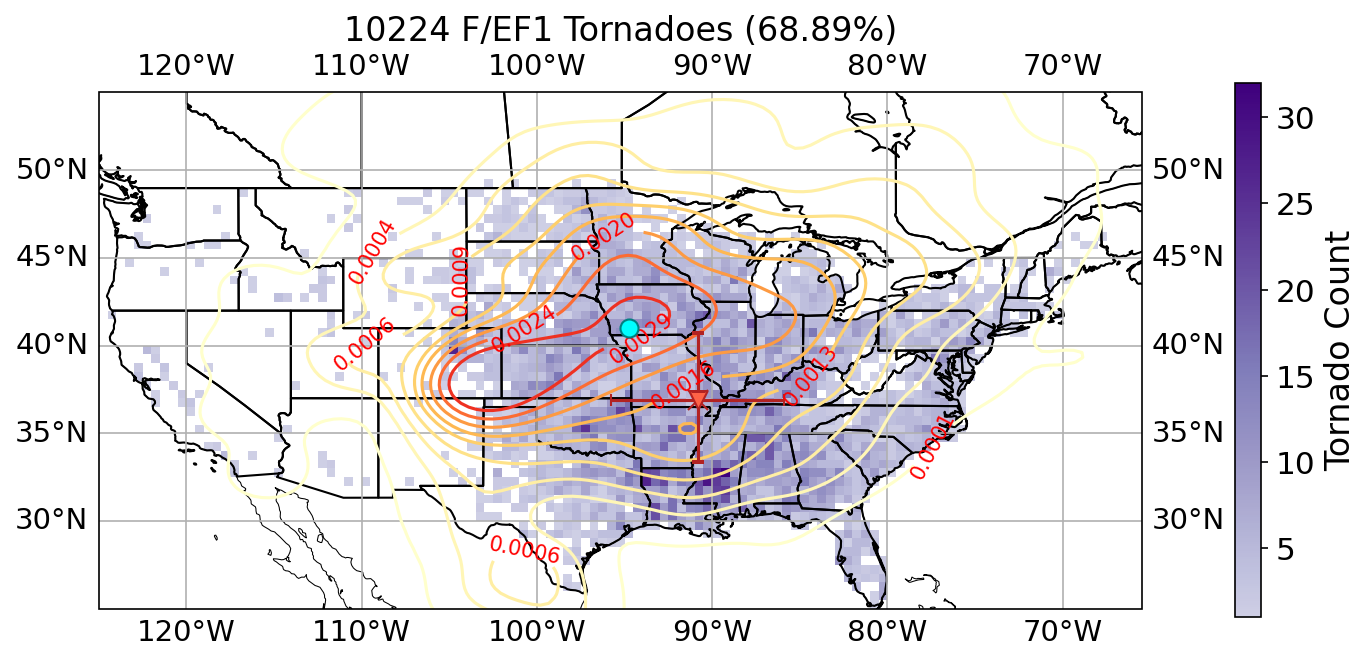

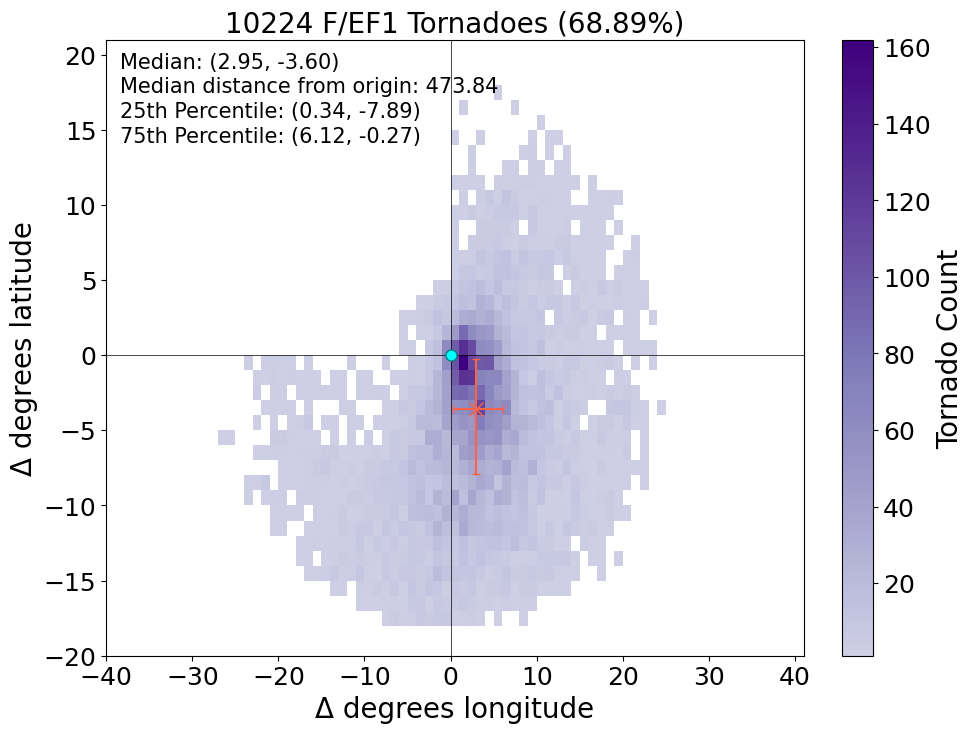

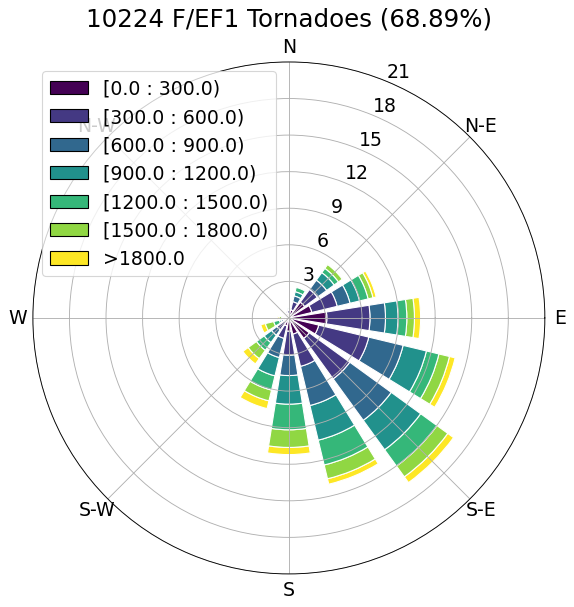

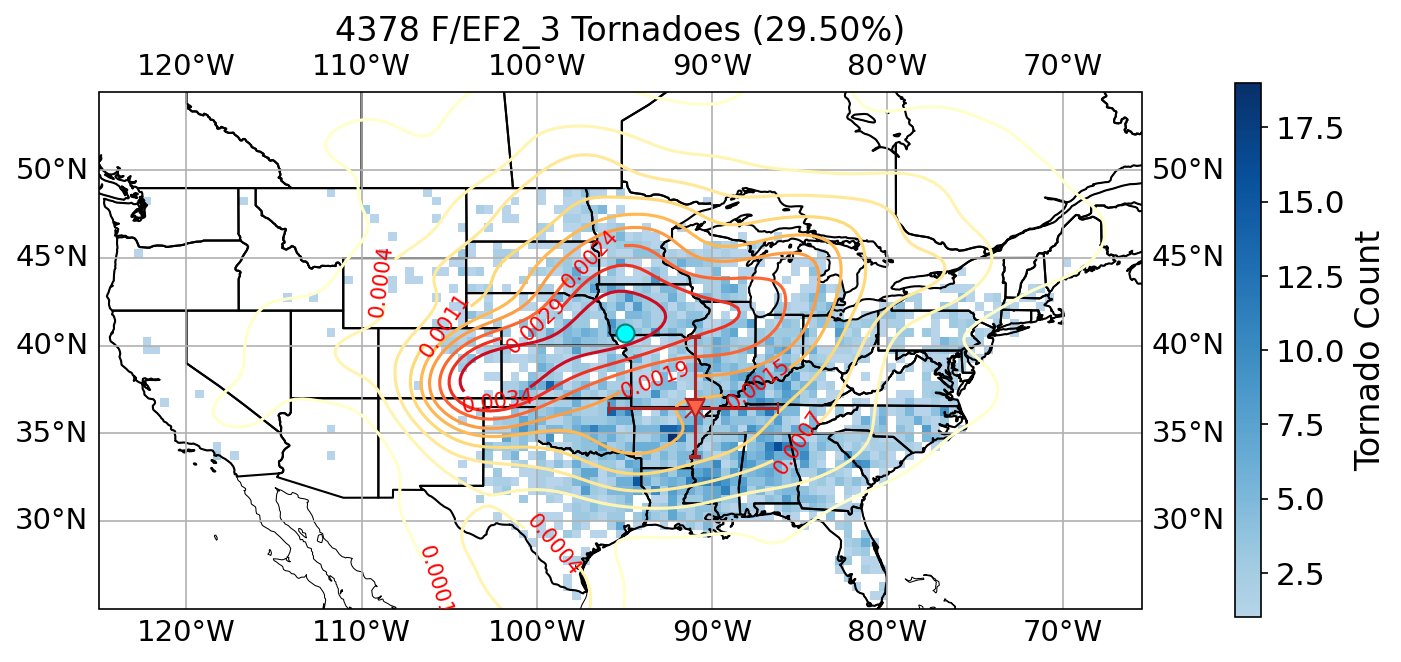

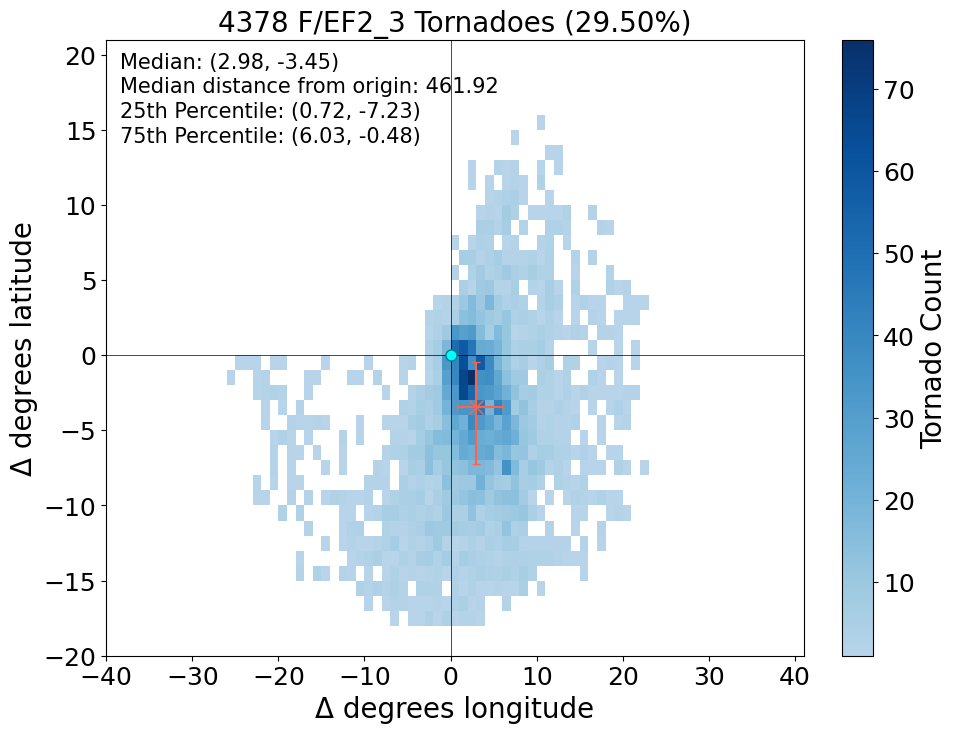

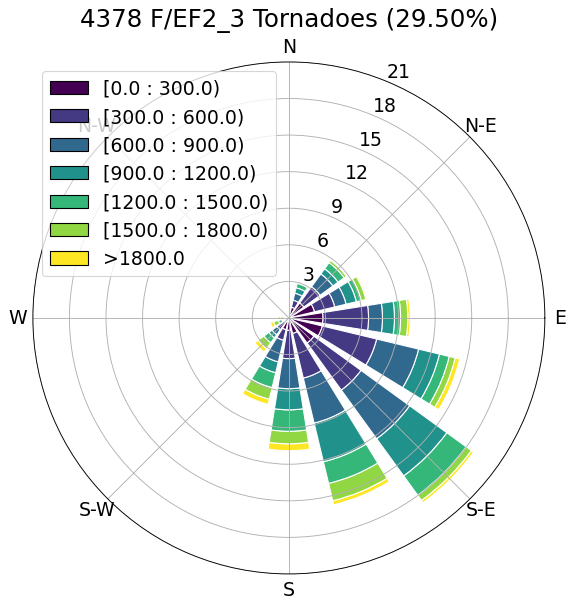

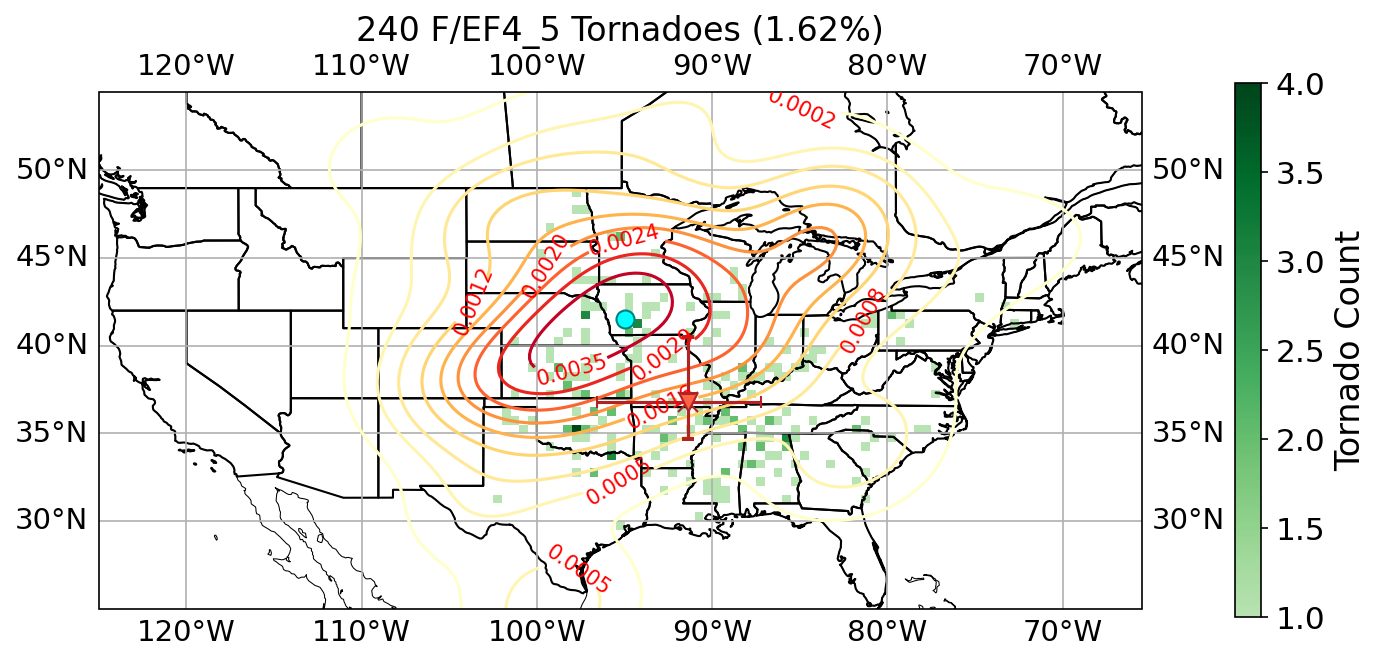

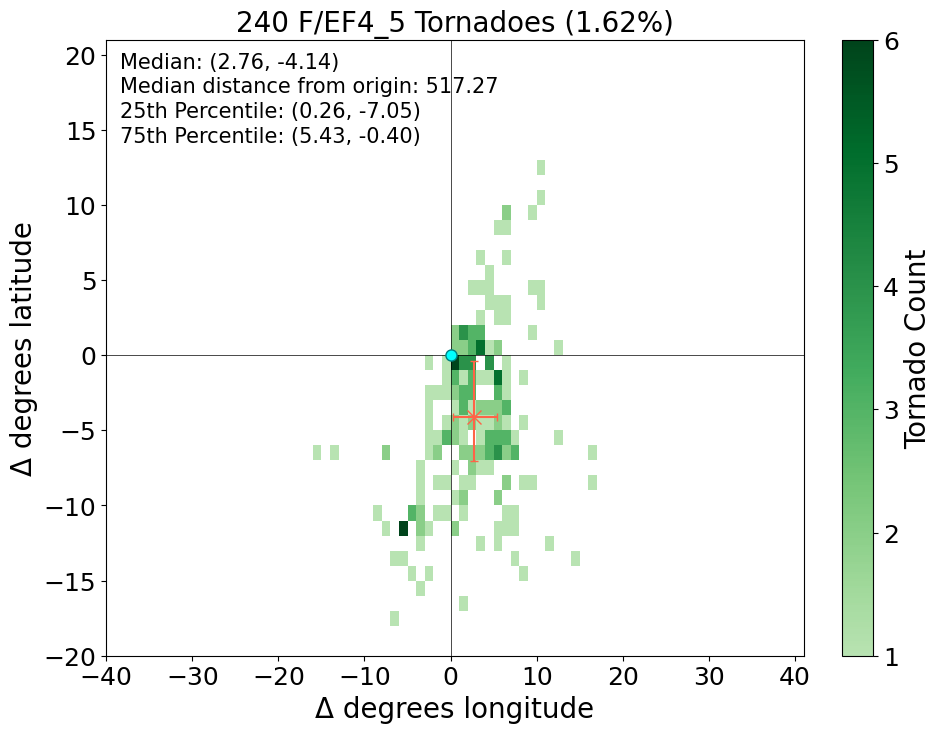

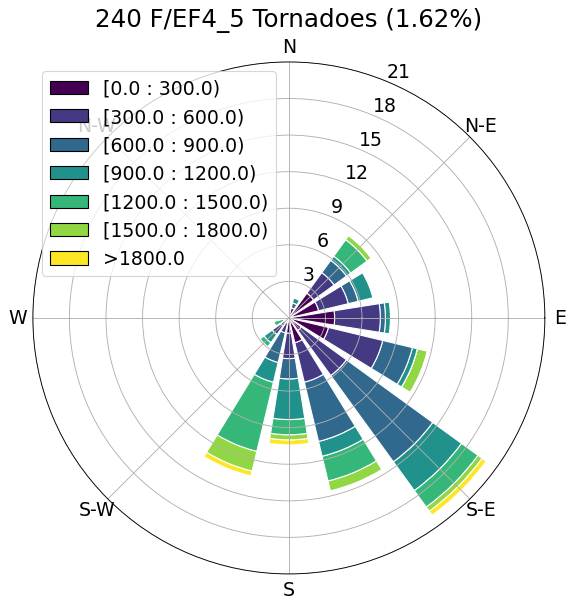

CPU times: user 49.7 s, sys: 243 ms, total: 50 s
Wall time: 58.7 s


In [ ]:
%%time
# Run F/EF level plots
tor_file = '%s/1980-2022_assoc_tor_and_etcs.csv' % data_dir
# Used to determine colormap
c=0

if os.path.exists(tor_file):
    tor_data = pd.read_csv(tor_file, header=[0])
    all_tor = len(tor_data)

    if not tor_data.empty:
        for ef in levels:
            ef_df = tor_data[tor_data['mag'].isin(ef)]
            if len(ef) > 1:
                ef = '%s_%s' % (ef[0], ef[1])
            else:
                ef = str(ef[0])
            title = "{} F/EF{} Tornadoes ({:0.2f}%)".format(len(ef_df), ef, len(ef_df)/all_tor*100)
            torEFGeo(ef_df, title, c, ef)
            title = "{} F/EF{} Tornadoes ({:0.2f}%)".format(len(ef_df), ef, len(ef_df)/all_tor*100)
            torEFDistr(ef_df, title, c, ef)
            title = "{} F/EF{} Tornadoes ({:0.2f}%)".format(len(ef_df), ef, len(ef_df)/all_tor*100)
            torEFWindrose(ef_df, title, ef)
            c=c+1

# Seasonal

2356
2356
season
Autumn    2131
Spring    7633
Summer    3124
Winter    1954
Name: associated, dtype: int64


<Figure size 1000x600 with 0 Axes>

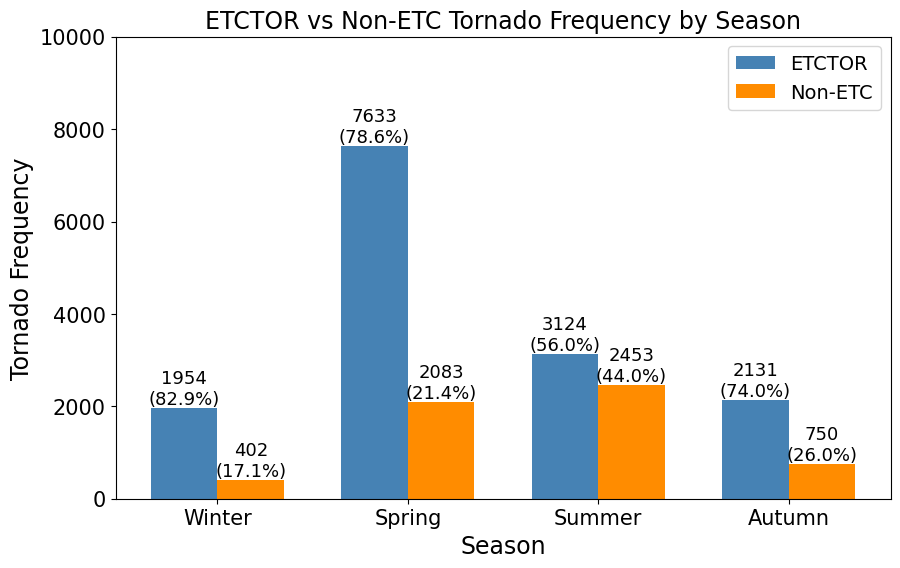

In [ ]:
# Load data
tor_file = '%s/1980-2022_add_non_tc_tor_and_etcs.csv' % data_dir
if os.path.exists(tor_file):
    data = pd.read_csv(tor_file, header=[0])
    print(len(data[data['utcmo'].isin([12, 1, 2])]))

    # Assign season based on month
    def assign_season(month):
        if month in [12, 1, 2]:  # Winter: Dec, Jan, Feb
            return 'Winter'
        elif month in [3, 4, 5]:  # Spring: Mar, Apr, May
            return 'Spring'
        elif month in [6, 7, 8]:  # Summer: Jun, Jul, Aug
            return 'Summer'
        elif month in [9, 10, 11]:  # Autumn: Sep, Oct, Nov
            return 'Autumn'

    data['season'] = data['utcmo'].apply(assign_season)

    print(len(data[data['season'] == 'Winter']))


    # Group by season and calculate the number of ETCTOR (associated) and non-ETC (non_associated) tornadoes
    season_data = data.groupby('season').apply(lambda group: {
        'associated': len(
            group[
                group['closest_etclat'].notna() &
                (
                   # ((group['distance'] <= 2000) & ~((group['slon'] - group['closest_etclon']) < 0) & ~((group['slat'] - group['closest_etclat']) > 0)) |
                  ((group['distance'] <= 2000) & ((group['slon'] - group['closest_etclon']) <= 0) & ((group['slat'] - group['closest_etclat']) <= 0)) |
                  ((group['distance'] <= 2000) & ((group['slon'] - group['closest_etclon']) >= 0) & ((group['slat'] - group['closest_etclat']) >= 0)) |
                  ((group['distance'] <= 2000) & ((group['slon'] - group['closest_etclon']) >= 0) & ((group['slat'] - group['closest_etclat']) <= 0)) |
                  ((group['distance'] <= 500) & ((group['slon'] - group['closest_etclon']) < 0) & ((group['slat'] - group['closest_etclat']) > 0))
                )
            ]
        ),
        'non_associated': len(
            group[
                group['closest_etclat'].isna() |
                (group['distance'] > 2000) |
                ((group['distance'] > 500) & ((group['slon'] - group['closest_etclon']) < 0) & ((group['slat'] - group['closest_etclat']) > 0))
            ]
        ),
    }).apply(pd.Series)

    print(season_data['associated'])

    # Explicitly order the seasons
    season_order = ['Winter', 'Spring', 'Summer', 'Autumn']
    season_data = season_data.loc[season_order]

    # Plot
    plt.figure(figsize=(10, 6))
    width = 0.35  # Bar width
    seasons = season_data.index
    x = np.arange(len(seasons))

    fig, ax = plt.subplots(figsize=(10, 6))

    # Plot ETCTOR (associated) and non-ETC (non-associated) tornadoes for each season
    bars1 = ax.bar(x - width / 2, season_data['associated'], width, label='ETCTOR', color='steelblue')
    bars2 = ax.bar(x + width / 2, season_data['non_associated'], width, label='Non-ETC', color='darkorange')

    i=0
    # Add frequency labels above the bars
    for bar in bars1:
        yval = bar.get_height()
        total = yval + bars2[i].get_height()
        percentage = 100 * yval / total if total > 0 else 0
        ax.text(bar.get_x() + bar.get_width() / 2, yval + 2, f'{yval:.0f}\n({percentage:.1f}%)', ha='center', va='bottom', fontsize=13)
        i=i+1

    i=0
    for bar in bars2:
        yval = bar.get_height()
        total = bars1[i].get_height() + yval
        percentage = 100 * yval / total if total > 0 else 0
        ax.text(bar.get_x() + bar.get_width() / 2, yval + 1, f'{yval:.0f}\n({percentage:.1f}%)', ha='center', va='bottom', fontsize=13)
        i=i+1

    # Add title and labels
    ax.set_title('ETCTOR vs Non-ETC Tornado Frequency by Season', fontsize=17)
    ax.set_xlabel('Season', fontsize=17)
    ax.set_ylabel('Tornado Frequency', fontsize=17)
    ax.set_ylim(0, 10000)
    ax.set_xticks(x)
    ax.set_xticklabels(seasons, fontsize=15)
    ax.tick_params(labelsize=15)

    # Add a legend
    ax.legend(fontsize=14)

    # Save the plot
    save_dir = '%s/1980-2022' % plots_dir
    if os.path.exists(save_dir):
        plt.savefig("%s/seasonal_assoc_nonassoc_tornado_frequency.png" % (save_dir), bbox_inches='tight', dpi=300)
    else:
        os.mkdir(save_dir)
        plt.savefig("%s/seasonal_assoc_nonassoc_tornado_frequency.png" % (save_dir), bbox_inches='tight', dpi=300)

    # Show the plot
    plt.show()

In [ ]:
szns = ['winter', 'spring', 'summer', 'autumn']
szn_cmap_colors = [ListedColormap(plt.cm.winter(np.linspace(0.1, 1, 256))),
                   ListedColormap(plt.cm.spring(np.linspace(0.1, 1, 256))),
                   ListedColormap(plt.cm.summer(np.linspace(0.1, 1, 256))),
                   ListedColormap(plt.cm.autumn(np.linspace(0.1, 1, 256)))]
szn_etc_colors = [ListedColormap(plt.cm.Wistia(np.linspace(0.1, 1, 256))),
                  ListedColormap(plt.cm.winter(np.linspace(0.1, 1, 256))),
                  ListedColormap(plt.cm.cool_r(np.linspace(0.1, 1, 256))),
                  ListedColormap(plt.cm.winter(np.linspace(0.1, 1, 256)))]
szn_contour_colors = ["darkorange", "blue", "darkviolet", "blue"]
szn_mo = [[1, 2, 12], [3, 4, 5], [6, 7, 8], [9, 10, 11]]


# Methods used for seasonal plots
def torSznGeo(season_df, title, c, col, etc_col, contour_col):
    # Initialize figure, set size and resolution
    fig = plt.figure(figsize=(10, 8), dpi=150)
    fig.set_facecolor('white')

    # create axis using cartopy projections, add in coastlines & grid
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, color='black', zorder=2)
    ax.add_feature(cfeature.STATES, edgecolor='black')
    ax.grid(visible=True)

    # create gridlines and format labels
    gl = ax.gridlines(draw_labels=True, zorder=3)
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabels_top = gl.ylabels_right = False
    gl.xlines = gl.ylines = True
    gl.xlabel_style = {'size': 14}
    gl.ylabel_style = {'size': 14}

    # 2d histogram
    x_bin_edges = np.arange(-125, -65, 0.5)
    y_bin_edges = np.arange(25, 55, 0.5)
    counts, xedges, yedges, im = ax.hist2d(season_df['slon'], season_df['slat'],
                                           transform=ccrs.PlateCarree(), bins=(x_bin_edges, y_bin_edges),
                                           cmap=col, cmin=1)

    cbar = plt.colorbar(im, ax=ax, fraction=0.025, pad=0.08)#, label="%s tornadoes" % len(season_df))
    cbar.set_label(label="Tornado Count", size=17)
    cbar.ax.tick_params(labelsize=15)

    ax = sns.kdeplot(data=season_df, x="closest_etclon", y="closest_etclat",cmap=etc_col)#, cbar=False, cbar_kws={'shrink': .5})
    contour_set = ax.get_children()[-1]  # Could be contour set
    # Then loop through contour levels and add labels as:
    for collection in ax.collections:
        if isinstance(collection, mcontour.QuadContourSet):
            levels = collection.levels
            levels_to_label = levels[::1] # every level
            plt.clabel(collection, inline=1, fontsize=10, fmt='%1.4f', levels=levels_to_label, colors=contour_col)

    median_lon_tor = season_df['slon'].median()
    median_lat_tor = season_df['slat'].median()
    median_lon_etc = season_df['closest_etclon'].median()
    median_lat_etc = season_df['closest_etclat'].median()
    ax.scatter(median_lon_tor, median_lat_tor, transform=ccrs.PlateCarree(),
               marker='v', s=75, c='black', zorder=5)
    ax.scatter(median_lon_etc, median_lat_etc, transform=ccrs.PlateCarree(),
               marker='o', s=75, c='cyan', edgecolors='teal', zorder=5)

    # Percentiles
    perc_25_lon = season_df['slon'].quantile(0.25)
    perc_25_lat = season_df['slat'].quantile(0.25)
    perc_75_lon = season_df['slon'].quantile(0.75)
    perc_75_lat = season_df['slat'].quantile(0.75)

    ax.errorbar(median_lon_tor, median_lat_tor,
                xerr=[[median_lon_tor - perc_25_lon], [perc_75_lon - median_lon_tor]],
                yerr=[[median_lat_tor - perc_25_lat], [perc_75_lat - median_lat_tor]],
                fmt='x', ms='10', color='black', capsize=3)

    plt.title(title, fontsize=17)

    save_dir = '%s/1980-2022' % plots_dir
    if os.path.exists(save_dir):
        plt.savefig("%s/geo_dens_%s.png" % (save_dir, szns[c]), bbox_inches='tight', dpi=300)
    else:
        os.mkdir(save_dir)
        plt.savefig("%s/geo_dens_%s.png" % (save_dir, szns[c]), bbox_inches='tight', dpi=300)

def haversine(lat1, lon1, lat2, lon2):
    # Convert degrees to radians
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    # Haversine formula
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

    # Earth's radius in kilometers (can also use miles: 3959)
    radius = 6371

    # Calculate the distance
    distance = radius * c
    return distance

def torSznDistr(season_df, title, c, col):
    # Create a figure with 6 plot areas
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.set_title(title, fontsize=20)

    # Axis labels
    ax.set_xlabel('Δ degrees longitude', fontsize=20)
    ax.set_ylabel('Δ degrees latitude', fontsize=20)
    ax.tick_params(labelsize=17)

    # (0,0) lines
    ax.axvline(0, ymin=-40, ymax=40, color='black', linewidth=.5)
    ax.axhline(0, xmin=0, xmax=1, color='black', linewidth=.5)

    # Centralized ETC marker
    ax.plot(0, 0, marker="o", markersize=8, c="cyan", mec='teal', label='Centralized ETC')

    # Set coordinates relative to centralized ETC
    new_coord = pd.DataFrame()

    # Define new lat and lon relative to ETC
    if not season_df.empty:
        for index, row in season_df.iterrows():
            tor_lat = season_df['slat'][index] - season_df['closest_etclat'][index]
            tor_lon = season_df['slon'][index] - season_df['closest_etclon'][index]
            df = pd.DataFrame({"slat": [tor_lat], "slon": [tor_lon]})
            # new_coord = new_coord.append(df, ignore_index=True)
            new_coord = pd.concat([new_coord, df], ignore_index=True)

        print(new_coord)
        # 2d histogram
        # x_bin_edges = np.arange(-80, 62, 2)
        # y_bin_edges = np.arange(-50, 32, 2)
        x_bin_edges = np.arange(-40, 42, 1)
        y_bin_edges = np.arange(-20, 22, 1)
        counts, xedges, yedges, im = ax.hist2d(new_coord['slon'], new_coord['slat'],
                                               bins=(x_bin_edges, y_bin_edges), cmin=1, cmap=col)
        cbar = plt.colorbar(im, ax=ax, fraction=0.05, pad=0.05)#, label="%s tornadoes" % len(new_coord))
        cbar.set_label(label="Tornado Count", size=20)
        cbar.ax.tick_params(labelsize=17)

        # Median lat/lon
        median_lon = new_coord['slon'].median()
        median_lat = new_coord['slat'].median()
        median_lon_etc = season_df['closest_etclon'].median()
        median_lat_etc = season_df['closest_etclat'].median()

        #dista = math.sqrt((111.325 * (median_lat))**2 + (111.325 * math.cos(35*math.pi/180) * median_lon)**2)
        dista = haversine(median_lat_etc, median_lon_etc, median_lat_etc + median_lat, median_lon_etc + median_lon)

        # Percentiles
        perc_25_lon = new_coord['slon'].quantile(0.25)
        perc_25_lat = new_coord['slat'].quantile(0.25)
        perc_75_lon = new_coord['slon'].quantile(0.75)
        perc_75_lat = new_coord['slat'].quantile(0.75)

        ax.errorbar(median_lon, median_lat,
                    xerr=[[median_lon - perc_25_lon], [perc_75_lon - median_lon]],
                    yerr=[[median_lat - perc_25_lat], [perc_75_lat - median_lat]],
                    fmt='x', ms='10', color='black', capsize=3)

        ax.text(0.02, 0.98, f'Median: ({median_lon:.2f}, {median_lat:.2f})',
                transform=ax.transAxes, fontsize=15, verticalalignment='top', horizontalalignment='left')
        ax.text(0.02, 0.94, f'Median distance from origin: {format(dista,".2f")}',
                transform=ax.transAxes, fontsize=15, verticalalignment='top', horizontalalignment='left')
        ax.text(0.02, 0.90, f'25th Percentile: ({perc_25_lon:.2f}, {perc_25_lat:.2f})',
                transform=ax.transAxes, fontsize=15, verticalalignment='top', horizontalalignment='left')
        ax.text(0.02, 0.86, f'75th Percentile: ({perc_75_lon:.2f}, {perc_75_lat:.2f})',
                transform=ax.transAxes, fontsize=15, verticalalignment='top', horizontalalignment='left')

    save_dir = '%s/1980-2022' % plots_dir
    if os.path.exists(save_dir):
        plt.savefig("%s/distr_dens_%s.png" % (save_dir, szns[c]), bbox_inches='tight', dpi=300)
    else:
        os.mkdir(save_dir)
        plt.savefig("%s/distr_dens_%s.png" % (save_dir, szns[c]), bbox_inches='tight', dpi=300)


def torSznWindrose(season_df, title, c):
    df = pd.DataFrame()

    # Center etc tracks
    for index, row in season_df.iterrows():
        dx = season_df['slon'][index] - season_df['closest_etclon'][index]
        dy = season_df['slat'][index] - season_df['closest_etclat'][index]
        degrees_temp = math.atan2(dx, dy)/math.pi*180
        if degrees_temp < 0:
            degrees_final = 360 + degrees_temp
        else:
            degrees_final = degrees_temp
        dg_df = pd.DataFrame({"dx": [dx], "dy": [dy], "dist": [season_df["distance"][index]], "degrees": [degrees_final]})
        # df = df.append(dg_df, ignore_index=True)
        df = pd.concat([df, dg_df], ignore_index=True)
        del dg_df
    if not df.empty:
        ax = WindroseAxes.from_ax()
        ax.bar(df["degrees"], df["dist"], normed=True, opening=0.8, edgecolor='white', bins=np.arange(0, 2000, 300))
        ax.set_yticks(np.arange(3, 24, step=3))
        ax.set_yticklabels(np.arange(3, 24, step=3))
        ax.tick_params(labelsize=17)
        ax.legend(fontsize=17, loc='upper left')
        plt.title(title, fontsize=22, y=1.10, pad=-14)

        save_dir = '%s/1980-2022' % plots_dir
        if os.path.exists(save_dir):
            plt.savefig("%s/windrose_%s.png" % (save_dir, szns[c]), bbox_inches='tight', dpi=300)
        else:
            os.mkdir(save_dir)
            plt.savefig("%s/windrose_%s.png" % (save_dir, szns[c]), bbox_inches='tight', dpi=300)
        plt.show()
        del ax
    del df

CPU times: user 21.5 s, sys: 79.6 ms, total: 21.6 s
Wall time: 25.4 s


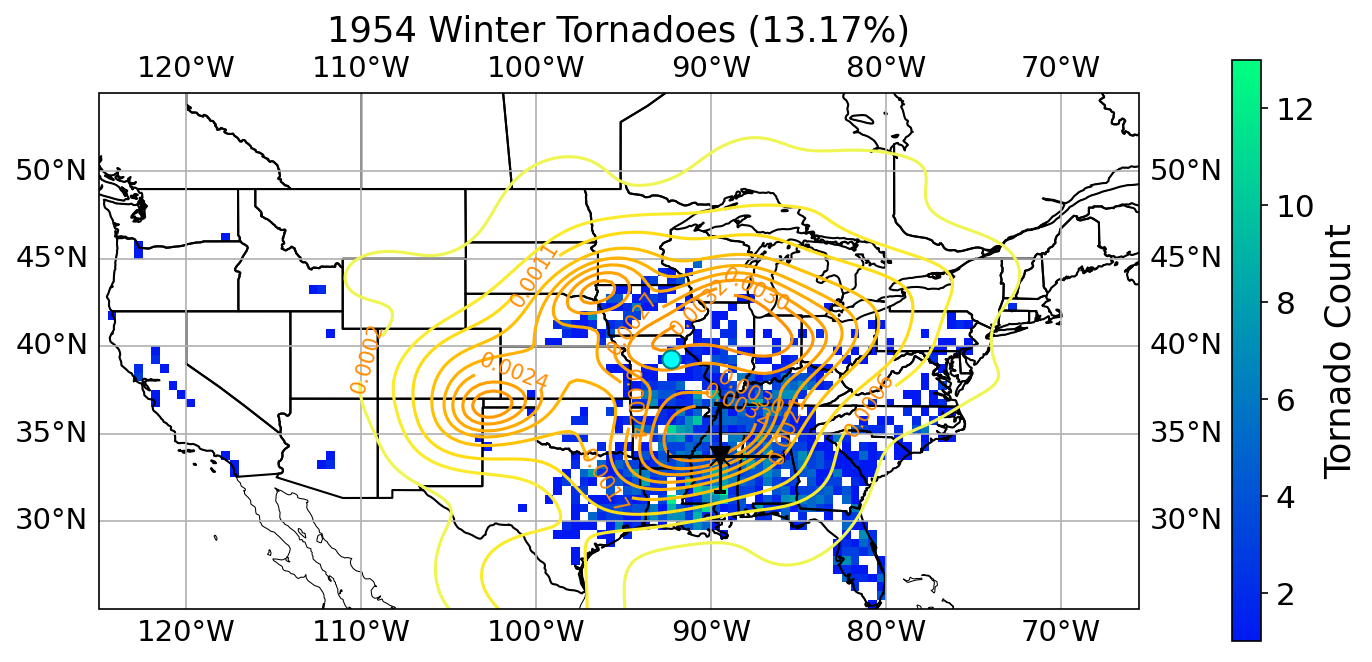

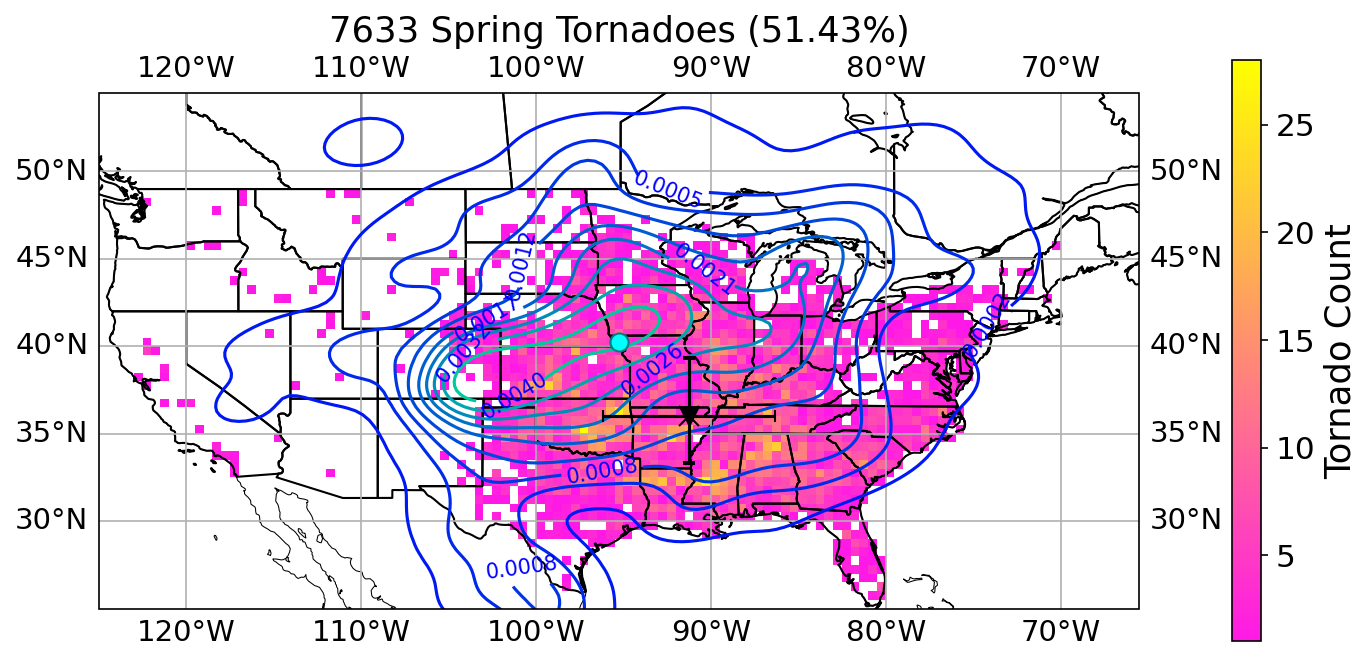

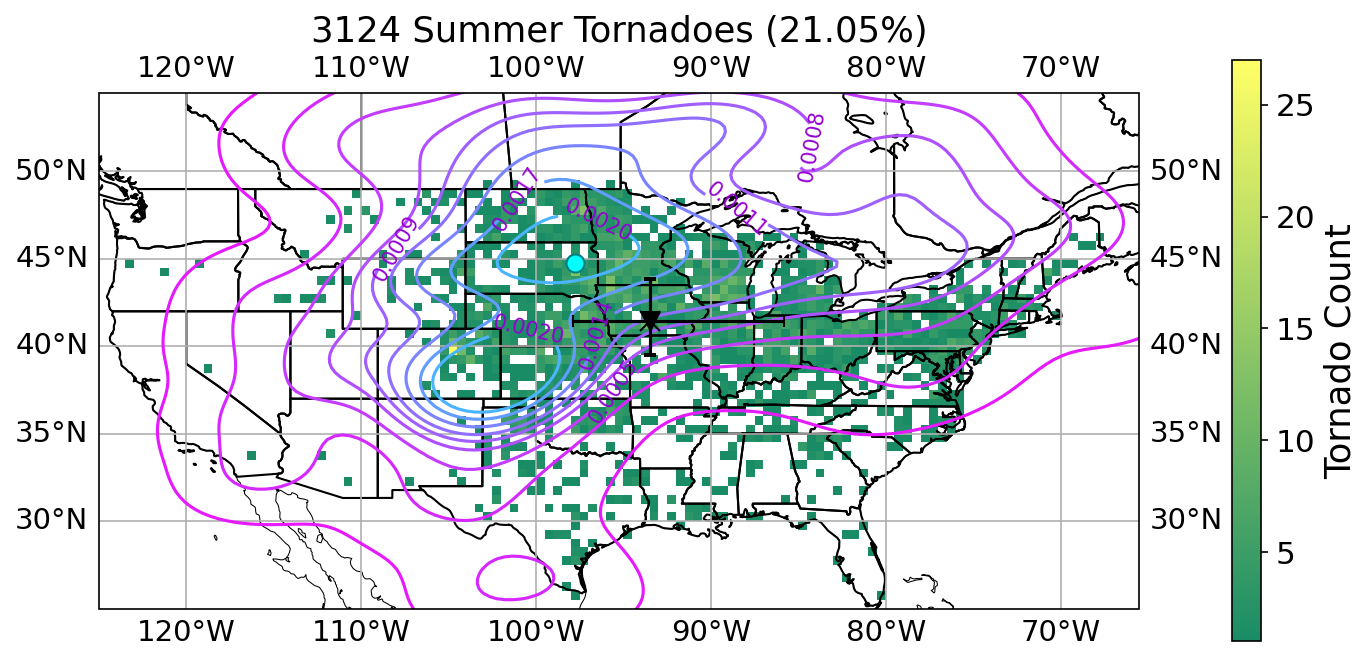

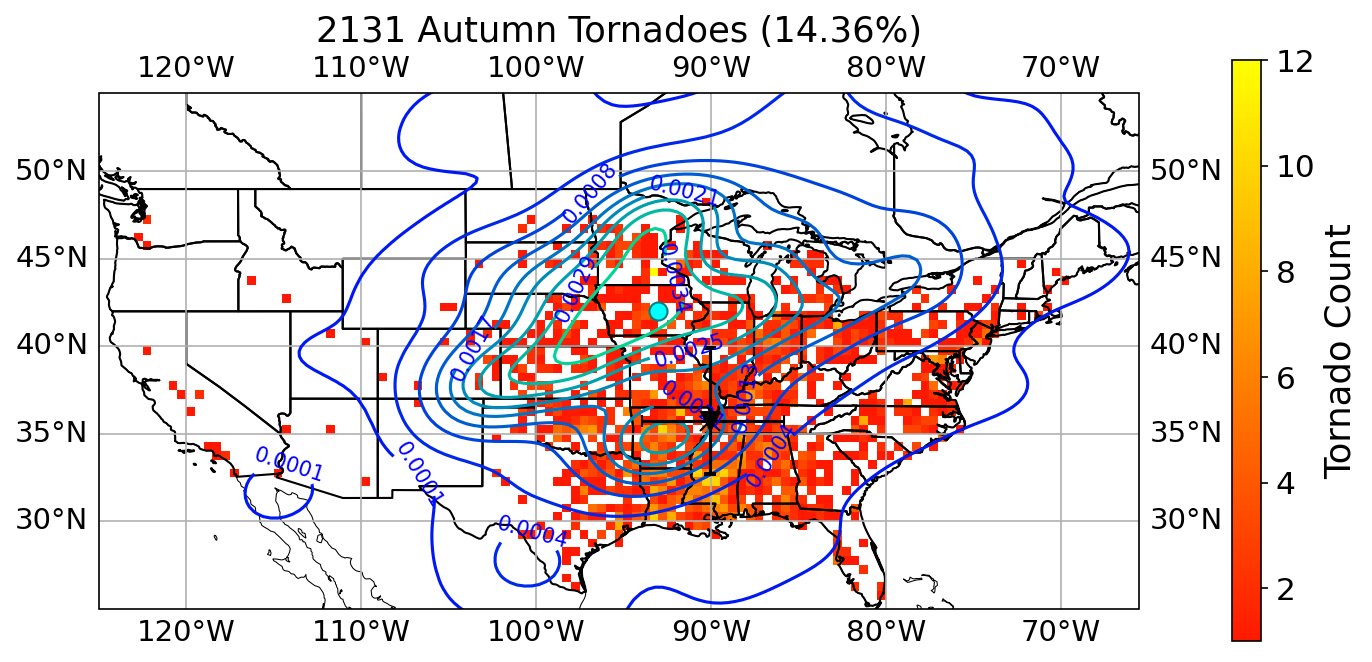

In [ ]:
%%time
# Run seasonal plots
tor_file = '%s/1980-2022_assoc_tor_and_etcs.csv' % data_dir
c=0

if os.path.exists(tor_file):
    tor_data = pd.read_csv(tor_file, header=[0])
    all_tor = len(tor_data)

    if not tor_data.empty:
        for col in szn_cmap_colors:
            season_df = tor_data[tor_data['utcmo'].isin(szn_mo[c])]
            title = "{} {} Tornadoes ({:0.2f}%)".format(len(season_df), szns[c].capitalize(), len(season_df)/all_tor*100)
            torSznGeo(season_df, title, c, col, szn_etc_colors[c], szn_contour_colors[c])
            title = "{} {} Tornadoes ({:0.2f}%)".format(len(season_df), szns[c].capitalize(), len(season_df)/all_tor*100)
            #torSznDistr(season_df, title, c, col)
            title = "{} {} Tornadoes ({:0.2f}%)".format(len(season_df), szns[c].capitalize(), len(season_df)/all_tor*100)
            #torSznWindrose(season_df, title, c)
            c=c+1

# Annual Trends

In [ ]:
# 1980-1989 purples
# 1990-1999 blues
# 2000-2009 greens
# 2010-2019 yellows/oranges
# 2020-2022 reds
color_list = ['mediumvioletred', 'orchid', 'fuchsia', 'violet', 'plum',
              'mediumorchid', 'darkviolet', 'purple', 'rebeccapurple', 'indigo',
              'mediumblue', 'navy', 'blue', 'royalblue', 'cornflowerblue',
              'steelblue', 'dodgerblue', 'deepskyblue', 'darkturquoise', 'aqua',
              'lightseagreen', 'aquamarine', 'springgreen', 'seagreen', 'limegreen',
              'forestgreen', 'palegreen', 'chartreuse', 'olivedrab', 'yellowgreen',
              'yellow', 'khaki', 'gold', 'goldenrod', 'darkgoldenrod',
              'orange', 'wheat', 'burlywood', 'peru', 'sandybrown',
              'red', 'firebrick', 'lightcoral']
begin_year = 1980
end_year = 2022

In [ ]:
def torDistributionAnnual(req_df, year, col, bool):
    # Set coordinates relative to centralized ETC
    new_coord = pd.DataFrame()

    # Define new lat and lon relative to ETC
    filtered_data = req_df.dropna(subset=['closest_etclon', 'closest_etclat'])
    if not filtered_data.empty:
        for index, row in filtered_data.iterrows():
            tor_lat = filtered_data['slat'][index] - filtered_data['closest_etclat'][index]
            tor_lon = filtered_data['slon'][index] - filtered_data['closest_etclon'][index]
            df = pd.DataFrame({"slat": [tor_lat], "slon": [tor_lon]})
            # new_coord = new_coord.append(df, ignore_index=True)
            new_coord = pd.concat([new_coord, df], ignore_index=True)

        # Median lat/lon
        median_lon = new_coord['slon'].median()
        median_lat = new_coord['slat'].median()

        # Percentiles
        perc_25_lon = new_coord['slon'].quantile(0.25)
        perc_25_lat = new_coord['slat'].quantile(0.25)
        perc_75_lon = new_coord['slon'].quantile(0.75)
        perc_75_lat = new_coord['slat'].quantile(0.75)

        if bool:
            ax.errorbar(median_lon, median_lat,
                        xerr=[[median_lon - perc_25_lon], [perc_75_lon - median_lon]],
                        yerr=[[median_lat - perc_25_lat], [perc_75_lat - median_lat]],
                        fmt='x', ms='10', color=col, capsize=3, label=year)
        else:
            ax.errorbar(median_lon, median_lat,
                        fmt='x', ms='10', color=col, capsize=3, label=year)

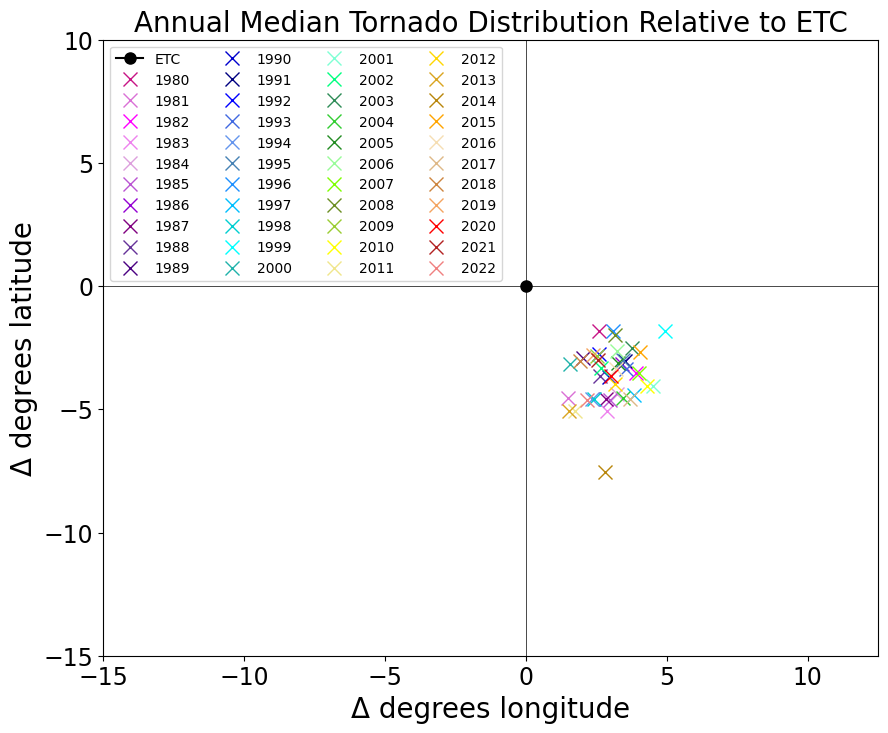

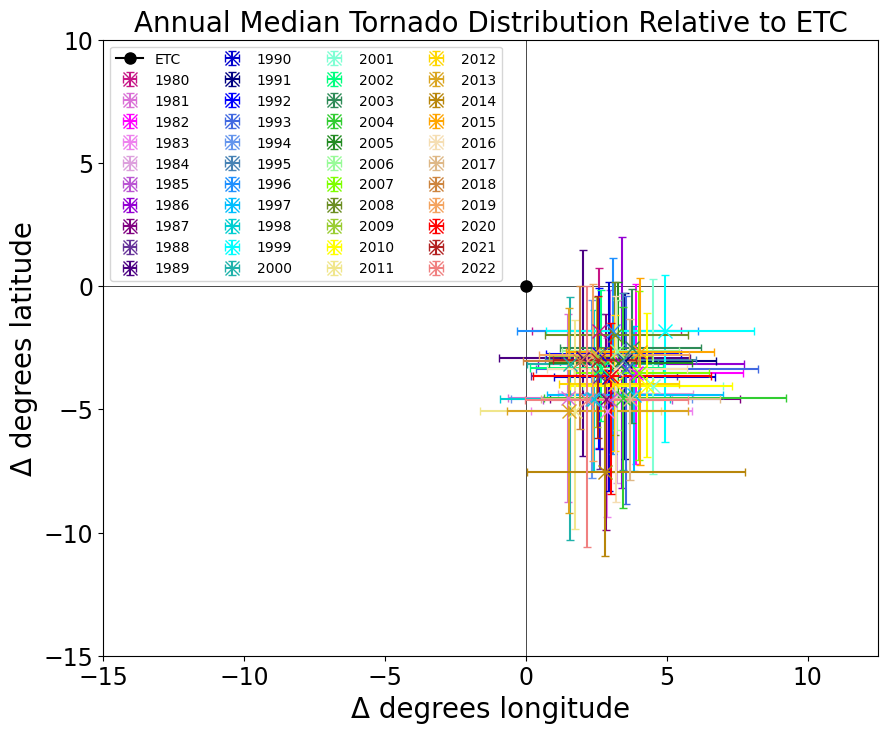

In [ ]:
# Run annual distribution plot
tor_file = '%s/1980-2022_assoc_tor_and_etcs.csv' % data_dir
plots = [["annual_distr_median.png", False], ["annual_distr_median_errs.png", True]]

for plot in plots:
    year = begin_year
    filename = plot[0]
    bool_errs = plot[1]

    title = 'Annual Median Tornado Distribution Relative to ETC'
    c = 0

    # Create a figure with 6 plot areas
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.set_title(title, fontsize=20)

    # Axis limits
    ax.set_xlim([-15, 12.5])
    ax.set_ylim([-15, 10])

    # Axis labels
    ax.set_xlabel('Δ degrees longitude', fontsize=20)
    ax.set_ylabel('Δ degrees latitude', fontsize=20)
    ax.tick_params(labelsize=17)

    # (0,0) lines
    ax.axvline(0, ymin=-40, ymax=40, color='black', linewidth=.5)
    ax.axhline(0, xmin=0, xmax=1, color='black', linewidth=.5)

    # Centralized ETC marker
    ax.plot(0, 0, marker="o", markersize=8, c="black", label='ETC')

    while year <= end_year:
        # All tornadoes
        if os.path.exists(tor_file):
            tor_df = pd.read_csv(tor_file, header=[0])
            tor_df = tor_df[tor_df['utcyr'].isin([year])]
            torDistributionAnnual(tor_df, year, color_list[c], bool_errs)

        year = year + 1
        c = c + 1

    ax.legend(ncol=4, loc='upper left')
    year_save_dir = '%s/annual' % plots_dir
    if os.path.exists(year_save_dir):
        plt.savefig("%s/%s" % (year_save_dir, filename), bbox_inches='tight', dpi=300)
    else:
        os.mkdir(year_save_dir)
        plt.savefig("%s/%s" % (year_save_dir, filename), bbox_inches='tight', dpi=300)
    plt.show()

In [ ]:
def torWindroseAnnual(req_df, year, median_df):
    df = pd.DataFrame()
    # print(req_df)

    # Center etc tracks
    for index, row in req_df.iterrows():
        dx = req_df['slon'][index] - req_df['closest_etclon'][index]
        dy = req_df['slat'][index] - req_df['closest_etclat'][index]
        degrees_temp = math.atan2(dx, dy)/math.pi*180
        if degrees_temp < 0:
            degrees_final = 360 + degrees_temp
        else:
            degrees_final = degrees_temp
        dg_df = pd.DataFrame({"dx": [dx], "dy": [dy], "dist": [req_df["distance"][index]], "degrees": [degrees_final]})
        # df = df.append(dg_df, ignore_index=True)
        df = pd.concat([df, dg_df], ignore_index=True)
        del dg_df
    if not df.empty:
        median_dir = df["degrees"].median()
        median_dist = df["dist"].median()
        df = pd.DataFrame({"year": [year], "median_dist": [median_dist], "median_dir": [median_dir]})
        # median_df = median_df.append(df, ignore_index=True)
        median_df = pd.concat([median_df, df], ignore_index=True)

    del df
    return median_df

[np.float64(588.3133725191345), np.float64(794.4080430591453), np.float64(792.9139543602998), np.float64(836.5449196654649), np.float64(727.5253987478081), np.float64(729.861238240539), np.float64(908.3556253139398), np.float64(931.8038013777639), np.float64(648.4903206400047), np.float64(743.877815550863), np.float64(818.4801536064598), np.float64(646.5832215455207), np.float64(595.7105057507788), np.float64(794.8324263814974), np.float64(776.6138850755135), np.float64(697.6703713318385), np.float64(693.1688015485464), np.float64(867.1522538546104), np.float64(700.2258972879074), np.float64(742.404193885651), np.float64(783.9686789469788), np.float64(794.516152558129), np.float64(621.8306278211076), np.float64(690.5965459508723), np.float64(921.705066713814), np.float64(593.5134168784024), np.float64(573.9964263901805), np.float64(657.0267292498509), np.float64(577.2636754614156), np.float64(563.5589782206665), np.float64(766.1973263596713), np.float64(777.5852530533676), np.float64(6

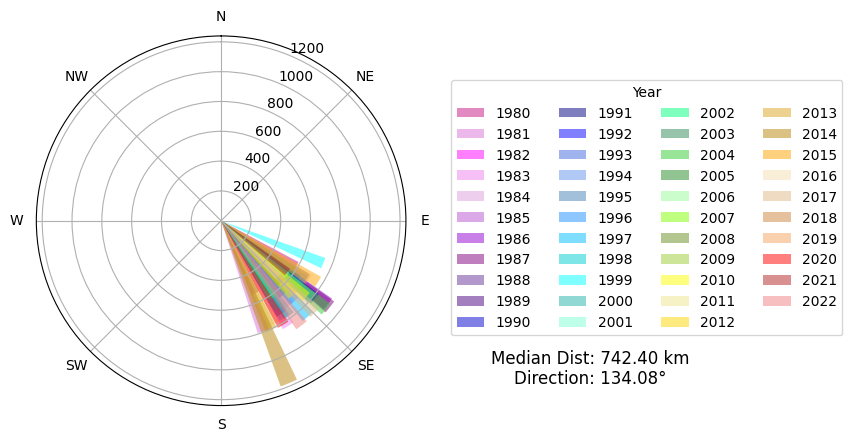

In [ ]:
# Run annual windrose plot
tor_file = '%s/1980-2022_assoc_tor_and_etcs.csv' % data_dir
full_len = 0
year = begin_year

median_df = pd.DataFrame(columns=['year', 'median_dist', 'median_dir'])
title = 'Annual Median Tornado Distribution Relative to ETC'
c = 0

# Store all median distances for overall median calculation
all_median_dists = []
all_median_dirs = []

while year <= end_year:
    # print(year)

    # All tornadoes
    if os.path.exists(tor_file):
        tor_df = pd.read_csv(tor_file, header=[0])
        # print(tor_df)
        tor_df = tor_df[tor_df['utcyr'].isin([year])]
        tor_df = tor_df.dropna(subset=['closest_etclon', 'closest_etclat'])
        median_df = torWindroseAnnual(tor_df, year, median_df)

        # Append each year's median distance and direction to the list for overall median calculation
        all_median_dists.append(median_df.loc[median_df['year'] == year, 'median_dist'].values[0])
        all_median_dirs.append(median_df.loc[median_df['year'] == year, 'median_dir'].values[0])

    year = year + 1
    c = c + 1

# Calculate the overall median distance across all years
print(all_median_dists)
print(all_median_dirs)
overall_median_dist = np.median(all_median_dists)
overall_median_dir = np.median(all_median_dirs)

# Plot windrose plot
ax = plt.subplot(111, polar=True)

# Iterate through each year
for i, year in enumerate(median_df['year']):
  color = color_list[i % len(color_list)]  # Cycle through colors if more years than colors
  ax.bar(np.radians(median_df.loc[i, 'median_dir']), median_df.loc[i, 'median_dist'],
         width=0.1, color=color, label=str(year), alpha=0.5)

# Plot the overall median as an 'X' marker
# ax.scatter(np.radians(median_df['median_dir'].iloc[0]), overall_median_dist, color='red', s=100, label='Overall Median Dist', marker='X')
# Add text with the overall median distance and direction
text = f'Median Dist: {overall_median_dist:.2f} km\nDirection: {overall_median_dir:.2f}°'
ax.text(1.5, 0.1, text, color='black', transform=ax.transAxes, fontsize=12, ha='center', va='center')

#ax.text(1.03, 0.98, my_text, transform=ax.transAxes, fontsize=12, verticalalignment='top', bbox=props)


ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
ax.set_xticks(np.arange(0, 2*np.pi, np.pi/4))
ax.set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])
plt.legend(ncol=4, title='Year', loc='upper right', bbox_to_anchor=(2.2, .9))

year_save_dir = '%s/annual' % plots_dir
if os.path.exists(year_save_dir):
    plt.savefig("%s/annual_windrose.png" % year_save_dir, bbox_inches='tight', dpi=300)
else:
    os.mkdir(year_save_dir)
    plt.savefig("%s/annual_windrose.png" % year_save_dir, bbox_inches='tight', dpi=300)
plt.show()

In [ ]:
def torGeoAnnual(req_data, year, col, size, bool, lw):
    if not req_data.empty:
        median_lon_tor = req_data['slon'].median()
        median_lat_tor = req_data['slat'].median()
        median_lon_ext = req_data['closest_etclon'].median()
        median_lat_ext = req_data['closest_etclat'].median()
        if bool:
            plt.plot([median_lon_tor, median_lon_ext], [median_lat_tor, median_lat_ext],
                     transform=ccrs.PlateCarree(), c=col, lw=0.75, zorder=1)
        ax.scatter(median_lon_tor, median_lat_tor, transform=ccrs.PlateCarree(),
                   c=col, marker="x", s=size, lw=lw, label=year, zorder=2)
        ax.scatter(median_lon_ext, median_lat_ext, transform=ccrs.PlateCarree(),
                   facecolors='none', edgecolors=col, s=size, lw=lw, label=year, zorder=2)

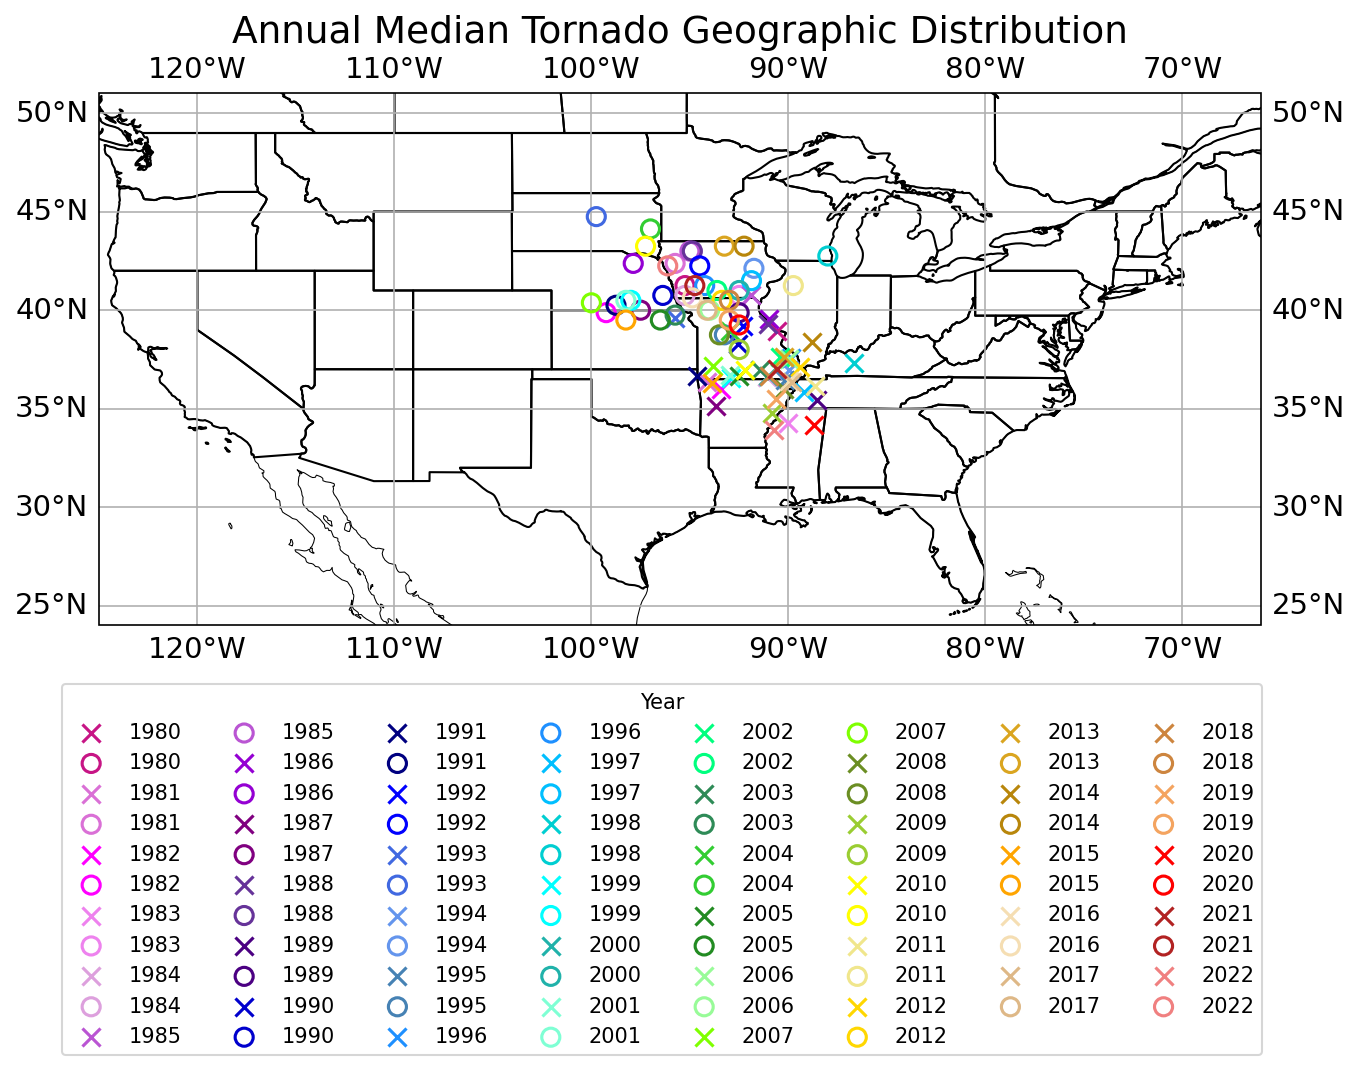

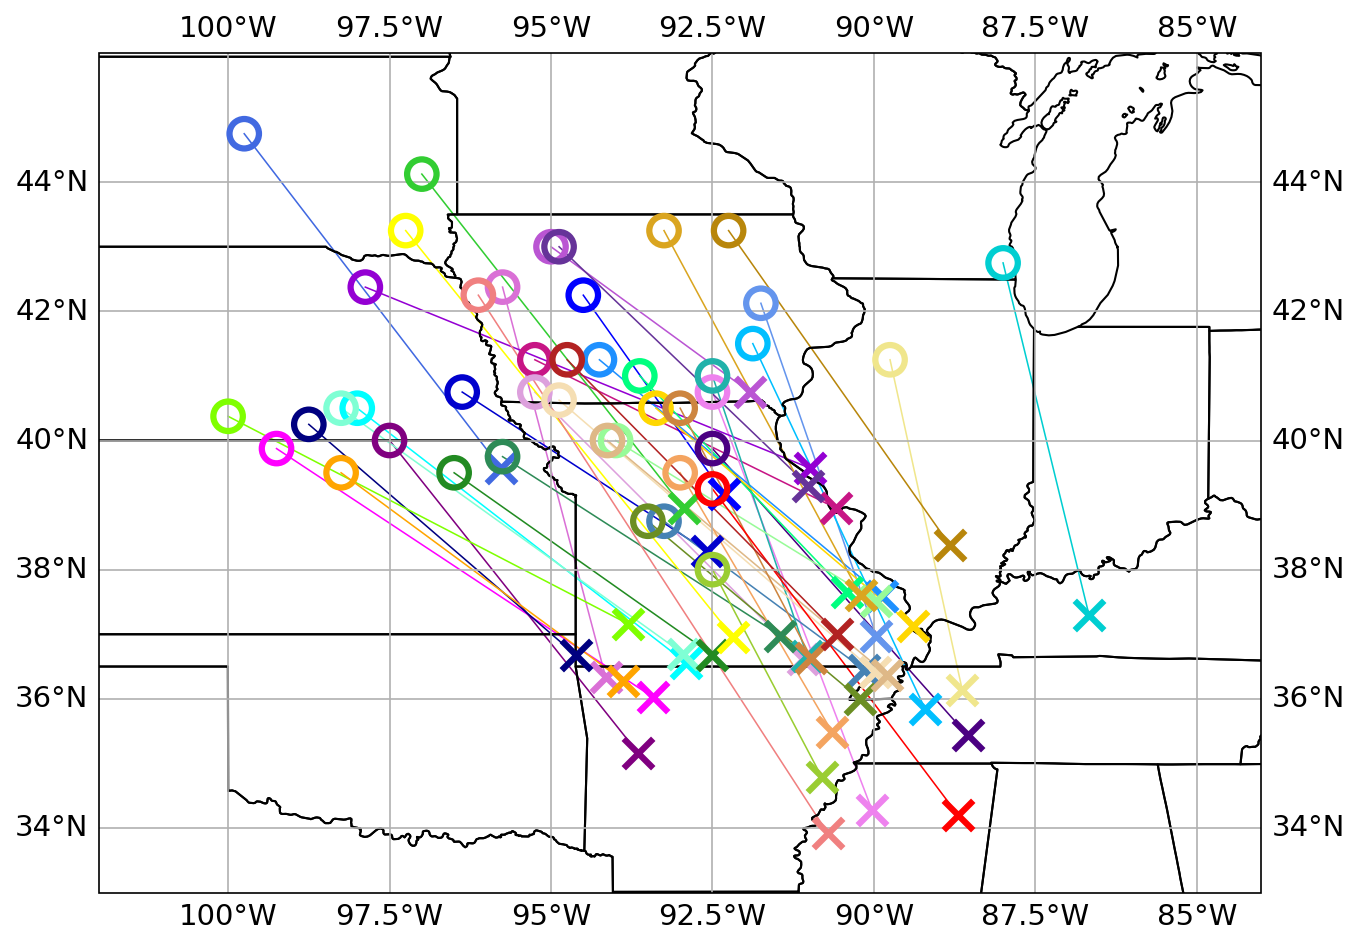

In [ ]:
# Run annual geo plots
tor_file = '%s/1980-2022_assoc_tor_and_etcs.csv' % data_dir
full_len = 0
plots = [["full", ([-125, -66]), ([24, 51]), 75, 1.5, False], ["mini", ([-102, -84]), ([33, 46]), 200, 3, True]]

for plot in plots:
    year = begin_year
    plottype = plot[0]
    xlim = plot[1]
    ylim = plot[2]
    size = plot[3]
    line_w = plot[4]
    bool_lines = plot[5]
    c = 0

    # Initialize figure, set size and resolution
    fig = plt.figure(figsize=(10, 8), dpi=150)
    fig.set_facecolor('white')

    # create axis using cartopy projections, add in coastlines & grid
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, color='black', zorder=2)
    ax.add_feature(cfeature.STATES, edgecolor='black')
    ax.grid(visible=True)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    # create gridlines and format labels
    gl = ax.gridlines(draw_labels=True, zorder=3)
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabels_top = gl.ylabels_right = False
    gl.xlines = gl.ylines = True
    gl.xlabel_style = {'size': 14}
    gl.ylabel_style = {'size': 14}

    while year <= end_year:
        # All tornadoes
        if os.path.exists(tor_file):
            tor_df = pd.read_csv(tor_file, header=[0])
            tor_df = tor_df[tor_df['utcyr'].isin([year])]
            median_df = torGeoAnnual(tor_df, year, color_list[c], size, bool_lines, line_w)

        year = year + 1
        c = c + 1

    if not bool_lines:
        plt.title('Annual Median Tornado Geographic Distribution', fontsize=18)
        plt.legend(ncol=8, title='Year', loc='upper right', bbox_to_anchor=(1.01, -0.09))

    year_save_dir = '%s/annual' % plots_dir
    if os.path.exists(year_save_dir):
        plt.savefig("%s/annual_geo_%s.png" % (year_save_dir, plottype), bbox_inches='tight', dpi=300)
    else:
        os.mkdir(year_save_dir)
        plt.savefig("%s/annual_geo_%s.png" % (year_save_dir, plottype), bbox_inches='tight', dpi=300)
    plt.show()

# Annual Linear Trends

In [ ]:
# Colors for each year 1980-2022
color_list = ['mediumvioletred', 'orchid', 'fuchsia', 'violet', 'plum',
              'mediumorchid', 'darkviolet', 'purple', 'rebeccapurple', 'indigo',
              'mediumblue', 'navy', 'blue', 'royalblue', 'cornflowerblue',
              'steelblue', 'dodgerblue', 'deepskyblue', 'darkturquoise', 'aqua',
              'lightseagreen', 'aquamarine', 'springgreen', 'seagreen', 'limegreen',
              'forestgreen', 'palegreen', 'chartreuse', 'olivedrab', 'yellowgreen',
              'yellow', 'khaki', 'gold', 'goldenrod', 'darkgoldenrod',
              'orange', 'wheat', 'burlywood', 'peru', 'sandybrown',
              'red', 'firebrick', 'lightcoral']
begin_year = 1980
end_year = 2022

Latitude Covariance: 1.074583333333333
Longitude Covariance: 3.2597327623200445


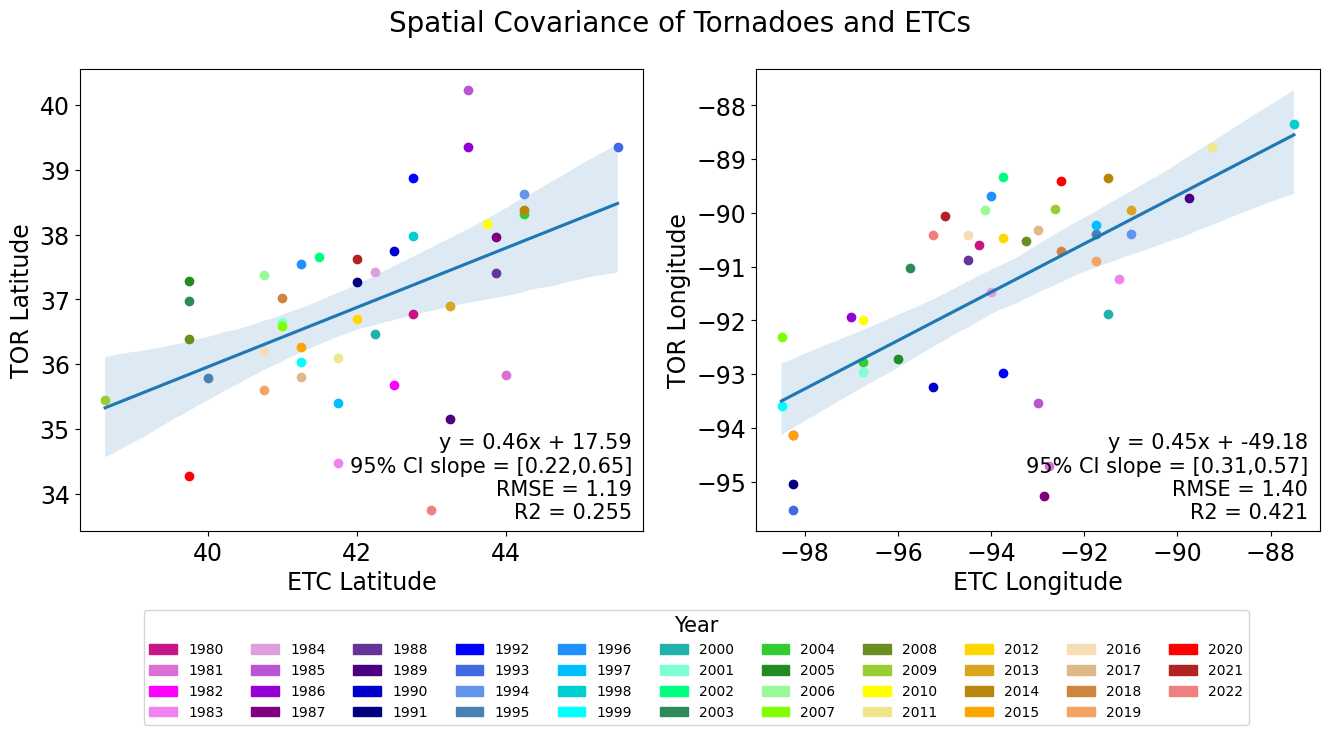

In [ ]:
# Interannual Spatial Covariance
tor_file = '%s/1980-2022_assoc_tor_and_etcs.csv' % data_dir
tor_file = '%s/1980-2022_add_non_tc_tor_and_etcs.csv' % data_dir
full_len = 0
year = begin_year
tor_latitudes = []
tor_longitudes = []
etc_latitudes = []
etc_longitudes = []
years_list = []
patch_handles = []
c = 0
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

while year <= end_year:
    if os.path.exists(tor_file):
        all_df = pd.read_csv(tor_file, header=[0])
        all_df = all_df[all_df['utcyr'].isin([year])]
        ax1.scatter(all_df['closest_etclat'].median(), all_df['slat'].median(), zorder=2, c=color_list[c])
        ax2.scatter(all_df['closest_etclon'].median(), all_df['slon'].median(), zorder=2, c=color_list[c])
        patch = mpatches.Patch(color=color_list[c], label=year)
        patch_handles.append(patch)
        tor_latitudes.append(all_df['slat'].median())
        tor_longitudes.append(all_df['slon'].median())
        etc_latitudes.append(all_df['closest_etclat'].median())
        etc_longitudes.append(all_df['closest_etclon'].median())
        years_list.append(year)

    year = year + 1
    c = c + 1

co_df = pd.DataFrame(columns=['tor_lat', 'tor_lon', 'etc_lat', 'etc_lon'])
co_df['tor_lat'] = tor_latitudes
co_df['tor_lon'] = tor_longitudes
co_df['etc_lat'] = etc_latitudes
co_df['etc_lon'] = etc_longitudes
lat_covariance = co_df[['etc_lat', 'tor_lat']].cov().iloc[0, 1]
lon_covariance = co_df[['etc_lon', 'tor_lon']].cov().iloc[0, 1]

print("Latitude Covariance:", lat_covariance)
print("Longitude Covariance:", lon_covariance)

# For latitude
x = co_df['etc_lat']
y = co_df['tor_lat']

X_lat = sm.add_constant(x)  # Add constant to predictor variable
model_lat = sm.OLS(y, X_lat).fit()
best_fit_values = model_lat.params
intercept = best_fit_values.const
slope = best_fit_values.etc_lat

X = sm.add_constant(x)
model = sm.OLS(y, X).fit()
y_pred = model.predict(X)
best_fit_values = model.params
rmse = np.sqrt(skmet.mean_squared_error(y, y_pred))
rsquared = model_lat.rsquared

boot_ci_temp = []
R = 2000
for i in range(R):
    # Create a new dataset resampled with replacement directly from dataset
    idx = np.random.choice(np.arange(len(x)), size=len(x))
    Xboot = x[idx]-np.mean(x[idx])
    yboot = y[idx]-np.mean(y[idx])

    # Re-fit the linear regression model and map back to beta (dont care about intercept)
    boot_model = sm.OLS(yboot, Xboot).fit()
    boot_ci_temp.append(boot_model.params)

# Extract CI on slopes no interecept
ci_slopelow, ci_slopehigh = np.percentile(boot_ci_temp, 2.5, axis=0), np.percentile(boot_ci_temp, 97.5, axis=0)

# Fit and plot the linear regression model with 95% confidence interval
model = sns.regplot(
  data=co_df,
  x="etc_lat",
  y="tor_lat",
  ci=95,
  ax=ax1,
  scatter=False,
  line_kws={'label': "y={0:.1f}x+{1:.1f}".format(slope, intercept)}
)

# Set the plot title and labels
ax1.text(0.98, 0.17, f'y = {slope:.2f}x + {intercept:.2f}', transform=ax1.transAxes, fontsize=15, verticalalignment='bottom', horizontalalignment='right')
ax1.text(0.98, 0.12, f'95% CI slope = [{ci_slopelow[0]:.2f},{ci_slopehigh[0]:.2f}]', transform=ax1.transAxes, fontsize=15, verticalalignment='bottom', horizontalalignment='right')
ax1.text(0.98, 0.07, f'RMSE = {rmse:.2f}', transform=ax1.transAxes, fontsize=15, verticalalignment='bottom', horizontalalignment='right')
ax1.text(0.98, 0.02, f'R2 = {rsquared:.3f}', transform=ax1.transAxes, fontsize=15, verticalalignment='bottom', horizontalalignment='right')

# For longitude
x = co_df['etc_lon']
y = co_df['tor_lon']

X_lat = sm.add_constant(x)  # Add constant to predictor variable
model_lat = sm.OLS(y, X_lat).fit()
best_fit_values = model_lat.params
intercept = best_fit_values.const
slope = best_fit_values.etc_lon

X = sm.add_constant(x)
model = sm.OLS(y, X).fit()
y_pred = model.predict(X)
best_fit_values = model.params
rmse = np.sqrt(skmet.mean_squared_error(y, y_pred))
rsquared = model_lat.rsquared

boot_ci_temp = []
R = 2000
for i in range(R):
    # Create a new dataset resampled with replacement directly from dataset
    idx = np.random.choice(np.arange(len(x)), size=len(x))
    Xboot = x[idx]-np.mean(x[idx])
    yboot = y[idx]-np.mean(y[idx])

    # Re-fit the linear regression model and map back to beta (dont care about intercept)
    boot_model = sm.OLS(yboot, Xboot).fit()
    boot_ci_temp.append(boot_model.params)

# Extract CI on slopes no interecept
ci_slopelow, ci_slopehigh = np.percentile(boot_ci_temp, 2.5, axis=0), np.percentile(boot_ci_temp, 97.5, axis=0)

# Fit and plot the linear regression model with 95% confidence interval
model = sns.regplot(
  data=co_df,
  x="etc_lon",
  y="tor_lon",
  ci=95,
  ax=ax2,
  scatter=False,
  line_kws={'label': "y={0:.1f}x+{1:.1f}".format(slope, intercept)}
)

# Set the plot title and labels
ax2.text(0.98, 0.17, f'y = {slope:.2f}x + {intercept:.2f}', transform=ax2.transAxes, fontsize=15, verticalalignment='bottom', horizontalalignment='right')
ax2.text(0.98, 0.12, f'95% CI slope = [{ci_slopelow[0]:.2f},{ci_slopehigh[0]:.2f}]', transform=ax2.transAxes, fontsize=15, verticalalignment='bottom', horizontalalignment='right')
ax2.text(0.98, 0.07, f'RMSE = {rmse:.2f}', transform=ax2.transAxes, fontsize=15, verticalalignment='bottom', horizontalalignment='right')
ax2.text(0.98, 0.02, f'R2 = {rsquared:.3f}', transform=ax2.transAxes, fontsize=15, verticalalignment='bottom', horizontalalignment='right')

plt.suptitle('Spatial Covariance of Tornadoes and ETCs', fontsize=20)

ax1.set_xlabel('ETC Latitude', fontsize=17)
ax1.set_ylabel('TOR Latitude', fontsize=17)
ax1.xaxis.set_tick_params(labelsize=17)
ax1.yaxis.set_tick_params(labelsize=17)

ax2.set_xlabel('ETC Longitude', fontsize=17)
ax2.set_ylabel('TOR Longitude', fontsize=17)
ax2.xaxis.set_tick_params(labelsize=17)
ax2.yaxis.set_tick_params(labelsize=17)

fig.legend(handles=patch_handles, ncol=11, title='Year', title_fontsize=15, bbox_to_anchor=(0.86, -0.01))

year_save_dir = '%s/annual' % plots_dir
if os.path.exists(year_save_dir):
    plt.savefig("%s/annual_covariance.png" % year_save_dir, bbox_inches='tight', dpi=300)
else:
    os.mkdir(year_save_dir)
    plt.savefig("%s/annual_covariance.png" % year_save_dir, bbox_inches='tight', dpi=300)

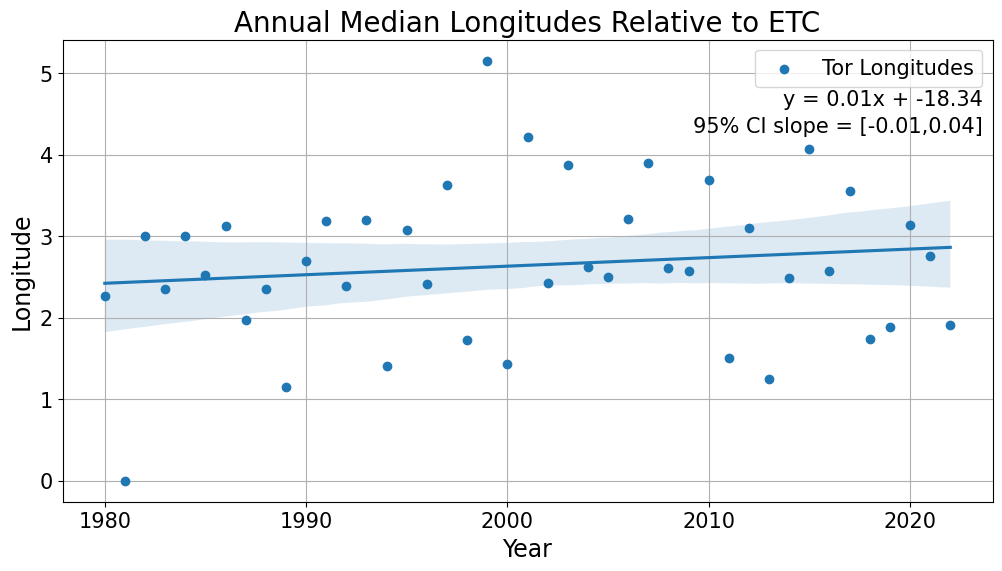

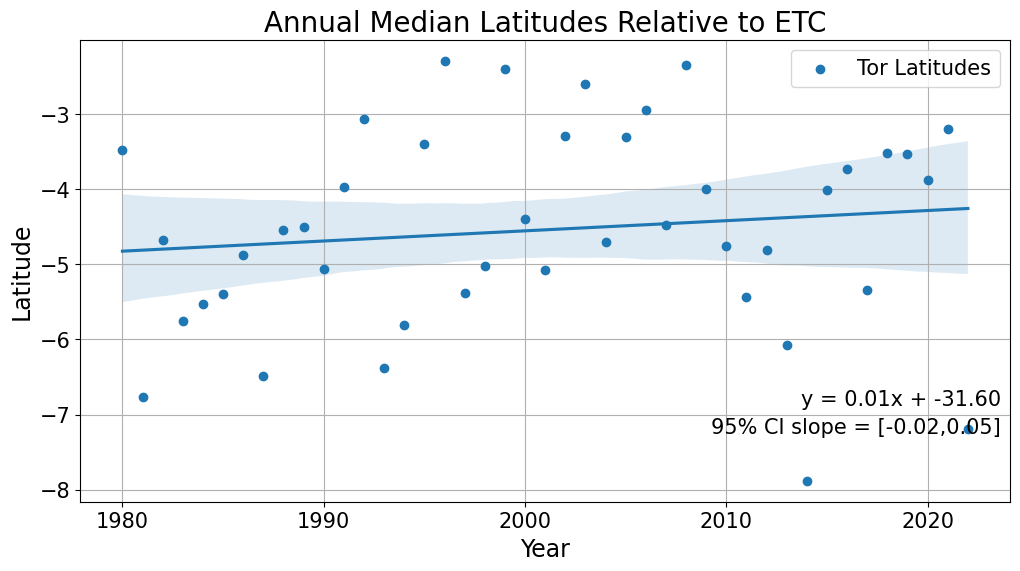

In [ ]:
# Annual trend of relative median longitudes and latitudes
tor_file = '%s/1980-2022_assoc_tor_and_etcs.csv' % data_dir
tor_file = '%s/1980-2022_add_non_tc_tor_and_etcs.csv' % data_dir
full_len = 0
year = begin_year
tor_longitudes = []
tor_latitudes = []
years_list = []
c = 0

while year <= end_year:
    # Set coordinates relative to centralized ETC
    new_coord = pd.DataFrame()

    if os.path.exists(tor_file):
        tor_df = pd.read_csv(tor_file, header=[0])
        tor_df = tor_df[tor_df['utcyr'].isin([year])]

        for index, row in tor_df.iterrows():
            tor_lon = tor_df['slon'][index] - tor_df['closest_etclon'][index]
            tor_lat = tor_df['slat'][index] - tor_df['closest_etclat'][index]
            df = pd.DataFrame({"slat": [tor_lat], "slon": [tor_lon]})
            # new_coord = new_coord.append(df, ignore_index=True)
            new_coord = pd.concat([new_coord, df], ignore_index=True)

        tor_longitudes.append(new_coord['slon'].median())
        tor_latitudes.append(new_coord['slat'].median())
        years_list.append(year)

    year = year + 1
    c = c + 1

# Convert years from strings to integers
years_list = np.array(list(map(int, years_list)))

co_df = pd.DataFrame()
co_df['years'] = years_list
co_df['tor_lon'] = tor_longitudes
co_df['tor_lat'] = tor_latitudes

# Longitude
fig, ax = plt.subplots(figsize=(12, 6))

# Create scatter plot
plt.scatter(years_list, tor_longitudes, label='Tor Longitudes', zorder=2)

x = co_df['years']
y = co_df['tor_lon']

X_lat = sm.add_constant(x)  # Add constant to predictor variable
model_lat = sm.OLS(y, X_lat).fit()
best_fit_values = model_lat.params
intercept = best_fit_values.const
slope = best_fit_values.years

X = sm.add_constant(x)
model = sm.OLS(y, X).fit()
y_pred = model.predict(X)
best_fit_values = model.params
rmse = np.sqrt(skmet.mean_squared_error(y, y_pred))
rsquared = model_lat.rsquared

boot_ci_temp = []
R = 2000
for i in range(R):
    # Create a new dataset resampled with replacement directly from dataset
    idx = np.random.choice(np.arange(len(x)), size=len(x))
    Xboot = x[idx]-np.mean(x[idx])
    yboot = y[idx]-np.mean(y[idx])

    # Re-fit the linear regression model and map back to beta (dont care about intercept)
    boot_model = sm.OLS(yboot, Xboot).fit()
    boot_ci_temp.append(boot_model.params)

# extract CI on slopes no interecept
ci_slopelow, ci_slopehigh = np.percentile(boot_ci_temp, 2.5, axis=0), np.percentile(boot_ci_temp, 97.5, axis=0)

# Fit and plot the linear regression model with 95% confidence interval
model = sns.regplot(
  data=co_df,
  x="years",
  y="tor_lon",
  ci=95,
  ax=ax,
  scatter=False,
  line_kws={'label': "y={0:.1f}x+{1:.1f}".format(slope, intercept)}
)

# Set the plot title and labels
ax.text(0.99, 0.85, f'y = {slope:.2f}x + {intercept:.2f}', transform=ax.transAxes, fontsize=15, verticalalignment='bottom', horizontalalignment='right')
ax.text(0.99, 0.79, f'95% CI slope = [{ci_slopelow[0]:.2f},{ci_slopehigh[0]:.2f}]', transform=ax.transAxes, fontsize=15, verticalalignment='bottom', horizontalalignment='right')
# ax.text(0.99, 0.76, f'RMSE = {rmse:.2f}', transform=ax.transAxes, fontsize=14, verticalalignment='bottom', horizontalalignment='right')
# ax.text(0.99, 0.72, f'R2 = {rsquared:.3f}', transform=ax.transAxes, fontsize=14, verticalalignment='bottom', horizontalalignment='right')

# Add labels and legend
plt.xlabel('Year', fontsize=17)
plt.ylabel('Longitude', fontsize=17)
plt.title('Annual Median Longitudes Relative to ETC', fontsize=20)
plt.tick_params(labelsize=15)
plt.legend(fontsize=15)
plt.grid(True, zorder=0)

year_save_dir = '%s/annual' % plots_dir
if os.path.exists(year_save_dir):
    plt.savefig("%s/annual_relative_lon.png" % year_save_dir, bbox_inches='tight', dpi=300)
else:
    os.mkdir(year_save_dir)
    plt.savefig("%s/annual_relative_lon.png" % year_save_dir, bbox_inches='tight', dpi=300)
plt.show()

# Latitude
fig, ax = plt.subplots(figsize=(12, 6))

# Create scatter plot
plt.scatter(years_list, tor_latitudes, label='Tor Latitudes', zorder=2)

x = co_df['years']
y = co_df['tor_lat']

X_lat = sm.add_constant(x)  # Add constant to predictor variable
model_lat = sm.OLS(y, X_lat).fit()
best_fit_values = model_lat.params
intercept = best_fit_values.const
slope = best_fit_values.years

X = sm.add_constant(x)
model = sm.OLS(y, X).fit()
y_pred = model.predict(X)
best_fit_values = model.params
rmse = np.sqrt(skmet.mean_squared_error(y, y_pred))
rsquared = model_lat.rsquared

boot_ci_temp = []
R = 2000
for i in range(R):
    # Create a new dataset resampled with replacement directly from dataset
    idx = np.random.choice(np.arange(len(x)), size=len(x))
    Xboot = x[idx]-np.mean(x[idx])
    yboot = y[idx]-np.mean(y[idx])

    # Re-fit the linear regression model and map back to beta (dont care about intercept)
    boot_model = sm.OLS(yboot, Xboot).fit()
    boot_ci_temp.append(boot_model.params)

# extract CI on slopes no interecept
ci_slopelow, ci_slopehigh = np.percentile(boot_ci_temp, 2.5, axis=0), np.percentile(boot_ci_temp, 97.5, axis=0)

# Fit and plot the linear regression model with 95% confidence interval
model = sns.regplot(
  data=co_df,
  x="years",
  y="tor_lat",
  ci=95,
  ax=ax,
  scatter=False,
  line_kws={'label': "y={0:.1f}x+{1:.1f}".format(slope, intercept)}
)

# Set the plot title and labels
ax.text(0.99, 0.20, f'y = {slope:.2f}x + {intercept:.2f}', transform=ax.transAxes, fontsize=15, verticalalignment='bottom', horizontalalignment='right')
ax.text(0.99, 0.14, f'95% CI slope = [{ci_slopelow[0]:.2f},{ci_slopehigh[0]:.2f}]', transform=ax.transAxes, fontsize=15, verticalalignment='bottom', horizontalalignment='right')
# ax.text(0.99, 0.08, f'RMSE = {rmse:.2f}', transform=ax.transAxes, fontsize=14, verticalalignment='bottom', horizontalalignment='right')
# ax.text(0.99, 0.04, f'R2 = {rsquared:.3f}', transform=ax.transAxes, fontsize=14, verticalalignment='bottom', horizontalalignment='right')

# Add labels and legend
plt.xlabel('Year', fontsize=17)
plt.ylabel('Latitude', fontsize=17)
plt.title('Annual Median Latitudes Relative to ETC', fontsize=20)
plt.tick_params(labelsize=15)
plt.legend(fontsize=15)
plt.grid(True, zorder=0)

year_save_dir = '%s/annual' % plots_dir
if os.path.exists(year_save_dir):
    plt.savefig("%s/annual_relative_lat.png" % year_save_dir, bbox_inches='tight', dpi=300)
else:
    os.mkdir(year_save_dir)
    plt.savefig("%s/annual_relative_lat.png" % year_save_dir, bbox_inches='tight', dpi=300)
plt.show()

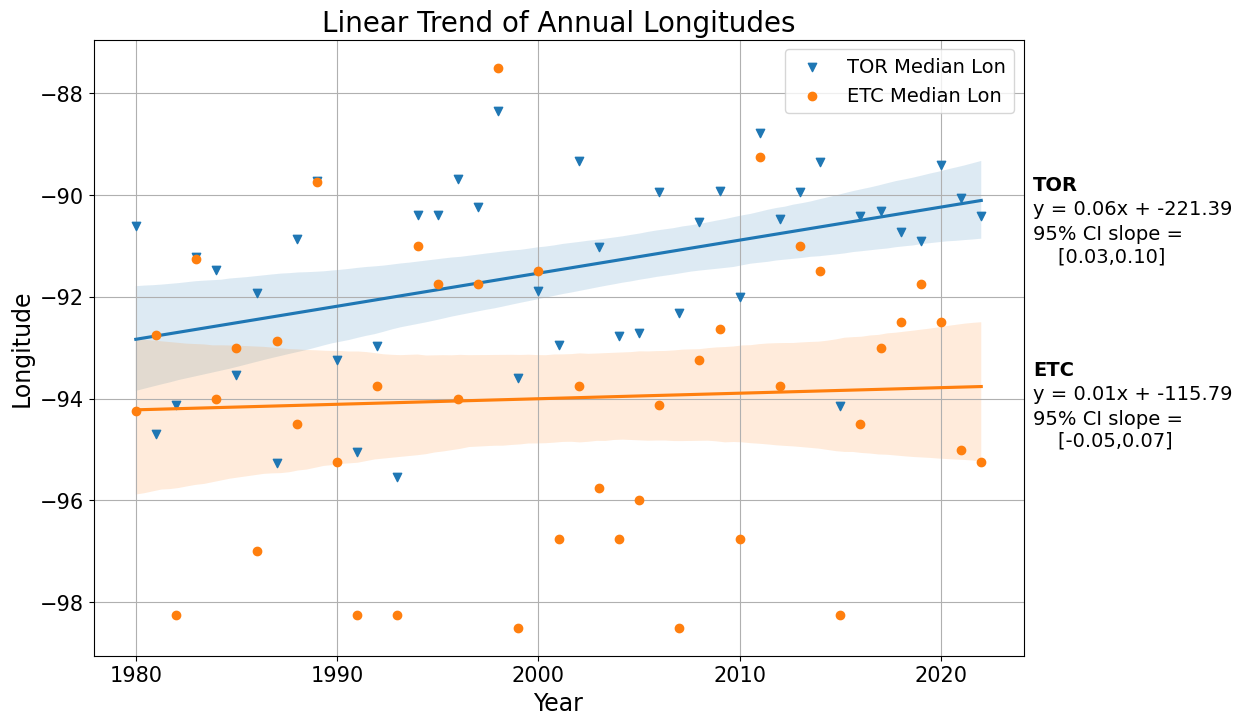

In [ ]:
# Linear trend of annual longitudes
tor_file = '%s/1980-2022_assoc_tor_and_etcs.csv' % data_dir
tor_file = '%s/1980-2022_add_non_tc_tor_and_etcs.csv' % data_dir
full_len = 0
year = begin_year
tor_longitudes = []
etc_longitudes = []
years_list = []
co_df = pd.DataFrame()
c = 0

while year <= end_year:
    if os.path.exists(tor_file):
        tor_df = pd.read_csv(tor_file, header=[0])
        tor_df = tor_df[tor_df['utcyr'].isin([year])]
        tor_longitudes.append(tor_df['slon'].median())
        etc_longitudes.append(tor_df['closest_etclon'].median())
        years_list.append(year)

    year = year + 1
    c = c + 1

# Convert years from strings to integers
years_list = np.array(list(map(int, years_list)))

co_df['etc_lon'] = etc_longitudes
co_df['tor_lon'] = tor_longitudes
co_df['years'] = years_list

fig, ax = plt.subplots(figsize=(12, 8))

# Create scatter plot
plt.scatter(years_list, tor_longitudes, label='TOR Median Lon', zorder=2, marker='v')
# # Fit a linear trend line
# z = np.polyfit(years_list, tor_longitudes, 1)
# p = np.poly1d(z)
# plt.plot(years_list, p(years_list), "b--", label='TOR Median Lon Linear Fit')

x = co_df['years']
y = co_df['tor_lon']

X_lat = sm.add_constant(x)  # Add constant to predictor variable
model_lat = sm.OLS(y, X_lat).fit()
best_fit_values = model_lat.params
intercept = best_fit_values.const
slope = best_fit_values.years

X = sm.add_constant(x)
model = sm.OLS(y, X).fit()
y_pred = model.predict(X)
best_fit_values = model.params
rmse = np.sqrt(skmet.mean_squared_error(y, y_pred))
rsquared = model_lat.rsquared

boot_ci_temp = []
R = 2000
for i in range(R):
    # Create a new dataset resampled with replacement directly from dataset
    idx = np.random.choice(np.arange(len(x)), size=len(x))
    Xboot = x[idx]-np.mean(x[idx])
    yboot = y[idx]-np.mean(y[idx])

    # Re-fit the linear regression model and map back to beta (dont care about intercept)
    boot_model = sm.OLS(yboot, Xboot).fit()
    boot_ci_temp.append(boot_model.params)

# extract CI on slopes no interecept
ci_slopelow, ci_slopehigh = np.percentile(boot_ci_temp, 2.5, axis=0), np.percentile(boot_ci_temp, 97.5, axis=0)

# Fit and plot the linear regression model with 95% confidence interval
model = sns.regplot(
  data=co_df,
  x="years",
  y="tor_lon",
  ci=95,
  ax=ax,
  scatter=False,
  line_kws={'label': "y={0:.1f}x+{1:.1f}".format(slope, intercept)}
)

# Set the plot title and labels
ax.text(1.01, 0.78, 'TOR', transform=ax.transAxes, fontsize=14, verticalalignment='top', horizontalalignment='left', fontweight='bold')
ax.text(1.01, 0.74, f'y = {slope:.2f}x + {intercept:.2f}', transform=ax.transAxes, fontsize=14, verticalalignment='top', horizontalalignment='left')
ax.text(1.01, 0.70, f'95% CI slope =\n    [{ci_slopelow[0]:.2f},{ci_slopehigh[0]:.2f}]', transform=ax.transAxes, fontsize=14, verticalalignment='top', horizontalalignment='left')
#ax.text(1.02, 0.61, f'RMSE = {rmse:.2f}', transform=ax.transAxes, fontsize=14, verticalalignment='top', horizontalalignment='left')
#ax.text(1.02, 0.57, f'R2 = {rsquared:.3f}', transform=ax.transAxes, fontsize=14, verticalalignment='top', horizontalalignment='left')

# Create scatter plot
plt.scatter(years_list, etc_longitudes, label='ETC Median Lon', zorder=2)
# # Fit a linear trend line
# z = np.polyfit(years_list, etc_longitudes, 1)
# p = np.poly1d(z)
# plt.plot(years_list, p(years_list), "r--", label='ETC Median Lon Linear Fit')

x = co_df['years']
y = co_df['etc_lon']

X_lat = sm.add_constant(x)  # Add constant to predictor variable
model_lat = sm.OLS(y, X_lat).fit()
best_fit_values = model_lat.params
intercept = best_fit_values.const
slope = best_fit_values.years

X = sm.add_constant(x)
model = sm.OLS(y, X).fit()
y_pred = model.predict(X)
best_fit_values = model.params
rmse = np.sqrt(skmet.mean_squared_error(y, y_pred))
rsquared = model_lat.rsquared

boot_ci_temp = []
R = 2000
for i in range(R):
    # Create a new dataset resampled with replacement directly from dataset
    idx = np.random.choice(np.arange(len(x)), size=len(x))
    Xboot = x[idx]-np.mean(x[idx])
    yboot = y[idx]-np.mean(y[idx])

    # Re-fit the linear regression model and map back to beta (dont care about intercept)
    boot_model = sm.OLS(yboot, Xboot).fit()
    boot_ci_temp.append(boot_model.params)

# extract CI on slopes no interecept
ci_slopelow, ci_slopehigh = np.percentile(boot_ci_temp, 2.5, axis=0), np.percentile(boot_ci_temp, 97.5, axis=0)

# Fit and plot the linear regression model with 95% confidence interval
model = sns.regplot(
  data=co_df,
  x="years",
  y="etc_lon",
  ci=95,
  ax=ax,
  scatter=False,
  line_kws={'label': "y={0:.1f}x+{1:.1f}".format(slope, intercept)}
)

# Set the plot title and labels
ax.text(1.01, 0.48, 'ETC', transform=ax.transAxes, fontsize=14, verticalalignment='top', horizontalalignment='left', fontweight='bold')
ax.text(1.01, 0.44, f'y = {slope:.2f}x + {intercept:.2f}', transform=ax.transAxes, fontsize=14, verticalalignment='top', horizontalalignment='left')
ax.text(1.01, 0.40, f'95% CI slope =\n    [{ci_slopelow[0]:.2f},{ci_slopehigh[0]:.2f}]', transform=ax.transAxes, fontsize=14, verticalalignment='top', horizontalalignment='left')
#ax.text(1.02, 0.31, f'RMSE = {rmse:.2f}', transform=ax.transAxes, fontsize=14, verticalalignment='top', horizontalalignment='left')
#ax.text(1.02, 0.27, f'R2 = {rsquared:.3f}', transform=ax.transAxes, fontsize=14, verticalalignment='top', horizontalalignment='left')

# Add labels and legend
plt.xlabel('Year', fontsize=17)
plt.ylabel('Longitude', fontsize=17)
plt.title('Linear Trend of Annual Longitudes', fontsize=20)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.legend(fontsize=14)
plt.grid(True, zorder=0)

year_save_dir = '%s/annual' % plots_dir
if os.path.exists(year_save_dir):
    plt.savefig("%s/annual_median_lonfit.png" % year_save_dir, bbox_inches='tight', dpi=300)
else:
    os.mkdir(year_save_dir)
    plt.savefig("%s/annual_median_lonfit.png" % year_save_dir, bbox_inches='tight', dpi=300)
plt.show()

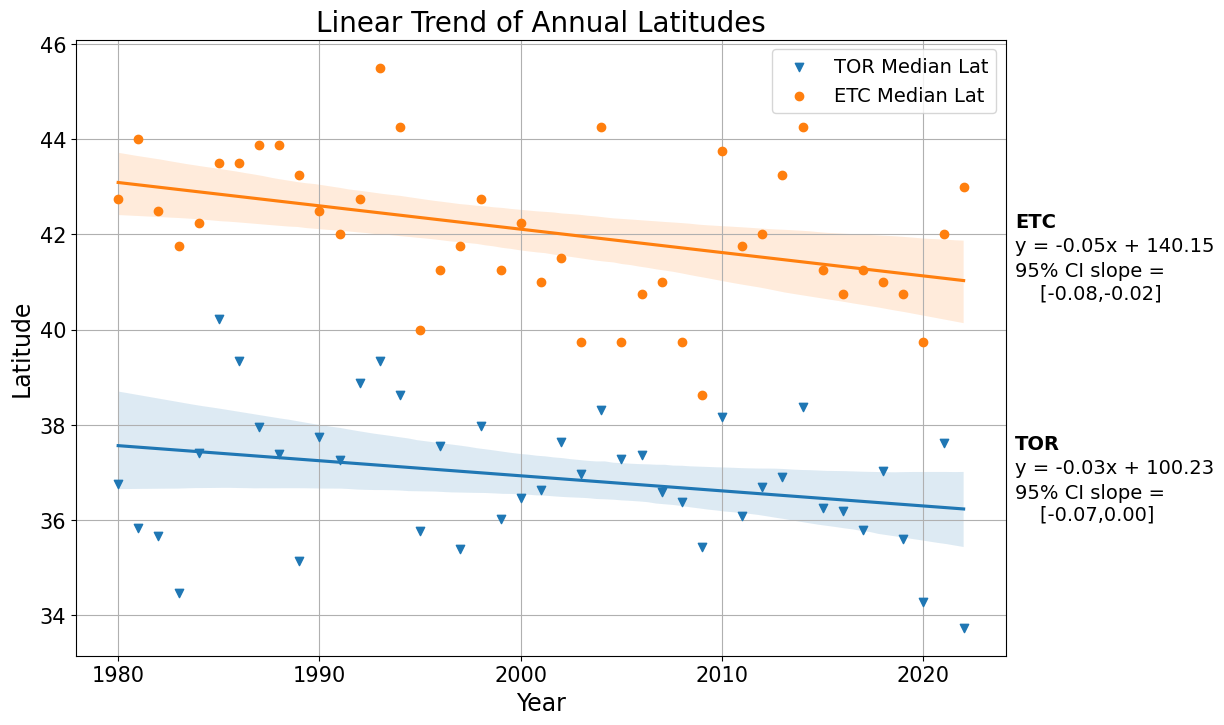

In [ ]:
# Linear trend of annual latitudes
tor_file = '%s/1980-2022_assoc_tor_and_etcs.csv' % data_dir
tor_file = '%s/1980-2022_add_non_tc_tor_and_etcs.csv' % data_dir
full_len = 0
year = begin_year
tor_latitudes = []
etc_latitudes = []
years_list = []
c = 0

while year <= end_year:
    if os.path.exists(tor_file):
        tor_df = pd.read_csv(tor_file, header=[0])
        tor_df = tor_df[tor_df['utcyr'].isin([year])]
        tor_latitudes.append(tor_df['slat'].median())
        etc_latitudes.append(tor_df['closest_etclat'].median())
        years_list.append(year)

    year = year + 1
    c = c + 1

# Convert years from strings to integers
years_list = np.array(list(map(int, years_list)))

co_df = pd.DataFrame()
co_df['etc_lat'] = etc_latitudes
co_df['tor_lat'] = tor_latitudes
co_df['years'] = years_list

fig, ax = plt.subplots(figsize=(12, 8))

# Create scatter plot
plt.scatter(years_list, tor_latitudes, label='TOR Median Lat', zorder=2, marker='v')
# # Fit a linear trend line
# z = np.polyfit(years_list, tor_latitudes, 1)
# p = np.poly1d(z)
# plt.plot(years_list, p(years_list), "b--", label='TOR Median Lat Linear Fit')

x = co_df['years']
y = co_df['tor_lat']

X_lat = sm.add_constant(x)  # Add constant to predictor variable
model_lat = sm.OLS(y, X_lat).fit()
best_fit_values = model_lat.params
intercept = best_fit_values.const
slope = best_fit_values.years

X = sm.add_constant(x)
model = sm.OLS(y, X).fit()
y_pred = model.predict(X)
best_fit_values = model.params
rmse = np.sqrt(skmet.mean_squared_error(y, y_pred))
rsquared = model_lat.rsquared

boot_ci_temp = []
R = 2000
for i in range(R):
    # Create a new dataset resampled with replacement directly from dataset
    idx = np.random.choice(np.arange(len(x)), size=len(x))
    Xboot = x[idx]-np.mean(x[idx])
    yboot = y[idx]-np.mean(y[idx])

    # Re-fit the linear regression model and map back to beta (dont care about intercept)
    boot_model = sm.OLS(yboot, Xboot).fit()
    boot_ci_temp.append(boot_model.params)

# Extract CI on slopes no interecept
ci_slopelow, ci_slopehigh = np.percentile(boot_ci_temp, 2.5, axis=0), np.percentile(boot_ci_temp, 97.5, axis=0)

# Fit and plot the linear regression model with 95% confidence interval
model = sns.regplot(
  data=co_df,
  x="years",
  y="tor_lat",
  ci=95,
  ax=ax,
  scatter=False,
  line_kws={'label': "y={0:.1f}x+{1:.1f}".format(slope, intercept)}
)

# Set the plot title and labels
ax.text(1.01, 0.36, 'TOR', transform=ax.transAxes, fontsize=14, verticalalignment='top', horizontalalignment='left', fontweight='bold')
ax.text(1.01, 0.32, f'y = {slope:.2f}x + {intercept:.2f}', transform=ax.transAxes, fontsize=14, verticalalignment='top', horizontalalignment='left')
ax.text(1.01, 0.28, f'95% CI slope =\n    [{ci_slopelow[0]:.2f},{ci_slopehigh[0]:.2f}]', transform=ax.transAxes, fontsize=14, verticalalignment='top', horizontalalignment='left')
#ax.text(1.02, 0.19, f'RMSE = {rmse:.2f}', transform=ax.transAxes, fontsize=14, verticalalignment='top', horizontalalignment='left')
#ax.text(1.02, 0.15, f'R2 = {rsquared:.3f}', transform=ax.transAxes, fontsize=14, verticalalignment='top', horizontalalignment='left')

# Create scatter plot
plt.scatter(years_list, etc_latitudes, label='ETC Median Lat', zorder=2)
# # Fit a linear trend line
# z = np.polyfit(years_list, etc_latitudes, 1)
# p = np.poly1d(z)
# plt.plot(years_list, p(years_list), "r--", label='ETC Median Lat Linear Fit')

x = co_df['years']
y = co_df['etc_lat']

X_lat = sm.add_constant(x)  # Add constant to predictor variable
model_lat = sm.OLS(y, X_lat).fit()
best_fit_values = model_lat.params
intercept = best_fit_values.const
slope = best_fit_values.years

X = sm.add_constant(x)
model = sm.OLS(y, X).fit()
y_pred = model.predict(X)
best_fit_values = model.params
rmse = np.sqrt(skmet.mean_squared_error(y, y_pred))
rsquared = model_lat.rsquared

boot_ci_temp = []
R = 2000
for i in range(R):
    # Create a new dataset resampled with replacement directly from dataset
    idx = np.random.choice(np.arange(len(x)), size=len(x))
    Xboot = x[idx]-np.mean(x[idx])
    yboot = y[idx]-np.mean(y[idx])

    # Re-fit the linear regression model and map back to beta (dont care about intercept)
    boot_model = sm.OLS(yboot, Xboot).fit()
    boot_ci_temp.append(boot_model.params)

# Extract CI on slopes no interecept
ci_slopelow, ci_slopehigh = np.percentile(boot_ci_temp, 2.5, axis=0), np.percentile(boot_ci_temp, 97.5, axis=0)

# Fit and plot the linear regression model with 95% confidence interval
model = sns.regplot(
  data=co_df,
  x="years",
  y="etc_lat",
  ci=95,
  ax=ax,
  scatter=False,
  line_kws={'label': "y={0:.1f}x+{1:.1f}".format(slope, intercept)}
)

# Set the plot title and labels
ax.text(1.01, 0.72, 'ETC', transform=ax.transAxes, fontsize=14, verticalalignment='top', horizontalalignment='left', fontweight='bold')
ax.text(1.01, 0.68, f'y = {slope:.2f}x + {intercept:.2f}', transform=ax.transAxes, fontsize=14, verticalalignment='top', horizontalalignment='left')
ax.text(1.01, 0.64, f'95% CI slope =\n    [{ci_slopelow[0]:.2f},{ci_slopehigh[0]:.2f}]', transform=ax.transAxes, fontsize=14, verticalalignment='top', horizontalalignment='left')
#ax.text(1.02, 0.55, f'RMSE = {rmse:.2f}', transform=ax.transAxes, fontsize=14, verticalalignment='top', horizontalalignment='left')
#ax.text(1.02, 0.51, f'R2 = {rsquared:.3f}', transform=ax.transAxes, fontsize=14, verticalalignment='top', horizontalalignment='left')

# Add labels and legend
plt.xlabel('Year', fontsize=17)
plt.ylabel('Latitude', fontsize=17)
plt.title('Linear Trend of Annual Latitudes', fontsize=20)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.legend(fontsize=14)
plt.grid(True, zorder=0)

# year_save_dir = '%s/annual' % plots_dir
# if os.path.exists(year_save_dir):
#     plt.savefig("%s/annual_median_latfit.png" % year_save_dir, bbox_inches='tight', dpi=300)
# else:
#     os.mkdir(year_save_dir)
#     plt.savefig("%s/annual_median_latfit.png" % year_save_dir, bbox_inches='tight', dpi=300)
plt.show()

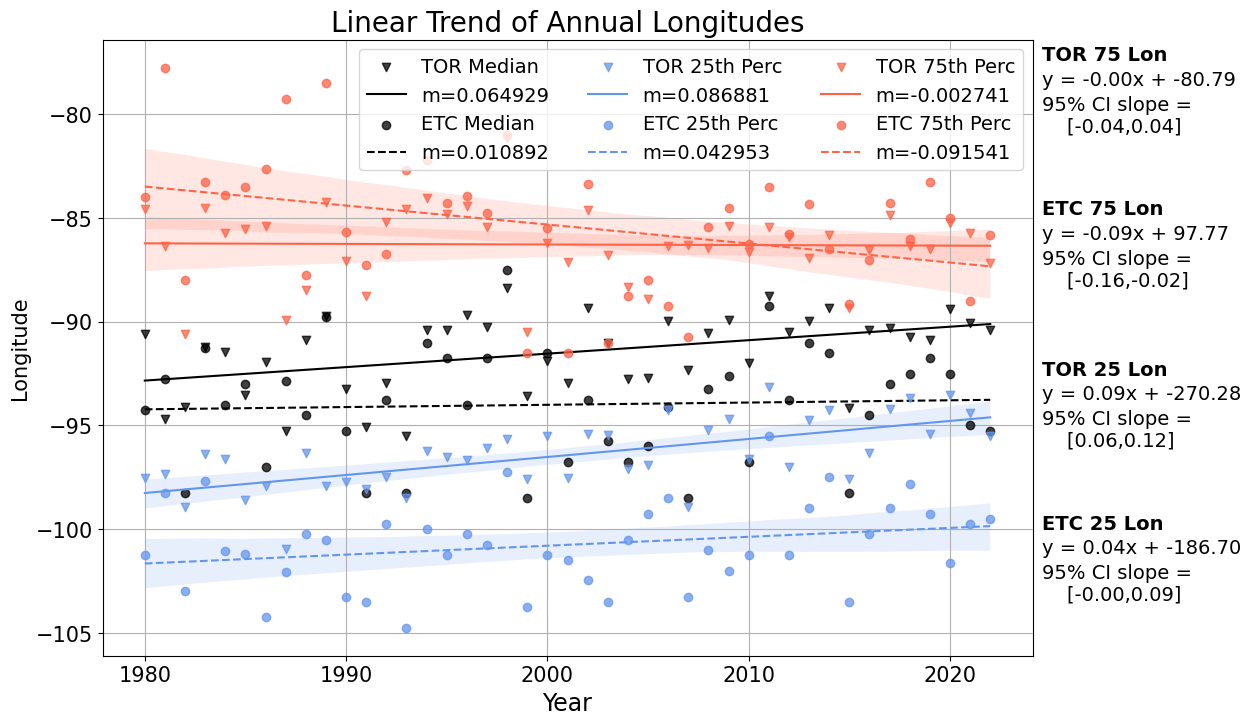

In [ ]:
# Linear trend of annual longitudes
tor_file = '%s/1980-2022_assoc_tor_and_etcs.csv' % data_dir
tor_file = '%s/1980-2022_add_non_tc_tor_and_etcs.csv' % data_dir
full_len = 0
year = begin_year
tor_longitudes = []
etc_longitudes = []
tor_25 = []
etc_25 = []
tor_75 = []
etc_75 = []
years_list = []
c = 0

while year <= end_year:
    if os.path.exists(tor_file):
        tor_df = pd.read_csv(tor_file, header=[0])
        tor_df = tor_df[tor_df['utcyr'].isin([year])]
        tor_longitudes.append(tor_df['slon'].median())
        etc_longitudes.append(tor_df['closest_etclon'].median())
        tor_25.append(tor_df['slon'].quantile(0.25))
        etc_25.append(tor_df['closest_etclon'].quantile(0.25))
        tor_75.append(tor_df['slon'].quantile(0.75))
        etc_75.append(tor_df['closest_etclon'].quantile(0.75))
        years_list.append(year)

    year = year + 1
    c = c + 1

# Convert years from strings to integers
years_list = np.array(list(map(int, years_list)))

co_df = pd.DataFrame()
co_df['tor_lon'] = tor_longitudes
co_df['etc_lon'] = etc_longitudes
co_df['tor_25_lon'] = tor_25
co_df['etc_25_lon'] = etc_25
co_df['tor_75_lon'] = tor_75
co_df['etc_75_lon'] = etc_75
co_df['years'] = years_list

fig, ax = plt.subplots(figsize=(12, 8))

# Create scatter plot
plt.scatter(years_list, tor_longitudes, label='TOR Median', zorder=2, marker='v', c='black', alpha=0.75)
# Fit a linear trend line
z = np.polyfit(years_list, tor_longitudes, 1)
p = np.poly1d(z)
plt.plot(years_list, p(years_list), "-", c='black', label='m=%s' % format(z[0], '.6f'))

# Create scatter plot
plt.scatter(years_list, etc_longitudes, label='ETC Median', zorder=2, c='black', alpha=0.75)
# Fit a linear trend line
z = np.polyfit(years_list, etc_longitudes, 1)
p = np.poly1d(z)
plt.plot(years_list, p(years_list), "--", c='black', label='m=%s' % format(z[0], '.6f'))

# Create scatter plot
plt.scatter(years_list, tor_25, label='TOR 25th Perc', zorder=2, marker='v', c='cornflowerblue', alpha=0.75)
# Fit a linear trend line
z = np.polyfit(years_list, tor_25, 1)
p = np.poly1d(z)
plt.plot(years_list, p(years_list), "-",  c='cornflowerblue', label='m=%s' % format(z[0], '.6f'))

x = co_df['years']
y = co_df['tor_25_lon']

X_lat = sm.add_constant(x)  # Add constant to predictor variable
model_lat = sm.OLS(y, X_lat).fit()
best_fit_values = model_lat.params
intercept = best_fit_values.const
slope = best_fit_values.years

X = sm.add_constant(x)
model = sm.OLS(y, X).fit()
y_pred = model.predict(X)
best_fit_values = model.params
rmse = np.sqrt(skmet.mean_squared_error(y, y_pred))
rsquared = model_lat.rsquared

boot_ci_temp = []
R = 2000
for i in range(R):
    # Create a new dataset resampled with replacement directly from dataset
    idx = np.random.choice(np.arange(len(x)), size=len(x))
    Xboot = x[idx]-np.mean(x[idx])
    yboot = y[idx]-np.mean(y[idx])

    # Re-fit the linear regression model and map back to beta (dont care about intercept)
    boot_model = sm.OLS(yboot, Xboot).fit()
    boot_ci_temp.append(boot_model.params)

# extract CI on slopes no interecept
ci_slopelow, ci_slopehigh = np.percentile(boot_ci_temp, 2.5, axis=0), np.percentile(boot_ci_temp, 97.5, axis=0)

# Fit and plot the linear regression model with 95% confidence interval
model = sns.regplot(
  data=co_df,
  x="years",
  y="tor_25_lon",
  ci=95,
  ax=ax,
  scatter=False,
  line_kws={'label': "y={0:.1f}x+{1:.1f}".format(slope, intercept), 'color': "cornflowerblue", 'linestyle': 'None'}
)

# Set the plot title and labels
ax.text(1.01, 0.48, 'TOR 25 Lon', transform=ax.transAxes, fontsize=14, verticalalignment='top', horizontalalignment='left', fontweight='bold')
ax.text(1.01, 0.44, f'y = {slope:.2f}x + {intercept:.2f}', transform=ax.transAxes, fontsize=14, verticalalignment='top', horizontalalignment='left')
ax.text(1.01, 0.40, f'95% CI slope =\n    [{ci_slopelow[0]:.2f},{ci_slopehigh[0]:.2f}]', transform=ax.transAxes, fontsize=14, verticalalignment='top', horizontalalignment='left')
#ax.text(1.02, 0.32, f'RMSE = {rmse:.2f}', transform=ax.transAxes, fontsize=14, verticalalignment='top', horizontalalignment='left')
#ax.text(1.02, 0.28, f'R2 = {rsquared:.3f}', transform=ax.transAxes, fontsize=14, verticalalignment='top', horizontalalignment='left')

# Create scatter plot
plt.scatter(years_list, etc_25, label='ETC 25th Perc', zorder=2, c='cornflowerblue', alpha=0.75)
# Fit a linear trend line
z = np.polyfit(years_list, etc_25, 1)
p = np.poly1d(z)
plt.plot(years_list, p(years_list), "--", c='cornflowerblue', label='m=%s' % format(z[0], '.6f'))

x = co_df['years']
y = co_df['etc_25_lon']

X_lat = sm.add_constant(x)  # Add constant to predictor variable
model_lat = sm.OLS(y, X_lat).fit()
best_fit_values = model_lat.params
intercept = best_fit_values.const
slope = best_fit_values.years

X = sm.add_constant(x)
model = sm.OLS(y, X).fit()
y_pred = model.predict(X)
best_fit_values = model.params
rmse = np.sqrt(skmet.mean_squared_error(y, y_pred))
rsquared = model_lat.rsquared

boot_ci_temp = []
R = 2000
for i in range(R):
    # Create a new dataset resampled with replacement directly from dataset
    idx = np.random.choice(np.arange(len(x)), size=len(x))
    Xboot = x[idx]-np.mean(x[idx])
    yboot = y[idx]-np.mean(y[idx])

    # Re-fit the linear regression model and map back to beta (dont care about intercept)
    boot_model = sm.OLS(yboot, Xboot).fit()
    boot_ci_temp.append(boot_model.params)

# extract CI on slopes no interecept
ci_slopelow, ci_slopehigh = np.percentile(boot_ci_temp, 2.5, axis=0), np.percentile(boot_ci_temp, 97.5, axis=0)

# Fit and plot the linear regression model with 95% confidence interval
model = sns.regplot(
  data=co_df,
  x="years",
  y="etc_25_lon",
  ci=95,
  ax=ax,
  scatter=False,
  line_kws={'label': "y={0:.1f}x+{1:.1f}".format(slope, intercept), 'color': "cornflowerblue", 'linestyle': 'None'}
)

# Set the plot title and labels
ax.text(1.01, 0.23, 'ETC 25 Lon', transform=ax.transAxes, fontsize=14, verticalalignment='top', horizontalalignment='left', fontweight='bold')
ax.text(1.01, 0.19, f'y = {slope:.2f}x + {intercept:.2f}', transform=ax.transAxes, fontsize=14, verticalalignment='top', horizontalalignment='left')
ax.text(1.01, 0.15, f'95% CI slope =\n    [{ci_slopelow[0]:.2f},{ci_slopehigh[0]:.2f}]', transform=ax.transAxes, fontsize=14, verticalalignment='top', horizontalalignment='left')
#ax.text(1.02, 0.07, f'RMSE = {rmse:.2f}', transform=ax.transAxes, fontsize=14, verticalalignment='top', horizontalalignment='left')
#ax.text(1.02, 0.03, f'R2 = {rsquared:.3f}', transform=ax.transAxes, fontsize=14, verticalalignment='top', horizontalalignment='left')

# Create scatter plot
plt.scatter(years_list, tor_75, label='TOR 75th Perc', zorder=2, marker='v', c='tomato', alpha=0.75)
# Fit a linear trend line
z = np.polyfit(years_list, tor_75, 1)
p = np.poly1d(z)
plt.plot(years_list, p(years_list), "-",  c='tomato', label='m=%s' % format(z[0], '.6f'))

x = co_df['years']
y = co_df['tor_75_lon']

X_lat = sm.add_constant(x)  # Add constant to predictor variable
model_lat = sm.OLS(y, X_lat).fit()
best_fit_values = model_lat.params
intercept = best_fit_values.const
slope = best_fit_values.years

X = sm.add_constant(x)
model = sm.OLS(y, X).fit()
y_pred = model.predict(X)
best_fit_values = model.params
rmse = np.sqrt(skmet.mean_squared_error(y, y_pred))
rsquared = model_lat.rsquared

boot_ci_temp = []
R = 2000
for i in range(R):
    # Create a new dataset resampled with replacement directly from dataset
    idx = np.random.choice(np.arange(len(x)), size=len(x))
    Xboot = x[idx]-np.mean(x[idx])
    yboot = y[idx]-np.mean(y[idx])

    # Re-fit the linear regression model and map back to beta (dont care about intercept)
    boot_model = sm.OLS(yboot, Xboot).fit()
    boot_ci_temp.append(boot_model.params)

# extract CI on slopes no interecept
ci_slopelow, ci_slopehigh = np.percentile(boot_ci_temp, 2.5, axis=0), np.percentile(boot_ci_temp, 97.5, axis=0)

# Fit and plot the linear regression model with 95% confidence interval
model = sns.regplot(
  data=co_df,
  x="years",
  y="tor_75_lon",
  ci=95,
  ax=ax,
  scatter=False,
  line_kws={'label': "y={0:.1f}x+{1:.1f}".format(slope, intercept), 'color': "tomato", 'linestyle': 'None'}
)

# Set the plot title and labels
ax.text(1.01, 0.99, 'TOR 75 Lon', transform=ax.transAxes, fontsize=14, verticalalignment='top', horizontalalignment='left', fontweight='bold')
ax.text(1.01, 0.95, f'y = {slope:.2f}x + {intercept:.2f}', transform=ax.transAxes, fontsize=14, verticalalignment='top', horizontalalignment='left')
ax.text(1.01, 0.91, f'95% CI slope =\n    [{ci_slopelow[0]:.2f},{ci_slopehigh[0]:.2f}]', transform=ax.transAxes, fontsize=14, verticalalignment='top', horizontalalignment='left')
#ax.text(1.02, 0.83, f'RMSE = {rmse:.2f}', transform=ax.transAxes, fontsize=14, verticalalignment='top', horizontalalignment='left')
#ax.text(1.02, 0.79, f'R2 = {rsquared:.3f}', transform=ax.transAxes, fontsize=14, verticalalignment='top', horizontalalignment='left')

# Create scatter plot
plt.scatter(years_list, etc_75, label='ETC 75th Perc', zorder=2, c='tomato', alpha=0.75)
# Fit a linear trend line
z = np.polyfit(years_list, etc_75, 1)
p = np.poly1d(z)
plt.plot(years_list, p(years_list), "--", c='tomato', label='m=%s' % format(z[0], '.6f'))

x = co_df['years']
y = co_df['etc_75_lon']

X_lat = sm.add_constant(x)  # Add constant to predictor variable
model_lat = sm.OLS(y, X_lat).fit()
best_fit_values = model_lat.params
intercept = best_fit_values.const
slope = best_fit_values.years

X = sm.add_constant(x)
model = sm.OLS(y, X).fit()
y_pred = model.predict(X)
best_fit_values = model.params
rmse = np.sqrt(skmet.mean_squared_error(y, y_pred))
rsquared = model_lat.rsquared

boot_ci_temp = []
R = 2000
for i in range(R):
    # Create a new dataset resampled with replacement directly from dataset
    idx = np.random.choice(np.arange(len(x)), size=len(x))
    Xboot = x[idx]-np.mean(x[idx])
    yboot = y[idx]-np.mean(y[idx])

    # Re-fit the linear regression model and map back to beta (dont care about intercept)
    boot_model = sm.OLS(yboot, Xboot).fit()
    boot_ci_temp.append(boot_model.params)

# extract CI on slopes no interecept
ci_slopelow, ci_slopehigh = np.percentile(boot_ci_temp, 2.5, axis=0), np.percentile(boot_ci_temp, 97.5, axis=0)

# Fit and plot the linear regression model with 95% confidence interval
model = sns.regplot(
  data=co_df,
  x="years",
  y="etc_75_lon",
  ci=95,
  ax=ax,
  scatter=False,
  line_kws={'label': "y={0:.1f}x+{1:.1f}".format(slope, intercept), 'color': "tomato", 'linestyle': 'None'}
)

# Set the plot title and labels
ax.text(1.01, 0.74, 'ETC 75 Lon', transform=ax.transAxes, fontsize=14, verticalalignment='top', horizontalalignment='left', fontweight='bold')
ax.text(1.01, 0.70, f'y = {slope:.2f}x + {intercept:.2f}', transform=ax.transAxes, fontsize=14, verticalalignment='top', horizontalalignment='left')
ax.text(1.01, 0.66, f'95% CI slope =\n    [{ci_slopelow[0]:.2f},{ci_slopehigh[0]:.2f}]', transform=ax.transAxes, fontsize=14, verticalalignment='top', horizontalalignment='left')
#ax.text(1.02, 0.58, f'RMSE = {rmse:.2f}', transform=ax.transAxes, fontsize=14, verticalalignment='top', horizontalalignment='left')
#ax.text(1.02, 0.54, f'R2 = {rsquared:.3f}', transform=ax.transAxes, fontsize=14, verticalalignment='top', horizontalalignment='left')

# Add labels and legend
plt.xlabel('Year', fontsize=17)
plt.ylabel('Longitude', fontsize=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.title('Linear Trend of Annual Longitudes', fontsize=20)
plt.legend(ncol=3, fontsize=14)
plt.grid(True, zorder=0)

year_save_dir = '%s/annual' % plots_dir
if os.path.exists(year_save_dir):
    plt.savefig("%s/annual_25th_75th_lonfit.png" % year_save_dir, bbox_inches='tight', dpi=300)
else:
    os.mkdir(year_save_dir)
    plt.savefig("%s/annual_25th_75th_lonfit.png" % year_save_dir, bbox_inches='tight', dpi=300)
plt.show()

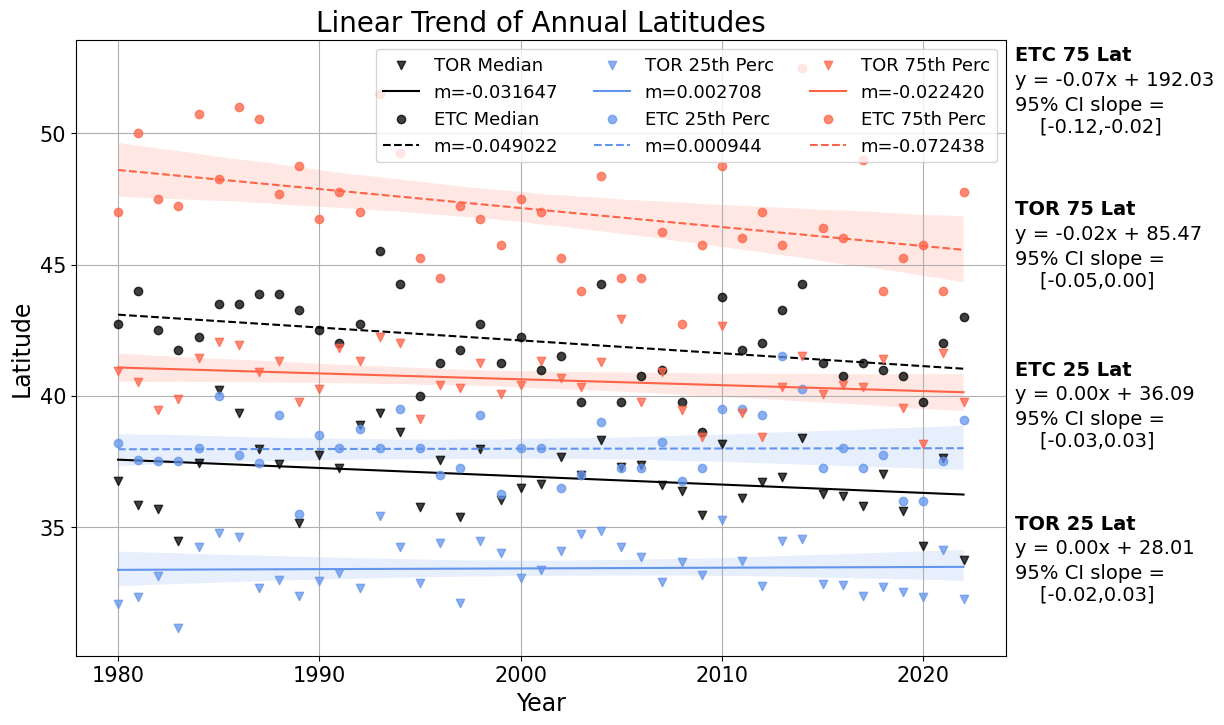

In [ ]:
# Linear trend of annual latitudes
tor_file = '%s/1980-2022_assoc_tor_and_etcs.csv' % data_dir
tor_file = '%s/1980-2022_add_non_tc_tor_and_etcs.csv' % data_dir
full_len = 0
year = begin_year
tor_latitudes = []
etc_latitudes = []
tor_25 = []
etc_25 = []
tor_75 = []
etc_75 = []
years_list = []
c = 0

while year <= end_year:
    if os.path.exists(tor_file):
        tor_df = pd.read_csv(tor_file, header=[0])
        tor_df = tor_df[tor_df['utcyr'].isin([year])]
        tor_latitudes.append(tor_df['slat'].median())
        etc_latitudes.append(tor_df['closest_etclat'].median())
        tor_25.append(tor_df['slat'].quantile(0.25))
        etc_25.append(tor_df['closest_etclat'].quantile(0.25))
        tor_75.append(tor_df['slat'].quantile(0.75))
        etc_75.append(tor_df['closest_etclat'].quantile(0.75))
        years_list.append(year)

    year = year + 1
    c = c + 1

# Convert years from strings to integers
years_list = np.array(list(map(int, years_list)))

co_df = pd.DataFrame()
co_df['tor_lat'] = tor_latitudes
co_df['etc_lat'] = etc_latitudes
co_df['tor_25_lat'] = tor_25
co_df['etc_25_lat'] = etc_25
co_df['tor_75_lat'] = tor_75
co_df['etc_75_lat'] = etc_75
co_df['years'] = years_list

fig, ax = plt.subplots(figsize=(12, 8))

# Create scatter plot
plt.scatter(years_list, tor_latitudes, label='TOR Median', zorder=2, marker='v', c='black', alpha=0.75)
# Fit a linear trend line
z = np.polyfit(years_list, tor_latitudes, 1)
p = np.poly1d(z)
plt.plot(years_list, p(years_list), "-", c='black', label='m=%s' % format(z[0], '.6f'))

# Create scatter plot
plt.scatter(years_list, etc_latitudes, label='ETC Median', zorder=2, c='black', alpha=0.75)
# Fit a linear trend line
z = np.polyfit(years_list, etc_latitudes, 1)
p = np.poly1d(z)
plt.plot(years_list, p(years_list), "--", c='black', label='m=%s' % format(z[0], '.6f'))

# Create scatter plot
plt.scatter(years_list, tor_25, label='TOR 25th Perc', zorder=2, marker='v', c='cornflowerblue', alpha=0.75)
# Fit a linear trend line
z = np.polyfit(years_list, tor_25, 1)
p = np.poly1d(z)
plt.plot(years_list, p(years_list), "-",  c='cornflowerblue', label='m=%s' % format(z[0], '.6f'))

x = co_df['years']
y = co_df['tor_25_lat']

X_lat = sm.add_constant(x)  # Add constant to predictor variable
model_lat = sm.OLS(y, X_lat).fit()
best_fit_values = model_lat.params
intercept = best_fit_values.const
slope = best_fit_values.years

X = sm.add_constant(x)
model = sm.OLS(y, X).fit()
y_pred = model.predict(X)
best_fit_values = model.params
rmse = np.sqrt(skmet.mean_squared_error(y, y_pred))
rsquared = model_lat.rsquared

boot_ci_temp = []
R = 2000
for i in range(R):
    # Create a new dataset resampled with replacement directly from dataset
    idx = np.random.choice(np.arange(len(x)), size=len(x))
    Xboot = x[idx]-np.mean(x[idx])
    yboot = y[idx]-np.mean(y[idx])

    # Re-fit the linear regression model and map back to beta (dont care about intercept)
    boot_model = sm.OLS(yboot, Xboot).fit()
    boot_ci_temp.append(boot_model.params)

# extract CI on slopes no interecept
ci_slopelow, ci_slopehigh = np.percentile(boot_ci_temp, 2.5, axis=0), np.percentile(boot_ci_temp, 97.5, axis=0)

# Fit and plot the linear regression model with 95% confidence interval
model = sns.regplot(
  data=co_df,
  x="years",
  y="tor_25_lat",
  ci=95,
  ax=ax,
  scatter=False,
  line_kws={'label': "y={0:.1f}x+{1:.1f}".format(slope, intercept), 'color': "cornflowerblue", 'linestyle': 'None'}
)

# Set the plot title and labels
ax.text(1.01, 0.23, 'TOR 25 Lat', transform=ax.transAxes, fontsize=14, verticalalignment='top', horizontalalignment='left', fontweight='bold')
ax.text(1.01, 0.19, f'y = {slope:.2f}x + {intercept:.2f}', transform=ax.transAxes, fontsize=14, verticalalignment='top', horizontalalignment='left')
ax.text(1.01, 0.15, f'95% CI slope =\n    [{ci_slopelow[0]:.2f},{ci_slopehigh[0]:.2f}]', transform=ax.transAxes, fontsize=14, verticalalignment='top', horizontalalignment='left')
#ax.text(1.02, 0.07, f'RMSE = {rmse:.2f}', transform=ax.transAxes, fontsize=14, verticalalignment='top', horizontalalignment='left')
#ax.text(1.02, 0.03, f'R2 = {rsquared:.3f}', transform=ax.transAxes, fontsize=14, verticalalignment='top', horizontalalignment='left')

# Create scatter plot
plt.scatter(years_list, etc_25, label='ETC 25th Perc', zorder=2, c='cornflowerblue', alpha=0.75)
# Fit a linear trend line
z = np.polyfit(years_list, etc_25, 1)
p = np.poly1d(z)
plt.plot(years_list, p(years_list), "--", c='cornflowerblue', label='m=%s' % format(z[0], '.6f'))

x = co_df['years']
y = co_df['etc_25_lat']

X_lat = sm.add_constant(x)  # Add constant to predictor variable
model_lat = sm.OLS(y, X_lat).fit()
best_fit_values = model_lat.params
intercept = best_fit_values.const
slope = best_fit_values.years

X = sm.add_constant(x)
model = sm.OLS(y, X).fit()
y_pred = model.predict(X)
best_fit_values = model.params
rmse = np.sqrt(skmet.mean_squared_error(y, y_pred))
rsquared = model_lat.rsquared

boot_ci_temp = []
R = 2000
for i in range(R):
    # Create a new dataset resampled with replacement directly from dataset
    idx = np.random.choice(np.arange(len(x)), size=len(x))
    Xboot = x[idx]-np.mean(x[idx])
    yboot = y[idx]-np.mean(y[idx])

    # Re-fit the linear regression model and map back to beta (dont care about intercept)
    boot_model = sm.OLS(yboot, Xboot).fit()
    boot_ci_temp.append(boot_model.params)

# extract CI on slopes no interecept
ci_slopelow, ci_slopehigh = np.percentile(boot_ci_temp, 2.5, axis=0), np.percentile(boot_ci_temp, 97.5, axis=0)

# Fit and plot the linear regression model with 95% confidence interval
model = sns.regplot(
  data=co_df,
  x="years",
  y="etc_25_lat",
  ci=95,
  ax=ax,
  scatter=False,
  line_kws={'label': "y={0:.1f}x+{1:.1f}".format(slope, intercept), 'color': "cornflowerblue", 'linestyle': 'None'}
)

# Set the plot title and labels
ax.text(1.01, 0.48, 'ETC 25 Lat', transform=ax.transAxes, fontsize=14, verticalalignment='top', horizontalalignment='left', fontweight='bold')
ax.text(1.01, 0.44, f'y = {slope:.2f}x + {intercept:.2f}', transform=ax.transAxes, fontsize=14, verticalalignment='top', horizontalalignment='left')
ax.text(1.01, 0.40, f'95% CI slope =\n    [{ci_slopelow[0]:.2f},{ci_slopehigh[0]:.2f}]', transform=ax.transAxes, fontsize=14, verticalalignment='top', horizontalalignment='left')
#ax.text(1.02, 0.32, f'RMSE = {rmse:.2f}', transform=ax.transAxes, fontsize=14, verticalalignment='top', horizontalalignment='left')
#ax.text(1.02, 0.28, f'R2 = {rsquared:.3f}', transform=ax.transAxes, fontsize=14, verticalalignment='top', horizontalalignment='left')

# Create scatter plot
plt.scatter(years_list, tor_75, label='TOR 75th Perc', zorder=2, marker='v', c='tomato', alpha=0.75)
# Fit a linear trend line
z = np.polyfit(years_list, tor_75, 1)
p = np.poly1d(z)
plt.plot(years_list, p(years_list), "-",  c='tomato', label='m=%s' % format(z[0], '.6f'))

x = co_df['years']
y = co_df['tor_75_lat']

X_lat = sm.add_constant(x)  # Add constant to predictor variable
model_lat = sm.OLS(y, X_lat).fit()
best_fit_values = model_lat.params
intercept = best_fit_values.const
slope = best_fit_values.years

X = sm.add_constant(x)
model = sm.OLS(y, X).fit()
y_pred = model.predict(X)
best_fit_values = model.params
rmse = np.sqrt(skmet.mean_squared_error(y, y_pred))
rsquared = model_lat.rsquared

boot_ci_temp = []
R = 2000
for i in range(R):
    # Create a new dataset resampled with replacement directly from dataset
    idx = np.random.choice(np.arange(len(x)), size=len(x))
    Xboot = x[idx]-np.mean(x[idx])
    yboot = y[idx]-np.mean(y[idx])

    # Re-fit the linear regression model and map back to beta (dont care about intercept)
    boot_model = sm.OLS(yboot, Xboot).fit()
    boot_ci_temp.append(boot_model.params)

# extract CI on slopes no interecept
ci_slopelow, ci_slopehigh = np.percentile(boot_ci_temp, 2.5, axis=0), np.percentile(boot_ci_temp, 97.5, axis=0)

# Fit and plot the linear regression model with 95% confidence interval
model = sns.regplot(
  data=co_df,
  x="years",
  y="tor_75_lat",
  ci=95,
  ax=ax,
  scatter=False,
  line_kws={'label': "y={0:.1f}x+{1:.1f}".format(slope, intercept), 'color': "tomato", 'linestyle': 'None'}
)

# Set the plot title and labels
ax.text(1.01, 0.74, 'TOR 75 Lat', transform=ax.transAxes, fontsize=14, verticalalignment='top', horizontalalignment='left', fontweight='bold')
ax.text(1.01, 0.70, f'y = {slope:.2f}x + {intercept:.2f}', transform=ax.transAxes, fontsize=14, verticalalignment='top', horizontalalignment='left')
ax.text(1.01, 0.66, f'95% CI slope =\n    [{ci_slopelow[0]:.2f},{ci_slopehigh[0]:.2f}]', transform=ax.transAxes, fontsize=14, verticalalignment='top', horizontalalignment='left')
#ax.text(1.02, 0.58, f'RMSE = {rmse:.2f}', transform=ax.transAxes, fontsize=14, verticalalignment='top', horizontalalignment='left')
#ax.text(1.02, 0.54, f'R2 = {rsquared:.3f}', transform=ax.transAxes, fontsize=14, verticalalignment='top', horizontalalignment='left')

# Create scatter plot
plt.scatter(years_list, etc_75, label='ETC 75th Perc', zorder=2, c='tomato', alpha=0.75)
# Fit a linear trend line
z = np.polyfit(years_list, etc_75, 1)
p = np.poly1d(z)
plt.plot(years_list, p(years_list), "--", c='tomato', label='m=%s' % format(z[0], '.6f'))

x = co_df['years']
y = co_df['etc_75_lat']

X_lat = sm.add_constant(x)  # Add constant to predictor variable
model_lat = sm.OLS(y, X_lat).fit()
best_fit_values = model_lat.params
intercept = best_fit_values.const
slope = best_fit_values.years

X = sm.add_constant(x)
model = sm.OLS(y, X).fit()
y_pred = model.predict(X)
best_fit_values = model.params
rmse = np.sqrt(skmet.mean_squared_error(y, y_pred))
rsquared = model_lat.rsquared

boot_ci_temp = []
R = 2000
for i in range(R):
    # Create a new dataset resampled with replacement directly from dataset
    idx = np.random.choice(np.arange(len(x)), size=len(x))
    Xboot = x[idx]-np.mean(x[idx])
    yboot = y[idx]-np.mean(y[idx])

    # Re-fit the linear regression model and map back to beta (dont care about intercept)
    boot_model = sm.OLS(yboot, Xboot).fit()
    boot_ci_temp.append(boot_model.params)

# extract CI on slopes no interecept
ci_slopelow, ci_slopehigh = np.percentile(boot_ci_temp, 2.5, axis=0), np.percentile(boot_ci_temp, 97.5, axis=0)

# Fit and plot the linear regression model with 95% confidence interval
model = sns.regplot(
  data=co_df,
  x="years",
  y="etc_75_lat",
  ci=95,
  ax=ax,
  scatter=False,
  line_kws={'label': "y={0:.1f}x+{1:.1f}".format(slope, intercept), 'color': "tomato", 'linestyle': 'None'}
)

# Set the plot title and labels
ax.text(1.01, 0.99, 'ETC 75 Lat', transform=ax.transAxes, fontsize=14, verticalalignment='top', horizontalalignment='left', fontweight='bold')
ax.text(1.01, 0.95, f'y = {slope:.2f}x + {intercept:.2f}', transform=ax.transAxes, fontsize=14, verticalalignment='top', horizontalalignment='left')
ax.text(1.01, 0.91, f'95% CI slope =\n    [{ci_slopelow[0]:.2f},{ci_slopehigh[0]:.2f}]', transform=ax.transAxes, fontsize=14, verticalalignment='top', horizontalalignment='left')
#ax.text(1.02, 0.83, f'RMSE = {rmse:.2f}', transform=ax.transAxes, fontsize=14, verticalalignment='top', horizontalalignment='left')
#ax.text(1.02, 0.79, f'R2 = {rsquared:.3f}', transform=ax.transAxes, fontsize=14, verticalalignment='top', horizontalalignment='left')

# Add labels and legend
plt.xlabel('Year', fontsize=17)
plt.ylabel('Latitude', fontsize=17)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.title('Linear Trend of Annual Latitudes', fontsize=20)
plt.legend(ncol=3, fontsize=13)
plt.grid(True, zorder=0)

year_save_dir = '%s/annual' % plots_dir
if os.path.exists(year_save_dir):
    plt.savefig("%s/annual_25th_75th_latfit.png" % year_save_dir, bbox_inches='tight', dpi=300)
else:
    os.mkdir(year_save_dir)
    plt.savefig("%s/annual_25th_75th_latfit.png" % year_save_dir, bbox_inches='tight', dpi=300)
plt.show()

# Minimum Pressure

1178
1164
716


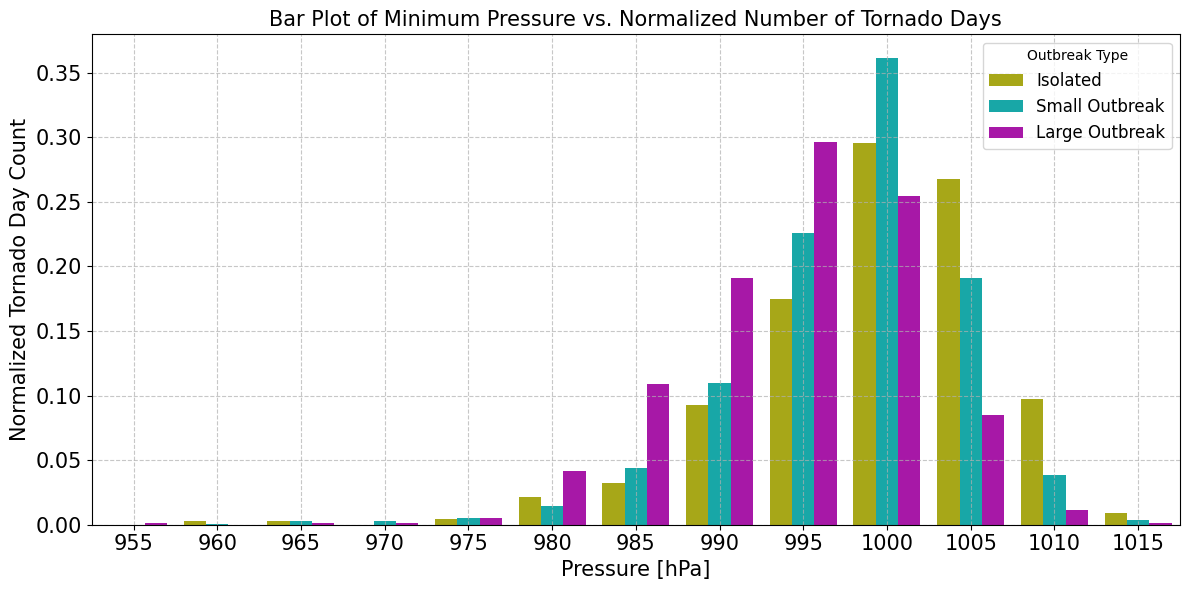

In [ ]:
# Function to process data
def process_data(tor_file):
    tor_df = pd.read_csv(tor_file)
    tor_df['pressure'] = tor_df['pressure'].apply(lambda x: int(round(float(x.strip("''"))/100/5.0)*5.0) if isinstance(x, str) else int(round(x/100/5.0)*5.0))

    total_num_days = tor_df['tornado_day'].unique()
    print(len(total_num_days))

    # Loop through each unique day to find the minimum pressure of that day
    min_press_list = []
    day_list = []
    for event in tor_df['tornado_day'].unique():
        occurrences = tor_df[tor_df['tornado_day'] == event]
        min_press = occurrences['pressure'].min()

        # Append values to lists
        min_press_list.append(min_press)
        day_list.append(event)

    # Create a DataFrame for plotting
    plot_df = pd.DataFrame({
        'min_press': min_press_list,
        'day': day_list,
    })

    # Loop through each minimum pressure to find the number of days with that minimum pressure
    pressures = []
    num_days_list = []
    for press in plot_df['min_press'].unique():
        count = plot_df[plot_df['min_press'].isin([press])]
        pressures.append(press)
        num_days_list.append(len(count) / len(total_num_days))

    plot_df = pd.DataFrame({
        'min_press': pressures,
        'num_days': num_days_list,
    })

    return plot_df, len(total_num_days)

# Initialize a list to hold all data
all_data = []

# File paths
one_off_tor = '%s/1980-2022_outbreak_1_1.csv' % data_dir
small_outbreaks = '%s/1980-2022_outbreak_2_5.csv' % data_dir
large_outbreaks = '%s/1980-2022_outbreak_6_100000.csv' % data_dir
files = [[one_off_tor, "Isolated", 'y'], [small_outbreaks, "Small Outbreak", 'c'], [large_outbreaks, "Large Outbreak", 'm']]
category_order = ['Isolated', 'Small Outbreak', 'Large Outbreak']

for f in files:
    plot_df, total_num_days = process_data(f[0])
    plot_df['category'] = f[1]
    plot_df['color'] = f[2]  # optional, for custom colors
    all_data.append(plot_df)

# Combine all into a single DataFrame
combined_df = pd.concat(all_data, ignore_index=True)

# plt.figure(figsize=(12, 6))
fig, ax =plt.subplots(figsize=(12, 6))
sns.barplot(
    data=combined_df,
    x='min_press',
    y='num_days',
    hue='category',
    hue_order=category_order,
    palette={f[1]: f[2] for f in files},
    ax=ax
)
# fig, ax =plt.subplots(figsize=(12, 6))

# sns.kdeplot(
#     data=combined_df,
#     x='min_press',
#     weights='num_days',
#     hue='category',
#     hue_order=category_order,
#     palette={f[1]: f[2] for f in files},
#     linestyle='--',
#     ax=ax
# )


# Set labels and title
plt.xlabel('Pressure [hPa]', fontsize=15)
plt.xticks(fontsize=15)
plt.ylabel('Normalized Tornado Day Count', fontsize=15)
plt.yticks(fontsize=15)
plt.title('Bar Plot of Minimum Pressure vs. Normalized Number of Tornado Days', fontsize=15)

# Customize legend
plt.legend(title='Outbreak Type', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Save plot as needed
year_save_dir = '%s/1980-2022' % plots_dir
if not os.path.exists(year_save_dir):
    os.mkdir(year_save_dir)

plt.savefig("%s/etc_press_vs_tor_barplot.png" % (year_save_dir), bbox_inches='tight', dpi=300)
plt.show()

In [ ]:
def torPminGeo(req_data, title, pmin):
    if not req_data.empty:
        # Initialize figure, set size and resolution
        fig = plt.figure(figsize=(10, 8), dpi=150)
        fig.set_facecolor('white')

        # create axis using cartopy projections, add in coastlines & grid
        ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
        ax.add_feature(cfeature.COASTLINE, linewidth=0.5, color='grey', zorder=2)
        ax.add_feature(cfeature.STATES, edgecolor='grey')
        ax.grid(visible=True)

        # create gridlines and format labels
        gl = ax.gridlines(draw_labels=True, zorder=3)
        gl.xformatter = LONGITUDE_FORMATTER
        gl.yformatter = LATITUDE_FORMATTER
        gl.xlabels_top = gl.ylabels_right = False
        gl.xlines = gl.ylines = True
        gl.xlabel_style = {'size': 14}
        gl.ylabel_style = {'size': 14}

        # Density distribution of tornadoes (grey shading)
        x_bin_edges = np.arange(-125, -65, 0.5)
        y_bin_edges = np.arange(25, 55, 0.5)
        counts, xedges, yedges, im = ax.hist2d(req_data['slon'], req_data['slat'],
                                               transform=ccrs.PlateCarree(), bins=(x_bin_edges, y_bin_edges),
                                               cmap=ListedColormap(plt.cm.Greens(np.linspace(0.15, 1, 256))), cmin=1)

        cbar = plt.colorbar(im, ax=ax, fraction=0.025)
        cbar.set_label(label="%s tornadoes" % len(req_data), size=15)
        cbar.ax.tick_params(labelsize=15)

        # Density distribution of ETCs (grey contours)
        sns.kdeplot(data=req_data, x="closest_etclon", y="closest_etclat",
                    cmap=plt.cm.Greys, cbar=False, cbar_kws={'shrink': .5})

        # Median lat/lon of tornado and ETC
        median_lon_tor = req_data['slon'].median()
        median_lat_tor = req_data['slat'].median()
        median_lon_ext = req_data['closest_etclon'].median()
        median_lat_ext = req_data['closest_etclat'].median()

        # Plot median points
        ax.scatter(median_lon_tor, median_lat_tor, transform=ccrs.PlateCarree(),
                   marker='v', s=75, c='tomato', zorder=2)
        ax.scatter(median_lon_ext, median_lat_ext, transform=ccrs.PlateCarree(),
                   marker='o', s=75, c='cyan', edgecolors='teal', zorder=2)

        plt.title(title, fontsize=15)
        save_dir = '%s/1980-2022' % plots_dir
        if os.path.exists(save_dir):
            plt.savefig("%s/geo_dens_pmin_%s.png" % (save_dir, pmin), bbox_inches='tight', dpi=300)
        else:
            os.mkdir(save_dir)
            plt.savefig("%s/geo_dens_pmin_%s.png" % (save_dir, pmin), bbox_inches='tight', dpi=300)

        plt.show()


# File paths
file_ws = f'{data_dir}/1980-2022_assoc_tor_and_etcs.csv'
# Add Pmin column
p_df = pd.read_csv(file_ws)
p_df['pressure'] = p_df['pressure'].apply(lambda x: int(round(float(x.strip("''"))/100/5.0)*5.0) if isinstance(x, str) else int(round(x/100/5.0)*5.0))
p_df['pmin'] = p_df.groupby('utcdatetimes')['pressure'].transform('min')
p_df = p_df.sort_values(by='pmin')


for press in p_df['pmin'].unique():
    print(press)
    pmin_df = p_df[p_df['pmin'].isin([press])]
    # print(pmin_df)
    title = 'Tornado and ETC Distribution (Pmin: %s)' % str(press)
    #torPminGeo(pmin_df, title, str(press))

955
960
965
970
975
980
985
990
995
1000
1005
1010
1015
1020


# Year 2000 Analysis

In [ ]:
yes = ['2000-01-03 12:00:00', '2000-01-03 18:00:00', '2000-01-03 19:00:00',
       '2000-01-03 21:00:00', '2000-01-03 22:00:00', '2000-01-03 23:00:00',
       '2000-01-10 05:00:00', '2000-01-24 08:00:00', '2000-02-13 21:00:00',
       '2000-02-13 23:00:00', '2000-02-14 02:00:00', '2000-02-14 04:00:00',
       '2000-02-14 05:00:00', '2000-02-14 06:00:00', '2000-02-18 18:00:00',
       '2000-02-25 02:00:00', '2000-02-25 13:00:00', '2000-02-25 20:00:00',
       '2000-02-25 22:00:00', '2000-02-26 06:00:00', '2000-02-26 09:00:00',
       '2000-03-02 08:00:00', '2000-03-07 22:00:00', '2000-03-07 23:00:00',
       '2000-03-08 00:00:00', '2000-03-09 00:00:00', '2000-03-11 20:00:00',
       '2000-04-02 23:00:00', '2000-04-03 02:00:00', '2000-04-03 05:00:00',
       '2000-04-03 06:00:00', '2000-04-03 07:00:00', '2000-04-03 08:00:00',
       '2000-04-03 09:00:00', '2000-04-03 10:00:00', '2000-04-03 11:00:00',
       '2000-04-03 12:00:00', '2000-04-03 13:00:00', '2000-04-03 16:00:00',
       '2000-04-03 17:00:00', '2000-04-03 18:00:00', '2000-04-04 00:00:00',
       '2000-04-15 17:00:00', '2000-04-17 20:00:00', '2000-04-20 01:00:00',
       '2000-04-20 09:00:00', '2000-04-20 12:00:00', '2000-04-20 14:00:00',
       '2000-04-20 22:00:00', '2000-04-20 23:00:00', '2000-04-21 00:00:00',
       '2000-04-21 01:00:00', '2000-04-21 19:00:00', '2000-04-23 19:00:00',
       '2000-04-23 20:00:00', '2000-04-23 21:00:00', '2000-04-23 22:00:00',
       '2000-04-23 23:00:00', '2000-04-24 00:00:00', '2000-04-24 09:00:00',
       '2000-04-24 10:00:00', '2000-04-30 22:00:00', '2000-05-08 02:00:00',
       '2000-05-09 03:00:00', '2000-05-09 04:00:00', '2000-05-10 00:00:00',
       '2000-05-12 00:00:00', '2000-05-12 01:00:00', '2000-05-12 02:00:00',
       '2000-05-12 04:00:00', '2000-05-12 22:00:00', '2000-05-12 23:00:00',
       '2000-05-13 05:00:00', '2000-05-13 23:00:00', '2000-05-14 00:00:00',
       '2000-05-17 18:00:00', '2000-05-17 19:00:00', '2000-05-17 20:00:00',
       '2000-05-17 21:00:00', '2000-05-17 22:00:00', '2000-05-18 17:00:00',
       '2000-05-18 21:00:00', '2000-05-19 18:00:00', '2000-05-20 01:00:00',
       '2000-05-23 19:00:00', '2000-05-23 20:00:00', '2000-05-23 21:00:00',
       '2000-05-23 22:00:00', '2000-05-23 23:00:00', '2000-05-24 00:00:00',
       '2000-05-25 00:00:00', '2000-05-25 03:00:00', '2000-05-25 04:00:00',
       '2000-05-25 05:00:00', '2000-05-25 07:00:00', '2000-05-25 08:00:00',
       '2000-05-26 00:00:00', '2000-05-26 04:00:00', '2000-05-26 05:00:00',
       '2000-05-26 20:00:00', '2000-05-26 22:00:00', '2000-05-26 23:00:00',
       '2000-05-27 01:00:00', '2000-05-27 02:00:00', '2000-05-27 04:00:00',
       '2000-05-27 05:00:00', '2000-05-27 08:00:00', '2000-05-27 17:00:00',
       '2000-05-27 19:00:00', '2000-06-01 20:00:00', '2000-06-01 21:00:00',
       '2000-06-01 23:00:00', '2000-06-02 21:00:00', '2000-06-02 23:00:00',
       '2000-06-10 20:00:00', '2000-06-13 00:00:00', '2000-06-13 20:00:00',
       '2000-06-13 21:00:00', '2000-06-13 22:00:00', '2000-06-13 23:00:00',
       '2000-06-14 20:00:00', '2000-06-14 22:00:00', '2000-06-14 23:00:00',
       '2000-06-15 21:00:00', '2000-06-16 15:00:00', '2000-06-16 21:00:00',
       '2000-06-20 19:00:00', '2000-06-22 02:00:00', '2000-09-16 22:00:00',
       '2000-09-17 08:00:00', '2000-09-17 09:00:00', '2000-09-18 12:00:00',
       '2000-09-20 23:00:00', '2000-09-21 00:00:00', '2000-09-22 00:00:00',
       '2000-10-13 23:00:00', '2000-10-31 21:00:00', '2000-10-31 22:00:00',
       '2000-10-31 23:00:00', '2000-11-01 00:00:00', '2000-11-01 01:00:00',
       '2000-11-01 02:00:00', '2000-11-01 19:00:00', '2000-11-01 20:00:00',
       '2000-11-01 23:00:00', '2000-11-06 05:00:00', '2000-11-06 11:00:00',
       '2000-11-06 19:00:00', '2000-11-07 03:00:00', '2000-11-08 17:00:00',
       '2000-11-08 19:00:00', '2000-11-09 13:00:00', '2000-11-09 19:00:00',
       '2000-11-09 20:00:00', '2000-11-24 07:00:00', '2000-11-24 09:00:00',
       '2000-12-16 16:00:00', '2000-12-16 17:00:00', '2000-12-16 18:00:00',
       '2000-12-16 19:00:00', '2000-12-16 20:00:00', '2000-12-16 21:00:00',
       '2000-12-17 02:00:00', '2000-12-17 05:00:00']

no = ['2000-02-14 00:00:00', '2000-03-10 23:00:00', '2000-03-11 01:00:00',
      '2000-03-11 03:00:00', '2000-03-15 19:00:00', '2000-03-15 20:00:00',
      '2000-03-19 23:00:00', '2000-03-22 06:00:00', '2000-03-22 21:00:00',
      '2000-03-23 04:00:00', '2000-03-29 00:00:00', '2000-03-29 01:00:00',
      '2000-03-29 02:00:00', '2000-04-26 22:00:00', '2000-05-03 23:00:00',
      '2000-05-04 22:00:00', '2000-05-04 23:00:00', '2000-05-05 00:00:00',
      '2000-05-26 17:00:00', '2000-05-31 02:00:00', '2000-06-22 20:00:00',
      '2000-07-02 23:00:00', '2000-07-04 22:00:00', '2000-07-06 03:00:00',
      '2000-07-07 16:00:00', '2000-07-09 02:00:00', '2000-07-09 09:00:00',
      '2000-07-10 00:00:00', '2000-07-10 02:00:00', '2000-07-10 03:00:00',
      '2000-07-10 21:00:00', '2000-07-11 22:00:00', '2000-07-13 18:00:00',
      '2000-07-23 18:00:00', '2000-07-25 00:00:00', '2000-08-05 07:00:00',
      '2000-08-07 02:00:00', '2000-08-08 00:00:00', '2000-08-08 01:00:00',
      '2000-08-08 02:00:00', '2000-09-01 00:00:00', '2000-09-15 10:00:00',
      '2000-09-22 12:00:00', '2000-09-22 13:00:00', '2000-09-22 19:00:00',
      '2000-09-23 03:00:00', '2000-09-23 04:00:00', '2000-09-23 05:00:00',
      '2000-09-23 22:00:00', '2000-10-03 17:00:00', '2000-10-10 02:00:00',
      '2000-10-10 03:00:00', '2000-10-28 18:00:00', '2000-10-29 22:00:00',
      '2000-10-30 00:00:00', '2000-11-03 22:00:00', '2000-11-10 17:00:00',
      '2000-11-16 22:00:00', '2000-11-24 08:00:00', '2000-01-16 17:00:00',
      '2000-02-14 22:00:00', '2000-02-14 23:00:00', '2000-03-23 22:00:00',
      '2000-04-14 19:00:00', '2000-04-24 01:00:00', '2000-04-24 02:00:00',
      '2000-06-12 22:00:00', '2000-06-24 19:00:00', '2000-06-25 01:00:00',
      '2000-07-18 22:00:00', '2000-08-09 20:00:00', '2000-08-09 23:00:00',
      '2000-08-10 00:00:00', '2000-08-10 01:00:00', '2000-08-16 17:00:00']

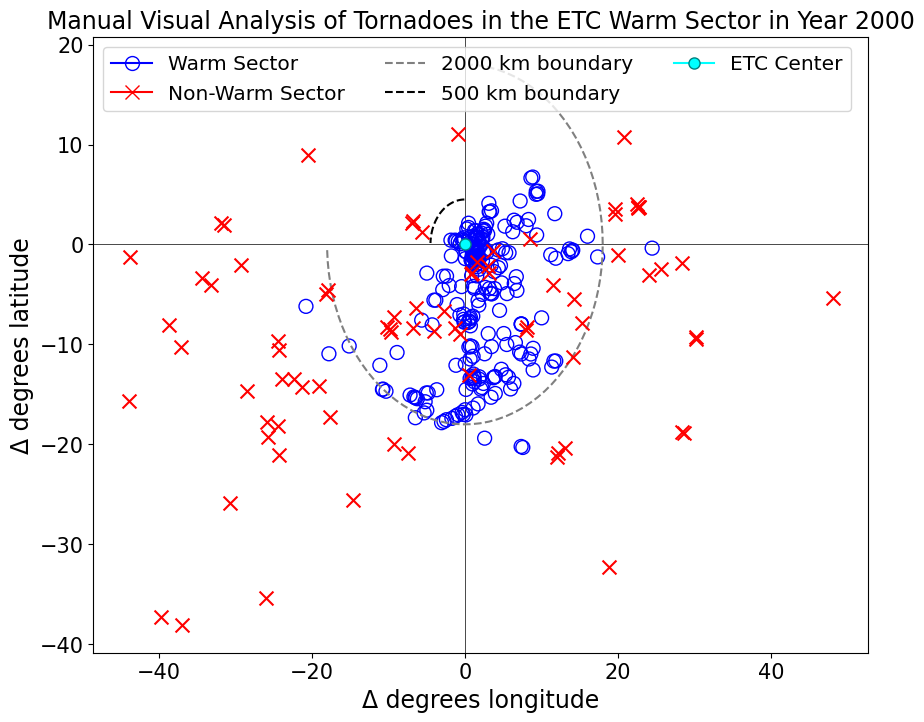

In [ ]:
# Methods needed for outbreak plots
def tor2000Distr(req_df, title):
    # Create a figure with 6 plot areas
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.set_title(title, fontsize=17)

    # Axis labels
    ax.set_xlabel('Δ degrees longitude', fontsize=17)
    ax.set_ylabel('Δ degrees latitude', fontsize=17)
    ax.tick_params(labelsize=15)

    # (0,0) lines
    ax.axvline(0, ymin=-40, ymax=40, color='black', linewidth=.5)
    ax.axhline(0, xmin=0, xmax=1, color='black', linewidth=.5)

    # Centralized ETC marker
    central_marker = ax.plot(0, 0, marker="o", markersize=8, c="cyan", mec='teal', label='ETC Center', zorder=5)

    # Set coordinates relative to centralized ETC
    new_coord = pd.DataFrame()
    yes_count = 0
    no_count = 0

    # Define new lat and lon relative to ETC
    filtered_data = req_df.dropna(subset=['closest_etclon', 'closest_etclat'])
    if not filtered_data.empty:
        for index, row in filtered_data.iterrows():
            tor_lat = filtered_data['slat'][index] - filtered_data['closest_etclat'][index]
            tor_lon = filtered_data['slon'][index] - filtered_data['closest_etclon'][index]
            df = pd.DataFrame({"slat": [tor_lat], "slon": [tor_lon],
                               "utcdatetimes": [filtered_data['utcdatetimes'][index]],
                               "distance":[filtered_data['distance'][index]]})
            # new_coord = new_coord.append(df, ignore_index=True)
            #new_coord = pd.concat([new_coord, df.to_frame().T])
            new_coord = pd.concat([new_coord, df], ignore_index=True)

        for index, row in new_coord.iterrows():
            date = new_coord['utcdatetimes'][index]
            if date in no:
                no_count = no_count + 1
                ax.scatter(new_coord['slon'][index], new_coord['slat'][index],
                           c='red', marker="x", zorder=4, s=100)
            else:
                yes_count = yes_count + 1
                ax.scatter(new_coord['slon'][index], new_coord['slat'][index],
                           facecolors='none', edgecolors='blue', zorder=2, s=100)
            # sx = new_coord['slon'][index]
            # sy = new_coord['slat'][index]
            # sd = new_coord['distance'][index]
            # if date in no:
            #     no_count = no_count + 1
            #     if sx < 0 and sy > 0 and sd > 200:
            #         ax.scatter(new_coord['slon'][index], new_coord['slat'][index],
            #                    c='grey', marker="x", zorder=4, s=100)
            #     else:
            #         ax.scatter(new_coord['slon'][index], new_coord['slat'][index],
            #                    c='red', marker="x", zorder=4, s=100)
            # else:
            #     yes_count = yes_count + 1
            #     if sx < 0 and sy > 0 and sd > 200:
            #         ax.scatter(new_coord['slon'][index], new_coord['slat'][index],
            #                    facecolors='none', edgecolors='grey', zorder=2, s=100)
            #     else:
            #         ax.scatter(new_coord['slon'][index], new_coord['slat'][index],
            #                    facecolors='none', edgecolors='blue', zorder=2, s=100)

        yes_patch = mlines.Line2D([], [], color='blue', label='Warm Sector', marker='o',
                                  markeredgecolor='blue', markerfacecolor='none', markersize=10)
        no_patch = mlines.Line2D([], [], color='red', label='Non-Warm Sector', marker='x', markersize=10)

    # Draw a boundary circle with radius of 2000 km (excluding NW quadrant)
    radius_km = 2000
    radius_deg = radius_km / 111  # Approximate conversion from km to degrees
    theta = np.linspace(0, 2 * np.pi, 100)

    # Create the full circle but mask out the NW quadrant
    x_circle = radius_deg * np.cos(theta)
    y_circle = radius_deg * np.sin(theta)

    # Mask the NW quadrant for the 2000 km boundary
    mask_2000km = (x_circle >= 0) | (y_circle <= 0)
    x_circle = np.where(mask_2000km, x_circle, np.nan)
    y_circle = np.where(mask_2000km, y_circle, np.nan)

    # Plot the circle with the NW quadrant excluded
    boundary_marker, = ax.plot(x_circle, y_circle, color='grey', linestyle='--',
                               linewidth=1.5, label='2000 km boundary')

    # Draw a boundary circle with radius of 500 km in the NW quadrant
    radius_km = 500
    radius_deg = radius_km / 111
    theta = np.linspace(0, 2 * np.pi, 100)
    x_circle_500km = radius_deg * np.cos(theta)
    y_circle_500km = radius_deg * np.sin(theta)

    # Mask the NW quadrant for the 2000 km boundary
    # mask_200km = (x_circle_200km >= 0) | (y_circle_200km <= 0)
    mask_500km = (x_circle_500km <= 0) | (y_circle_500km <= 0)
    x_circle_500km = np.where(mask_500km, x_circle_500km, np.nan)
    y_circle_500km = np.where(mask_500km, y_circle_500km, np.nan)
    mask_500km = (x_circle_500km <= 0) | (y_circle_500km >= 0)
    x_circle_500km = np.where(mask_500km, x_circle_500km, np.nan)
    y_circle_500km = np.where(mask_500km, y_circle_500km, np.nan)
    mask_500km = (x_circle_500km >= 0) | (y_circle_500km >= 0)
    x_circle_500km = np.where(mask_500km, x_circle_500km, np.nan)
    y_circle_500km = np.where(mask_500km, y_circle_500km, np.nan)

    # Plot the 500 km circle in NW quadrant
    boundary_marker_500km, = ax.plot(x_circle_500km, y_circle_500km, color='black',
                                     linestyle='--', linewidth=1.5, label='500 km boundary')

    # Add the patches and legend
    handle_list = [yes_patch, no_patch, boundary_marker, boundary_marker_500km, central_marker[0]]
    ax.legend(handles=handle_list, loc='upper left', ncol=3, fontsize=14.5)

    save_dir = '%s/1980-2022' % plots_dir
    if os.path.exists(save_dir):
        plt.savefig("%s/distr_dens_2000.png" % (save_dir), bbox_inches='tight', dpi=300)
    else:
        os.mkdir(save_dir)
        plt.savefig("%s/distr_dens_2000.png" % (save_dir), bbox_inches='tight', dpi=300)

# Run outbreak size plots
all_tor = '%s/1980-2022_add_non_tc_tor_and_etcs.csv' % data_dir

# All tornadoes
if os.path.exists(all_tor):
    tor_df = pd.read_csv(all_tor, header=[0])
    tor_df = tor_df[tor_df['utcyr'].isin([2000])]
    title = 'Manual Visual Analysis of Tornadoes in the ETC Warm Sector in Year 2000'
    tor2000Distr(tor_df, title)

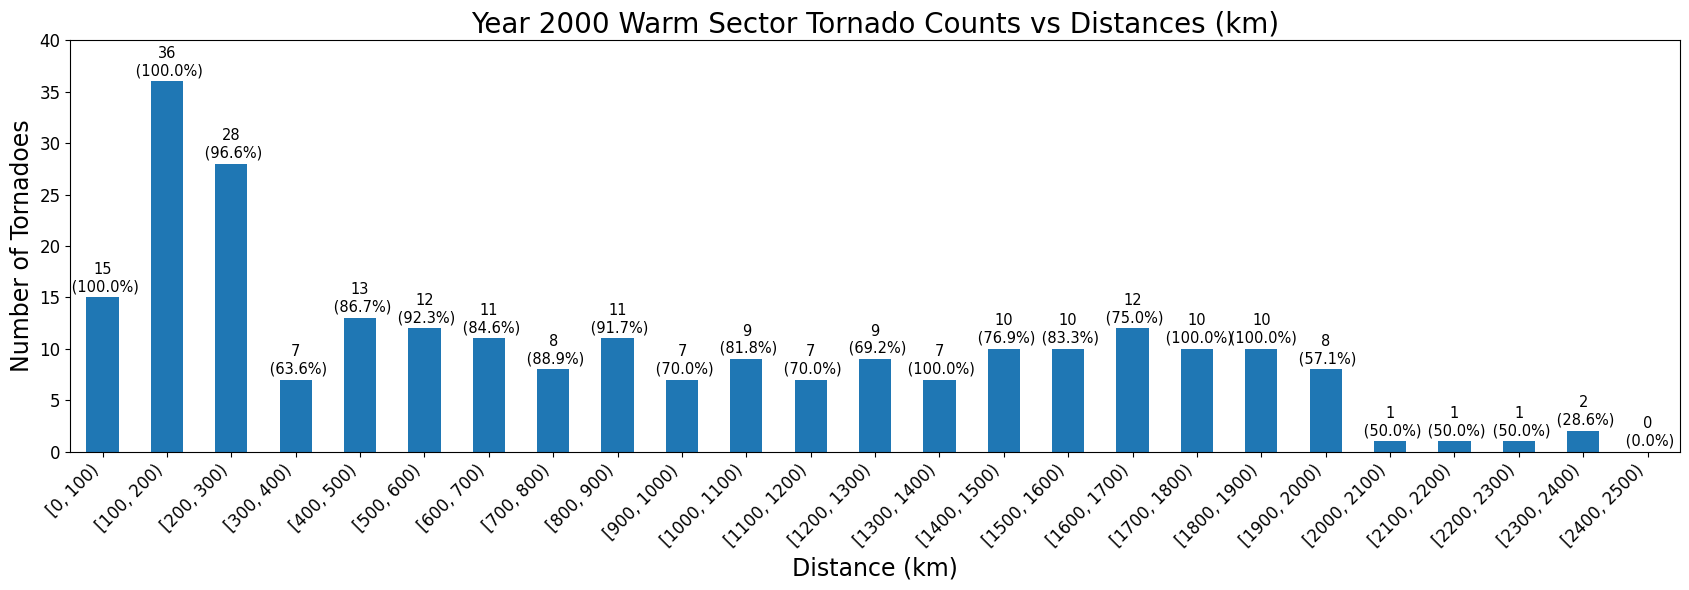

In [ ]:
# Run outbreak size plots
all_tor = '%s/1980-2022_add_non_tc_tor_and_etcs.csv' % data_dir
classifications = []

# All tornadoes
if os.path.exists(all_tor):
    tor_df = pd.read_csv(all_tor, header=[0])
    tor_df = tor_df[tor_df['utcyr'].isin([2000])]
    tor_df = tor_df.dropna(subset=['closest_etclon', 'closest_etclat'])
    distances = tor_df['distance'].values
    for index, row in tor_df.iterrows():
        date = tor_df['utcdatetimes'][index]
        if date in yes:
            classifications.append('yes')
        elif date in no:
            classifications.append('no')
        else:
            print("error", date)

# Convert to DataFrame
df = pd.DataFrame({
    'distance': distances,
    'classification': classifications
})

# Define bin edges
bin_edges = np.arange(0, 2500 + 100, 100)  # 0 to 5000 km with 100 km intervals

# Bin distances
df['bin'] = pd.cut(df['distance'], bins=bin_edges, right=False)

# Count tornadoes in each bin
bin_counts = df.groupby(['bin', 'classification']).size().unstack(fill_value=0)

# Calculate total counts and percentages
bin_counts['total'] = bin_counts['yes'] + bin_counts['no']
bin_counts['yes_percentage'] = 100 * bin_counts['yes'] / bin_counts['total']
bin_counts['no_percentage'] = 100 * bin_counts['no'] / bin_counts['total']

# Prepare for plotting
bin_counts = bin_counts.reset_index()
bin_labels = bin_counts['bin'].astype(str)
yes_counts = bin_counts['yes']
total_counts = bin_counts['total']

# Bar width and positions
bar_width = 0.5  # Adjust bar width to make it more readable
x = np.arange(len(bin_counts))

# Plotting
fig, ax = plt.subplots(figsize=(17, 6))

# Plot 'yes' bars
ax.bar(x, yes_counts, bar_width, label='Yes', color='#1f77b4')

# Add percentage labels
for i, yes_count in enumerate(yes_counts):
    percentage = 100 * yes_count / total_counts[i] if total_counts[i] > 0 else 0
    ax.text(x[i], yes_count + 0.3, f'{yes_count}\n ({percentage:.1f}%)', va='bottom', ha='center', fontsize=10.5)

# Formatting
ax.set_xlabel('Distance (km)', fontsize=17)
ax.set_ylabel('Number of Tornadoes', fontsize=17)
ax.set_title('Year 2000 Warm Sector Tornado Counts vs Distances (km)', fontsize=20)
ax.set_xticks(x)
ax.set_xticklabels(bin_labels, rotation=45, ha='right', fontsize=12)
ax.set_xlim(-0.5, len(bin_counts) - 0.5)
ax.set_ylim(0, 40)
for label in ax.get_yticklabels():
    label.set_fontsize(12)
#ax.legend()

# Adjust padding and margins
plt.tight_layout()

save_dir = '%s/1980-2022' % plots_dir
if os.path.exists(save_dir):
    plt.savefig("%s/dist_thresh_bar_2000.png" % (save_dir), bbox_inches='tight', dpi=300)
else:
    os.mkdir(save_dir)
    plt.savefig("%s/dist_thresh_bar_2000.png" % (save_dir), bbox_inches='tight', dpi=300)
plt.show()